# Statistical and Machine-Learning Analysis of Healthy Life Expectancy in Scotland

**Dissertation:** *Data-Driven Modelling of Health Inequalities in Scotland, UK, Using Statistical Analysis and Machine Learning*

Student: Gerald Otuadimma | Student ID: 25928399 | Programme: MSc Artificial Intelligence | University: Manchester Metropolitan University

This notebook contains the empirical work used for the methodology, results and discussion chapters. 
## Analytical rules used throughout

- Healthy Life Expectancy (HLE) at birth is the primary outcome.
- The 64 at-birth rows represent 32 councils observed for females and males.
- Rows from the same council are never divided between training and testing.
- All-age rows are used for descriptive age profiles, not as 1,280 independent observations.
- Confidence interval columns describe HLE uncertainty and are never used as predictors.
- Core models use upstream social and demographic context. Outcome-adjacent health variables are reserved for sensitivity analysis.
- Regression predicts HLE years; secondary classification predicts Low, Middle or High HLE for council-sex populations.
- Findings are ecological associations and predictions, not individual or causal effects.

## 1. Setup

Python in JupyterLab or the VS Code Jupyter extension is the recommended environment. 


In [1]:
# Importing the packages used throughout the analysis.
from pathlib import Path
from itertools import combinations
from math import factorial
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, mean_absolute_error,
    mean_squared_error, precision_recall_curve, precision_score, r2_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC, SVR

# Setting a fixed seed so the results can be reproduced.
warnings.filterwarnings("ignore")
RANDOM_SEED = 25928399
rng = np.random.default_rng(RANDOM_SEED)

# Using one consistent style and colour scheme for every figure.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

BLUE = "#235789"
ORANGE = "#F28E2B"
TEAL = "#2A9D8F"
RED = "#D1495B"
PURPLE = "#6C5B7B"
GREY = "#6B7280"
SEX_COLOURS = {"Female": "#B44C7A", "Male": "#235789"}

# Finding the project folders and creating locations for the saved figures and tables.
project_root = Path.cwd()
if not (project_root / "data" / "Scotland_Health_Inequalities_Dataset.csv").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "Scotland_Health_Inequalities_Dataset.csv"
figures_dir = project_root / "results" / "figures"
tables_dir = project_root / "results" / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Recording the main software versions used to run the notebook.
print(
    f"Python {platform.python_version()} | pandas {pd.__version__} | "
    f"scikit-learn {__import__('sklearn').__version__} | matplotlib {matplotlib.__version__}"
)

Python 3.12.10 | pandas 3.0.5 | scikit-learn 1.9.0 | matplotlib 3.11.1


## 2. Load and validate the data


In [2]:
# Loading the combined dataset and confirming its overall size and coverage.
df = pd.read_csv(data_path)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]} | Councils: {df['council_area_code'].nunique()} | Sex groups: {df['sex'].nunique()} | Age groups: {df['age_group'].nunique()}")

Rows: 1,280 | Columns: 43 | Councils: 32 | Sex groups: 2 | Age groups: 20


In [3]:
# Identifying the key fields and percentage columns needed for the quality checks.
natural_key = ["council_area_code", "sex", "age_group"]
percent_columns = [column for column in df.columns if column.endswith("_pct")]

# Checking the expected data coverage, duplicates, missing values and valid numerical ranges.
quality_checks = pd.DataFrame({
    "check": [
        "Expected 1,280 rows",
        "Expected 32 council areas",
        "Expected two sex groups",
        "Expected 20 HLE age groups",
        "Duplicate natural keys",
        "Missing values",
        "HLE outside plausible 0-100 range",
        "Percentage values outside 0-100 range",
        "Invalid confidence intervals",
    ],
    "result": [
        len(df) == 1280,
        df["council_area_code"].nunique() == 32,
        df["sex"].nunique() == 2,
        df["age_group"].nunique() == 20,
        int(df.duplicated(natural_key).sum()) == 0,
        int(df.isna().sum().sum()) == 0,
        bool(df["healthy_life_expectancy_years"].between(0, 100).all()),
        bool(((df[percent_columns] >= 0) & (df[percent_columns] <= 100)).all().all()),
        bool((df["healthy_life_expectancy_lower_95_ci"] <= df["healthy_life_expectancy_years"]).all() and (df["healthy_life_expectancy_years"] <= df["healthy_life_expectancy_upper_95_ci"]).all()),
    ],
    "observed": [
        len(df),
        df["council_area_code"].nunique(),
        df["sex"].nunique(),
        df["age_group"].nunique(),
        int(df.duplicated(natural_key).sum()),
        int(df.isna().sum().sum()),
        f"{df['healthy_life_expectancy_years'].min():.1f} to {df['healthy_life_expectancy_years'].max():.1f}",
        f"{df[percent_columns].min().min():.2f} to {df[percent_columns].max().max():.2f}",
        "Lower CI ≤ estimate ≤ upper CI",
    ],
})
# Saving the quality-check results and displaying them for review.
quality_checks.to_csv(tables_dir / "01_data_quality_checks.csv", index=False)
print(quality_checks.to_string(index=False))

                                check  result                       observed
                  Expected 1,280 rows    True                           1280
            Expected 32 council areas    True                             32
              Expected two sex groups    True                              2
           Expected 20 HLE age groups    True                             20
               Duplicate natural keys    True                              0
                       Missing values    True                              0
    HLE outside plausible 0-100 range    True                    0.9 to 74.1
Percentage values outside 0-100 range    True                  0.00 to 68.45
         Invalid confidence intervals    True Lower CI ≤ estimate ≤ upper CI


### Primary analysis table

The NRS <1 age group represents HLE at birth, giving 64 council-sex observations across 32 councils. Council is used for clustering and grouped validation.

In [4]:
# Keeping the at-birth records and creating the extra fields needed for the main analysis.
at_birth = df.loc[df["age_group"].eq("<1")].copy()
at_birth["sex_female"] = at_birth["sex"].eq("Female").astype(int)
at_birth["hle_ci_width_years"] = at_birth["healthy_life_expectancy_upper_95_ci"] - at_birth["healthy_life_expectancy_lower_95_ci"]

# Using the observed HLE tertiles to define Low, Middle and High HLE groups.
hle_category_labels = ["Low HLE", "Middle HLE", "High HLE"]
hle_category_codes = {"Low HLE": 0, "Middle HLE": 1, "High HLE": 2}
hle_low_threshold = float(at_birth["healthy_life_expectancy_years"].quantile(1 / 3))
hle_high_threshold = float(at_birth["healthy_life_expectancy_years"].quantile(2 / 3))

# Assigning each council-sex observation to one of the three HLE groups.
at_birth["hle_category"] = pd.cut(
    at_birth["healthy_life_expectancy_years"],
    bins=[-np.inf, hle_low_threshold, hle_high_threshold, np.inf],
    labels=hle_category_labels,
    ordered=True,
)
at_birth["hle_category_code"] = at_birth["hle_category"].map(hle_category_codes).astype(int)

# Creating one council-level summary and dividing deprivation exposure into four groups.
council_context = at_birth.groupby(["council_area_code", "council_area"], as_index=False).agg(
    council_mean_hle=("healthy_life_expectancy_years", "mean"),
    council_population=("census_total_population_count", "first"),
    most_deprived_quintile_share=("simd_most_deprived_quintile_datazones_share_pct", "first"),
    least_deprived_quintile_share=("simd_least_deprived_quintile_datazones_share_pct", "first"),
)
council_context["deprivation_quartile"] = pd.qcut(
    council_context["most_deprived_quintile_share"],
    4,
    labels=["Q1: least exposed", "Q2", "Q3", "Q4: most exposed"],
)

# Adding the council deprivation group back to each female and male observation.
at_birth = at_birth.merge(
    council_context[["council_area_code", "deprivation_quartile"]],
    on="council_area_code",
    how="left",
    validate="many_to_one",
)

# Saving the prepared at-birth data and showing a short preview.
at_birth.to_csv(tables_dir / "02_analysis_at_birth.csv", index=False)
council_context.to_csv(tables_dir / "03_council_context.csv", index=False)
print(
    at_birth[["council_area", "sex", "healthy_life_expectancy_years", "hle_category", "deprivation_quartile"]]
    .head(8)
    .to_string(index=False)
)

   council_area    sex  healthy_life_expectancy_years hle_category deprivation_quartile
  Aberdeen City Female                           59.0   Middle HLE                   Q2
  Aberdeen City   Male                           58.8   Middle HLE                   Q2
  Aberdeenshire Female                           64.7     High HLE    Q1: least exposed
  Aberdeenshire   Male                           64.1     High HLE    Q1: least exposed
          Angus Female                           62.9     High HLE                   Q2
          Angus   Male                           62.2     High HLE                   Q2
Argyll and Bute Female                           58.9   Middle HLE                   Q2
Argyll and Bute   Male                           58.8   Middle HLE                   Q2


## 3. Descriptive analysis and visual exploration


In [5]:
# Summarising HLE at birth separately for female and male populations.
summary_hle = at_birth.groupby("sex")["healthy_life_expectancy_years"].agg(["count", "mean", "std", "median", "min", "max"]).round(2)
# Saving the summary table and displaying it in the notebook.
summary_hle.to_csv(tables_dir / "04_hle_at_birth_summary_by_sex.csv")
print(summary_hle.to_string())

        count   mean   std  median   min   max
sex                                           
Female     32  60.32  5.25   59.75  52.3  74.1
Male       32  59.90  4.73   59.45  52.9  72.9


### Distribution of HLE at birth

The histogram shows the shape, overlap and spread of female and male council estimates.


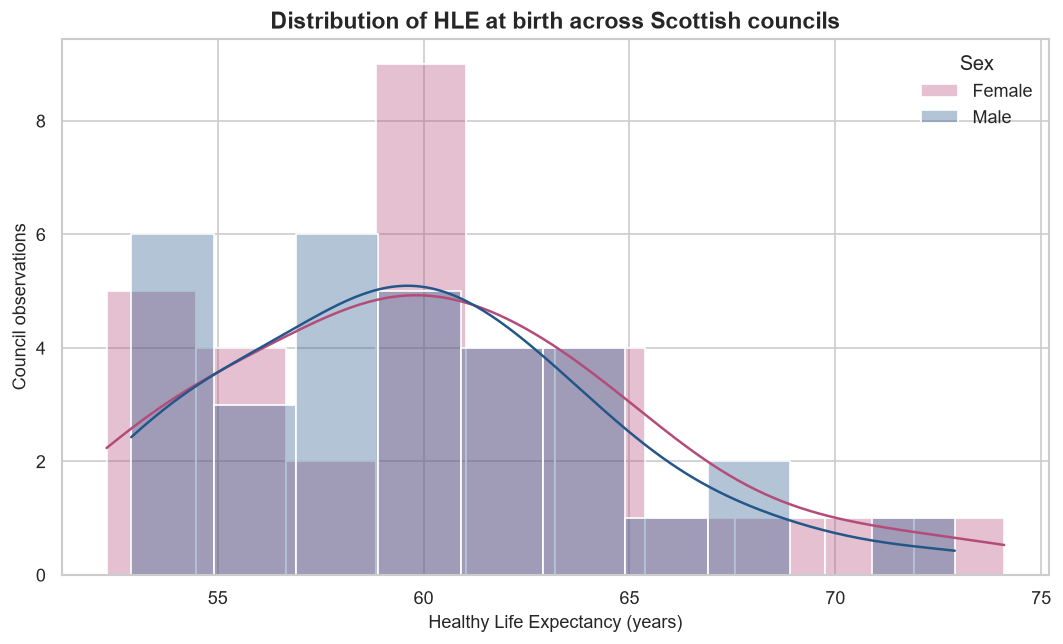

In [6]:
# Plotting the distribution of HLE at birth for female and male council populations.
fig, ax = plt.subplots(figsize=(9, 5.5))
for sex, colour in SEX_COLOURS.items():
    sns.histplot(
        data=at_birth.loc[at_birth["sex"].eq(sex)],
        x="healthy_life_expectancy_years",
        bins=10,
        kde=True,
        alpha=0.35,
        color=colour,
        label=sex,
        ax=ax,
    )
# Labelling, saving and displaying the completed histogram.
ax.set(title="Distribution of HLE at birth across Scottish councils", xlabel="Healthy Life Expectancy (years)", ylabel="Council observations")
ax.legend(title="Sex")
fig.tight_layout()
fig.savefig(figures_dir / "01_hle_histogram.png", bbox_inches="tight")
plt.show()

### Female and male distributions


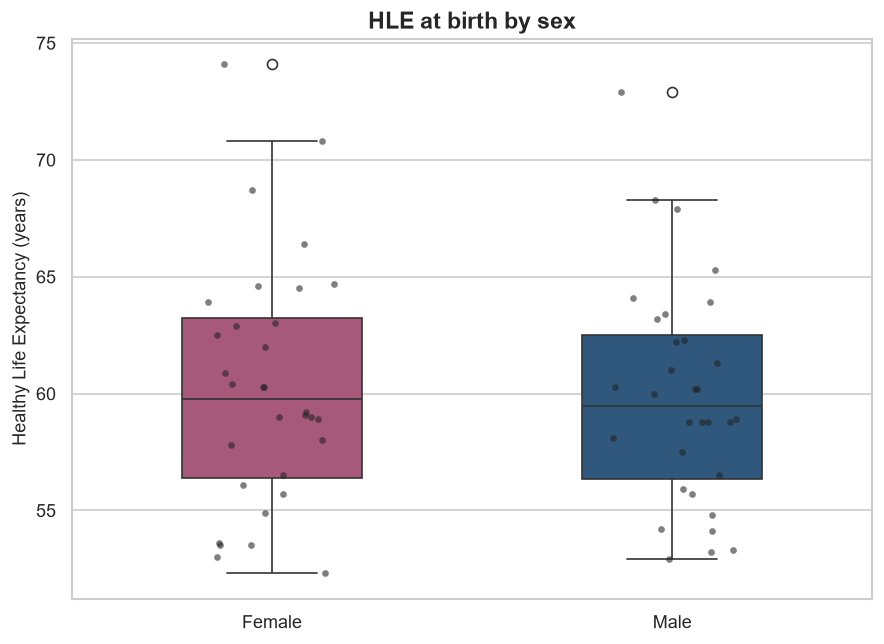

In [7]:
# Comparing the spread of female and male HLE using a boxplot with the individual observations shown.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.boxplot(data=at_birth, x="sex", y="healthy_life_expectancy_years", hue="sex", palette=SEX_COLOURS, width=0.45, legend=False, ax=ax)
sns.stripplot(data=at_birth, x="sex", y="healthy_life_expectancy_years", color="#222222", alpha=0.58, jitter=0.16, size=4, ax=ax)
# Labelling, saving and displaying the completed boxplot.
ax.set(title="HLE at birth by sex", xlabel="", ylabel="Healthy Life Expectancy (years)")
fig.tight_layout()
fig.savefig(figures_dir / "02_hle_boxplot_by_sex.png", bbox_inches="tight")
plt.show()

### Ranked council estimates with 95% confidence intervals

This figure keeps the official uncertainty visible instead of ranking point estimates alone.


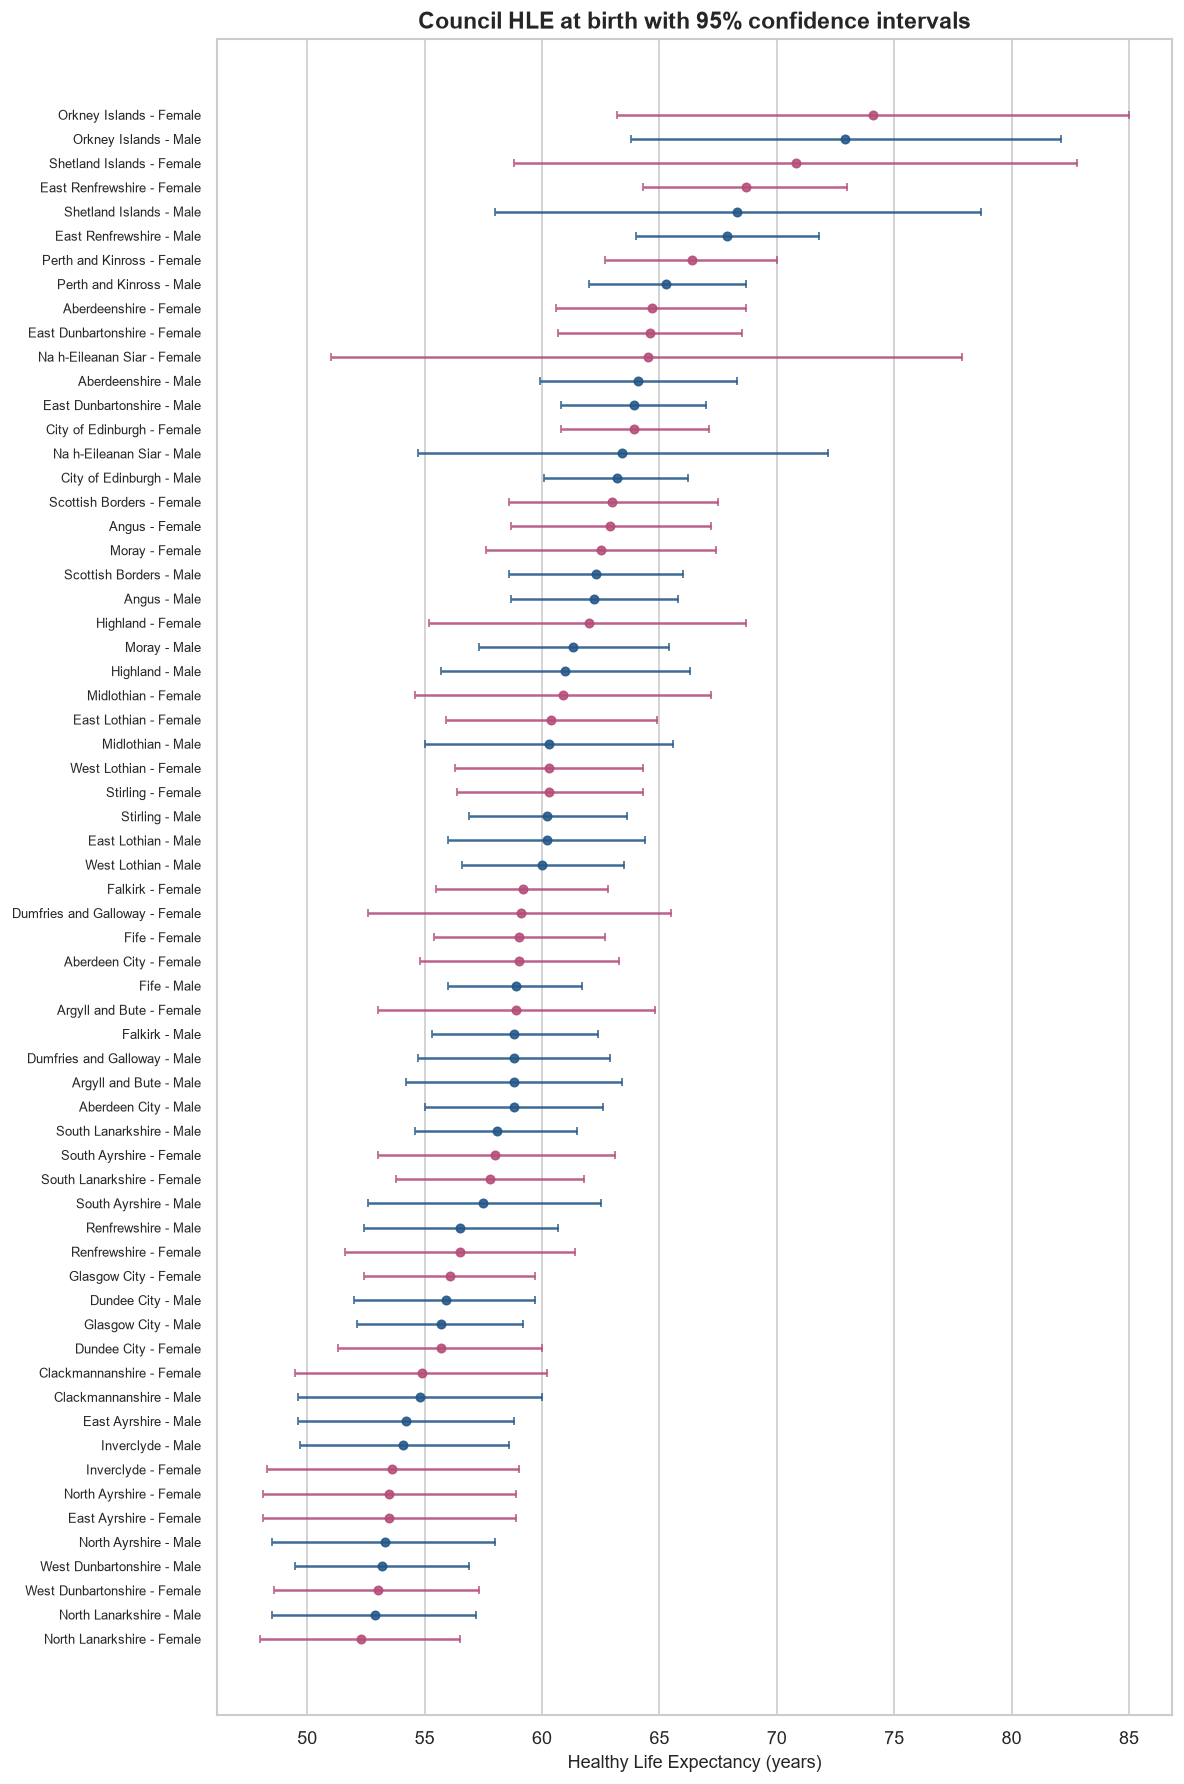

In [8]:
# Ranking the council-sex observations and calculating the two sides of each confidence interval.
ranked = at_birth.sort_values(["healthy_life_expectancy_years", "sex"]).copy()
ranked["council_sex"] = ranked["council_area"] + " - " + ranked["sex"]
ranked["lower_error"] = ranked["healthy_life_expectancy_years"] - ranked["healthy_life_expectancy_lower_95_ci"]
ranked["upper_error"] = ranked["healthy_life_expectancy_upper_95_ci"] - ranked["healthy_life_expectancy_years"]

# Plotting every HLE estimate with its official 95% confidence interval.
fig, ax = plt.subplots(figsize=(10, 15))
for position, (_, row) in enumerate(ranked.iterrows()):
    ax.errorbar(
        row["healthy_life_expectancy_years"], position,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="o", ms=5, capsize=2.5,
        color=SEX_COLOURS[row["sex"]], ecolor=SEX_COLOURS[row["sex"]], alpha=0.88,
    )
# Adding the council labels, saving the figure and displaying it.
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked["council_sex"], fontsize=8)
ax.set(title="Council HLE at birth with 95% confidence intervals", xlabel="Healthy Life Expectancy (years)", ylabel="")
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(figures_dir / "03_ranked_hle_confidence_intervals.png", bbox_inches="tight")
plt.show()

### HLE across the life course

Each point is the mean across 32 councils. The shaded band is the 95% confidence interval across council estimates, not the NRS confidence interval for one council.


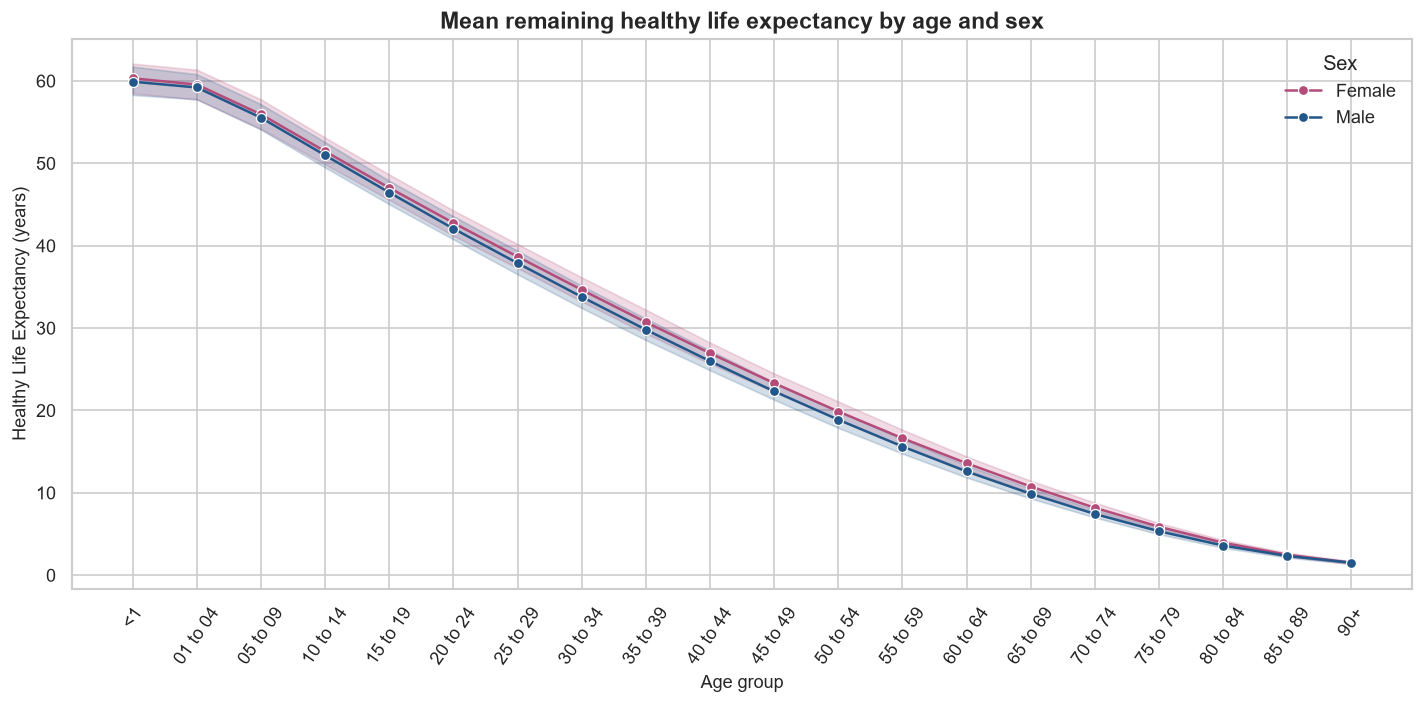

In [9]:
# Putting the HLE age groups into their natural order.
age_order = ["<1", "01 to 04", "05 to 09", "10 to 14", "15 to 19", "20 to 24", "25 to 29", "30 to 34", "35 to 39", "40 to 44", "45 to 49", "50 to 54", "55 to 59", "60 to 64", "65 to 69", "70 to 74", "75 to 79", "80 to 84", "85 to 89", "90+"]
df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

# Plotting the mean remaining HLE pattern across age groups for each sex.
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="age_group", y="healthy_life_expectancy_years", hue="sex",
    palette=SEX_COLOURS, marker="o", errorbar=("ci", 95), ax=ax,
)
# Labelling, saving and displaying the age-profile line plot.
ax.set(title="Mean remaining healthy life expectancy by age and sex", xlabel="Age group", ylabel="Healthy Life Expectancy (years)")
ax.tick_params(axis="x", rotation=55)
ax.legend(title="Sex")
fig.tight_layout()
fig.savefig(figures_dir / "04_hle_age_lineplot.png", bbox_inches="tight")
plt.show()

### Point plot of the sex difference by age


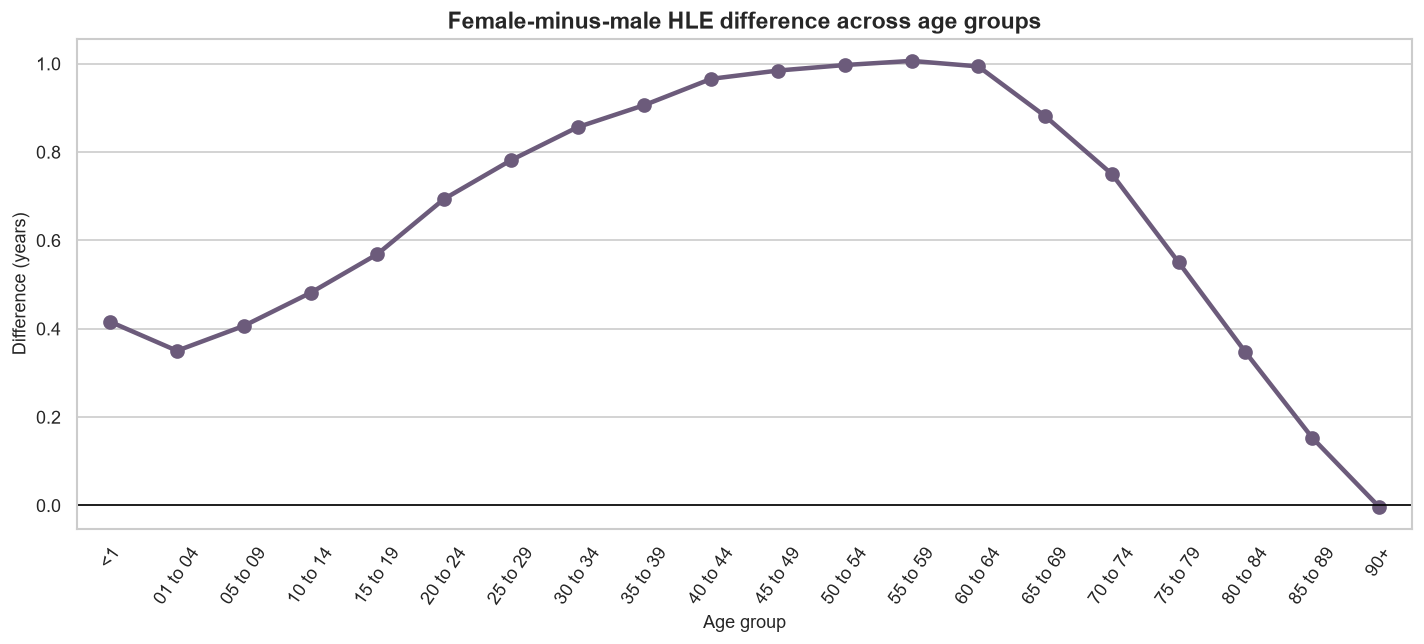

In [10]:
# Calculating the female-minus-male HLE difference at every age group.
age_sex_mean = df.groupby(["age_group", "sex"], observed=True)["healthy_life_expectancy_years"].mean().unstack("sex")
age_sex_difference = (age_sex_mean["Female"] - age_sex_mean["Male"]).reset_index(name="female_minus_male_years")
age_sex_difference.to_csv(tables_dir / "05_sex_difference_by_age.csv", index=False)

# Plotting how the sex difference changes across the age profile.
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.pointplot(data=age_sex_difference, x="age_group", y="female_minus_male_years", color=PURPLE, markers="o", linestyles="-", ax=ax)
# Adding the zero reference line, then saving and displaying the figure.
ax.axhline(0, color="black", lw=1)
ax.set(title="Female-minus-male HLE difference across age groups", xlabel="Age group", ylabel="Difference (years)")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
fig.savefig(figures_dir / "05_sex_difference_pointplot.png", bbox_inches="tight")
plt.show()

### Heatmap of council and age profiles

Female and male estimates are averaged here only to reveal the council-age pattern clearly.


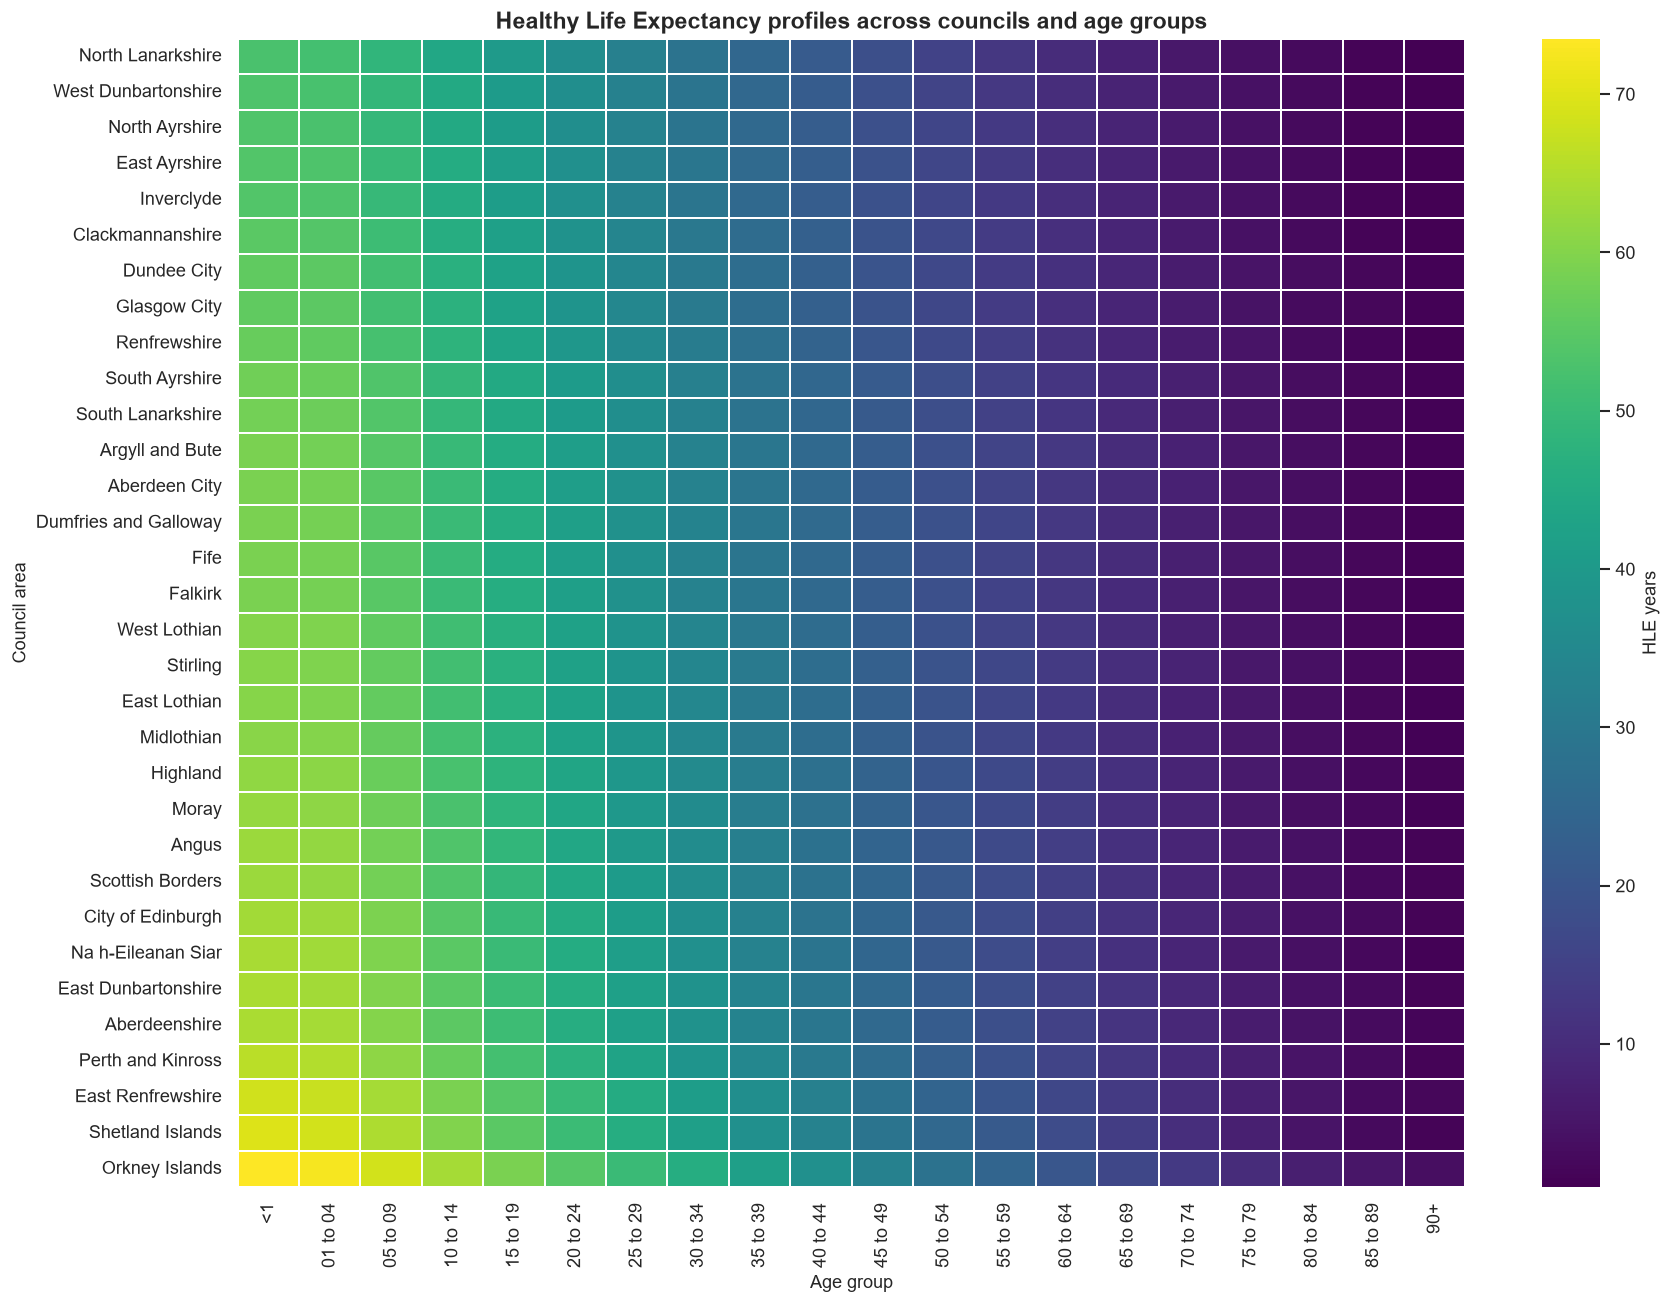

In [11]:
# Arranging the council and age-group HLE values into a matrix for comparison.
age_heatmap = df.pivot_table(index="council_area", columns="age_group", values="healthy_life_expectancy_years", aggfunc="mean", observed=True)
age_heatmap = age_heatmap.loc[age_heatmap["<1"].sort_values().index, age_order]

# Drawing a heatmap to show how HLE profiles vary across councils and ages.
fig, ax = plt.subplots(figsize=(15, 11))
sns.heatmap(age_heatmap, cmap="viridis", linewidths=0.15, cbar_kws={"label": "HLE years"}, ax=ax)
# Labelling, saving and displaying the heatmap.
ax.set(title="Healthy Life Expectancy profiles across councils and age groups", xlabel="Age group", ylabel="Council area")
fig.tight_layout()
fig.savefig(figures_dir / "06_council_age_heatmap.png", bbox_inches="tight")
plt.show()

### Deprivation gradient


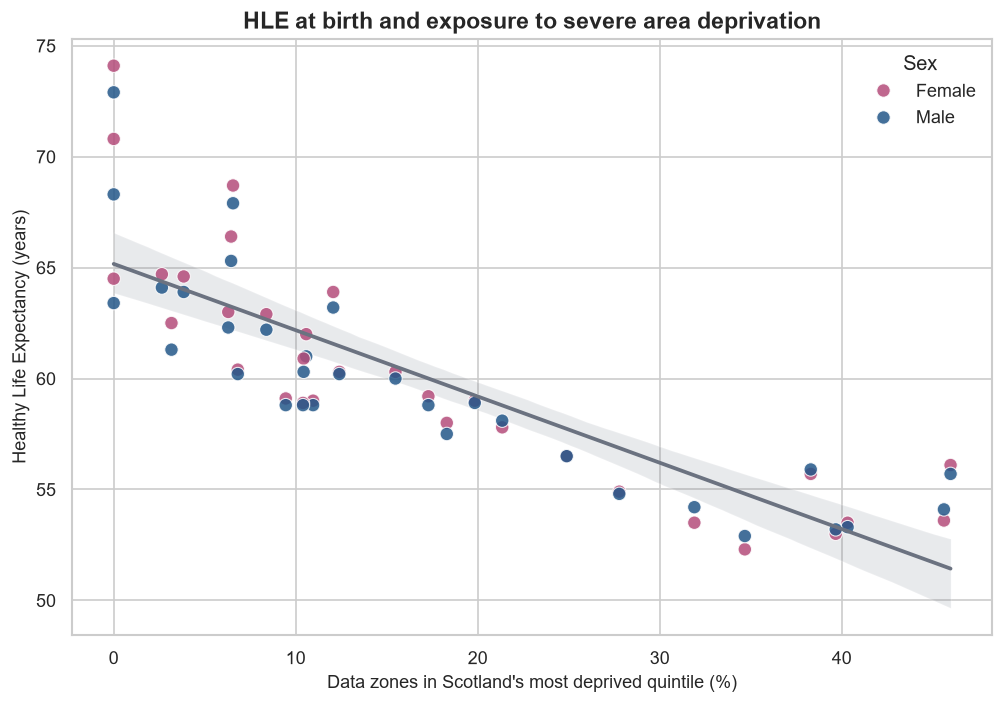

In [12]:
# Plotting the relationship between severe deprivation exposure and HLE at birth.
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.regplot(
    data=at_birth,
    x="simd_most_deprived_quintile_datazones_share_pct",
    y="healthy_life_expectancy_years",
    scatter=False, ci=95, color=GREY, ax=ax,
)
sns.scatterplot(
    data=at_birth,
    x="simd_most_deprived_quintile_datazones_share_pct",
    y="healthy_life_expectancy_years",
    hue="sex", palette=SEX_COLOURS, s=65, alpha=0.85, ax=ax,
)
# Labelling the relationship, saving the figure and displaying it.
ax.set(title="HLE at birth and exposure to severe area deprivation", xlabel="Data zones in Scotland's most deprived quintile (%)", ylabel="Healthy Life Expectancy (years)")
ax.legend(title="Sex")
fig.tight_layout()
fig.savefig(figures_dir / "07_deprivation_scatterplot.png", bbox_inches="tight")
plt.show()

### HLE distribution across deprivation quartiles


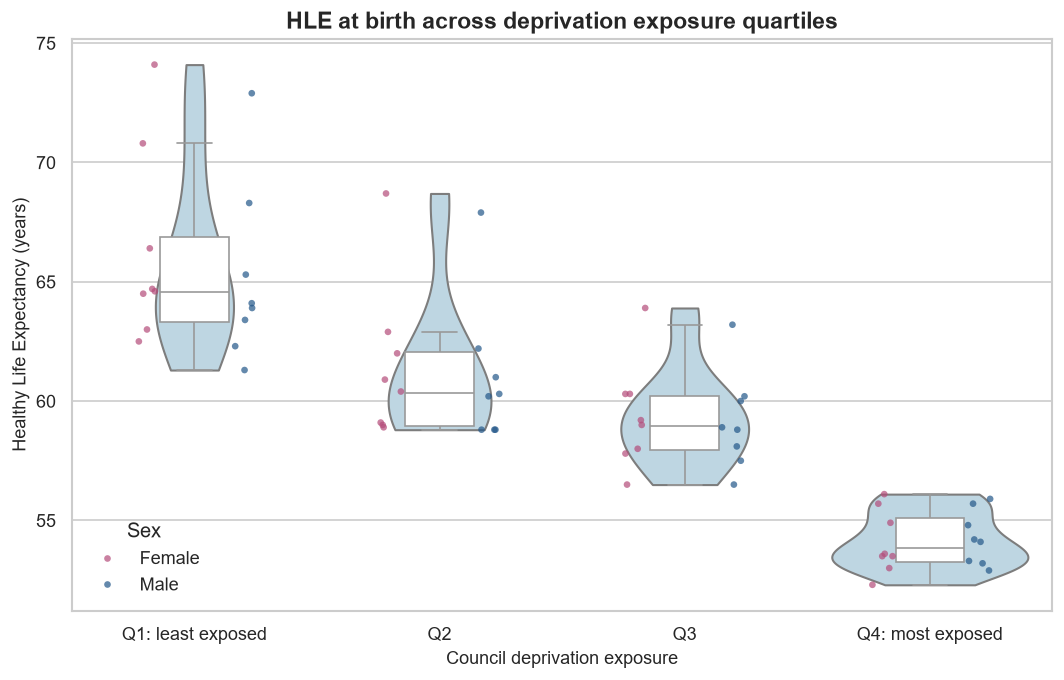

In [13]:
# Comparing HLE distributions across the four council deprivation groups.
quartile_order = ["Q1: least exposed", "Q2", "Q3", "Q4: most exposed"]
fig, ax = plt.subplots(figsize=(9, 5.8))
sns.violinplot(data=at_birth, x="deprivation_quartile", y="healthy_life_expectancy_years", order=quartile_order, inner=None, color="#B8D8E8", cut=0, ax=ax)
sns.boxplot(data=at_birth, x="deprivation_quartile", y="healthy_life_expectancy_years", order=quartile_order, width=0.28, showfliers=False, color="white", ax=ax)
sns.stripplot(data=at_birth, x="deprivation_quartile", y="healthy_life_expectancy_years", order=quartile_order, hue="sex", palette=SEX_COLOURS, dodge=True, alpha=0.7, size=4, ax=ax)
# Labelling, saving and displaying the combined violin, box and point plot.
ax.set(title="HLE at birth across deprivation exposure quartiles", xlabel="Council deprivation exposure", ylabel="Healthy Life Expectancy (years)")
ax.legend(title="Sex", loc="lower left")
fig.tight_layout()
fig.savefig(figures_dir / "08_deprivation_quartile_violin_boxplot.png", bbox_inches="tight")
plt.show()

### Paired female and male estimates within each council

Lines connect estimates from the same council, making the within-council sex difference visible.


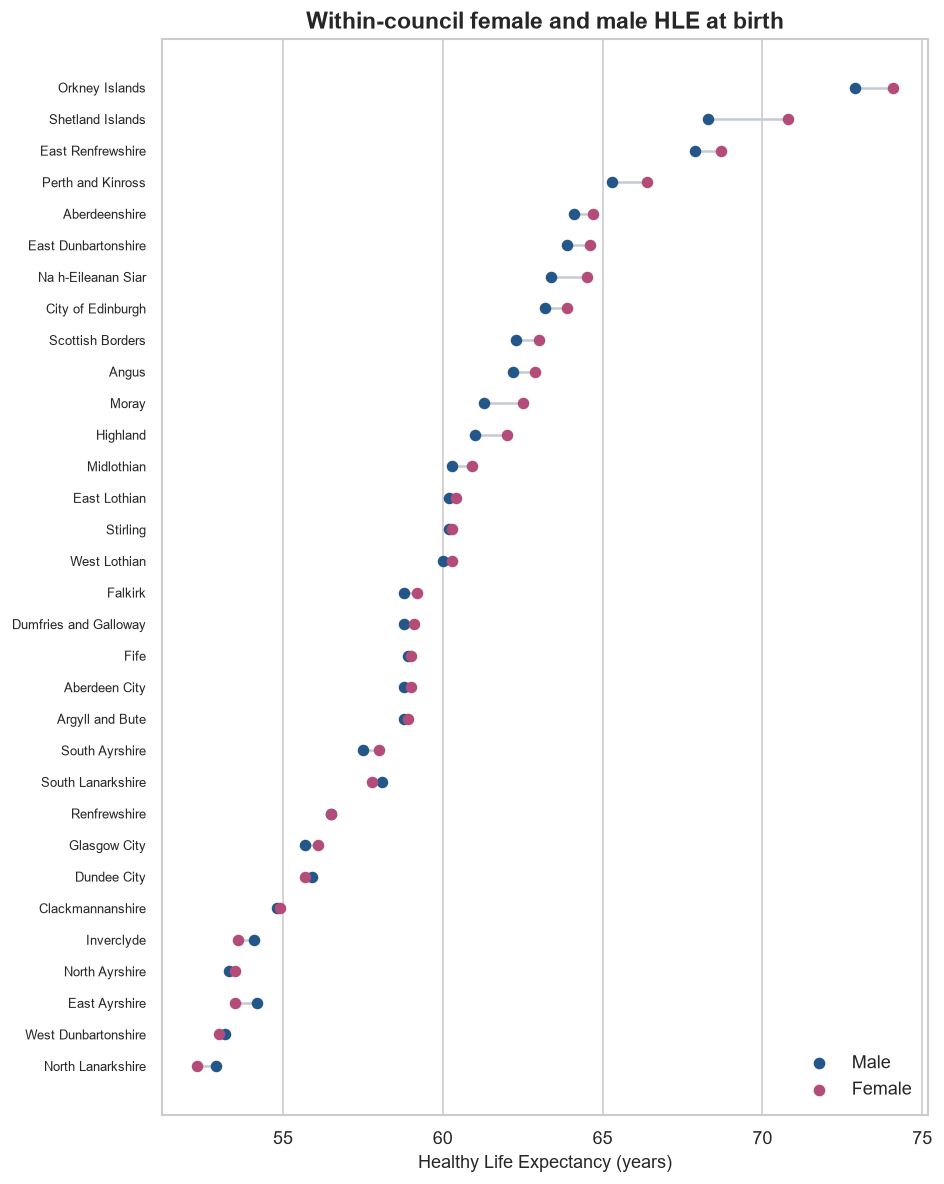

In [14]:
# Placing the female and male HLE values from each council side by side.
paired_plot = at_birth.pivot(index="council_area", columns="sex", values="healthy_life_expectancy_years").dropna().sort_values("Female")
# Connecting the paired values so the within-council sex difference is easy to see.
fig, ax = plt.subplots(figsize=(8, 10))
for position, (council, row) in enumerate(paired_plot.iterrows()):
    ax.plot([row["Male"], row["Female"]], [position, position], color="#C5CBD3", lw=1.5)
    ax.scatter(row["Male"], position, color=SEX_COLOURS["Male"], s=35, zorder=3)
    ax.scatter(row["Female"], position, color=SEX_COLOURS["Female"], s=35, zorder=3)
# Adding the council labels and legend, then saving and displaying the figure.
ax.set_yticks(range(len(paired_plot)))
ax.set_yticklabels(paired_plot.index, fontsize=8)
ax.set(title="Within-council female and male HLE at birth", xlabel="Healthy Life Expectancy (years)", ylabel="")
ax.scatter([], [], color=SEX_COLOURS["Male"], label="Male")
ax.scatter([], [], color=SEX_COLOURS["Female"], label="Female")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(figures_dir / "09_paired_sex_dumbbell_plot.png", bbox_inches="tight")
plt.show()

### Socioeconomic pair plot

This view helps identify broad linear and nonlinear relationships before modelling.


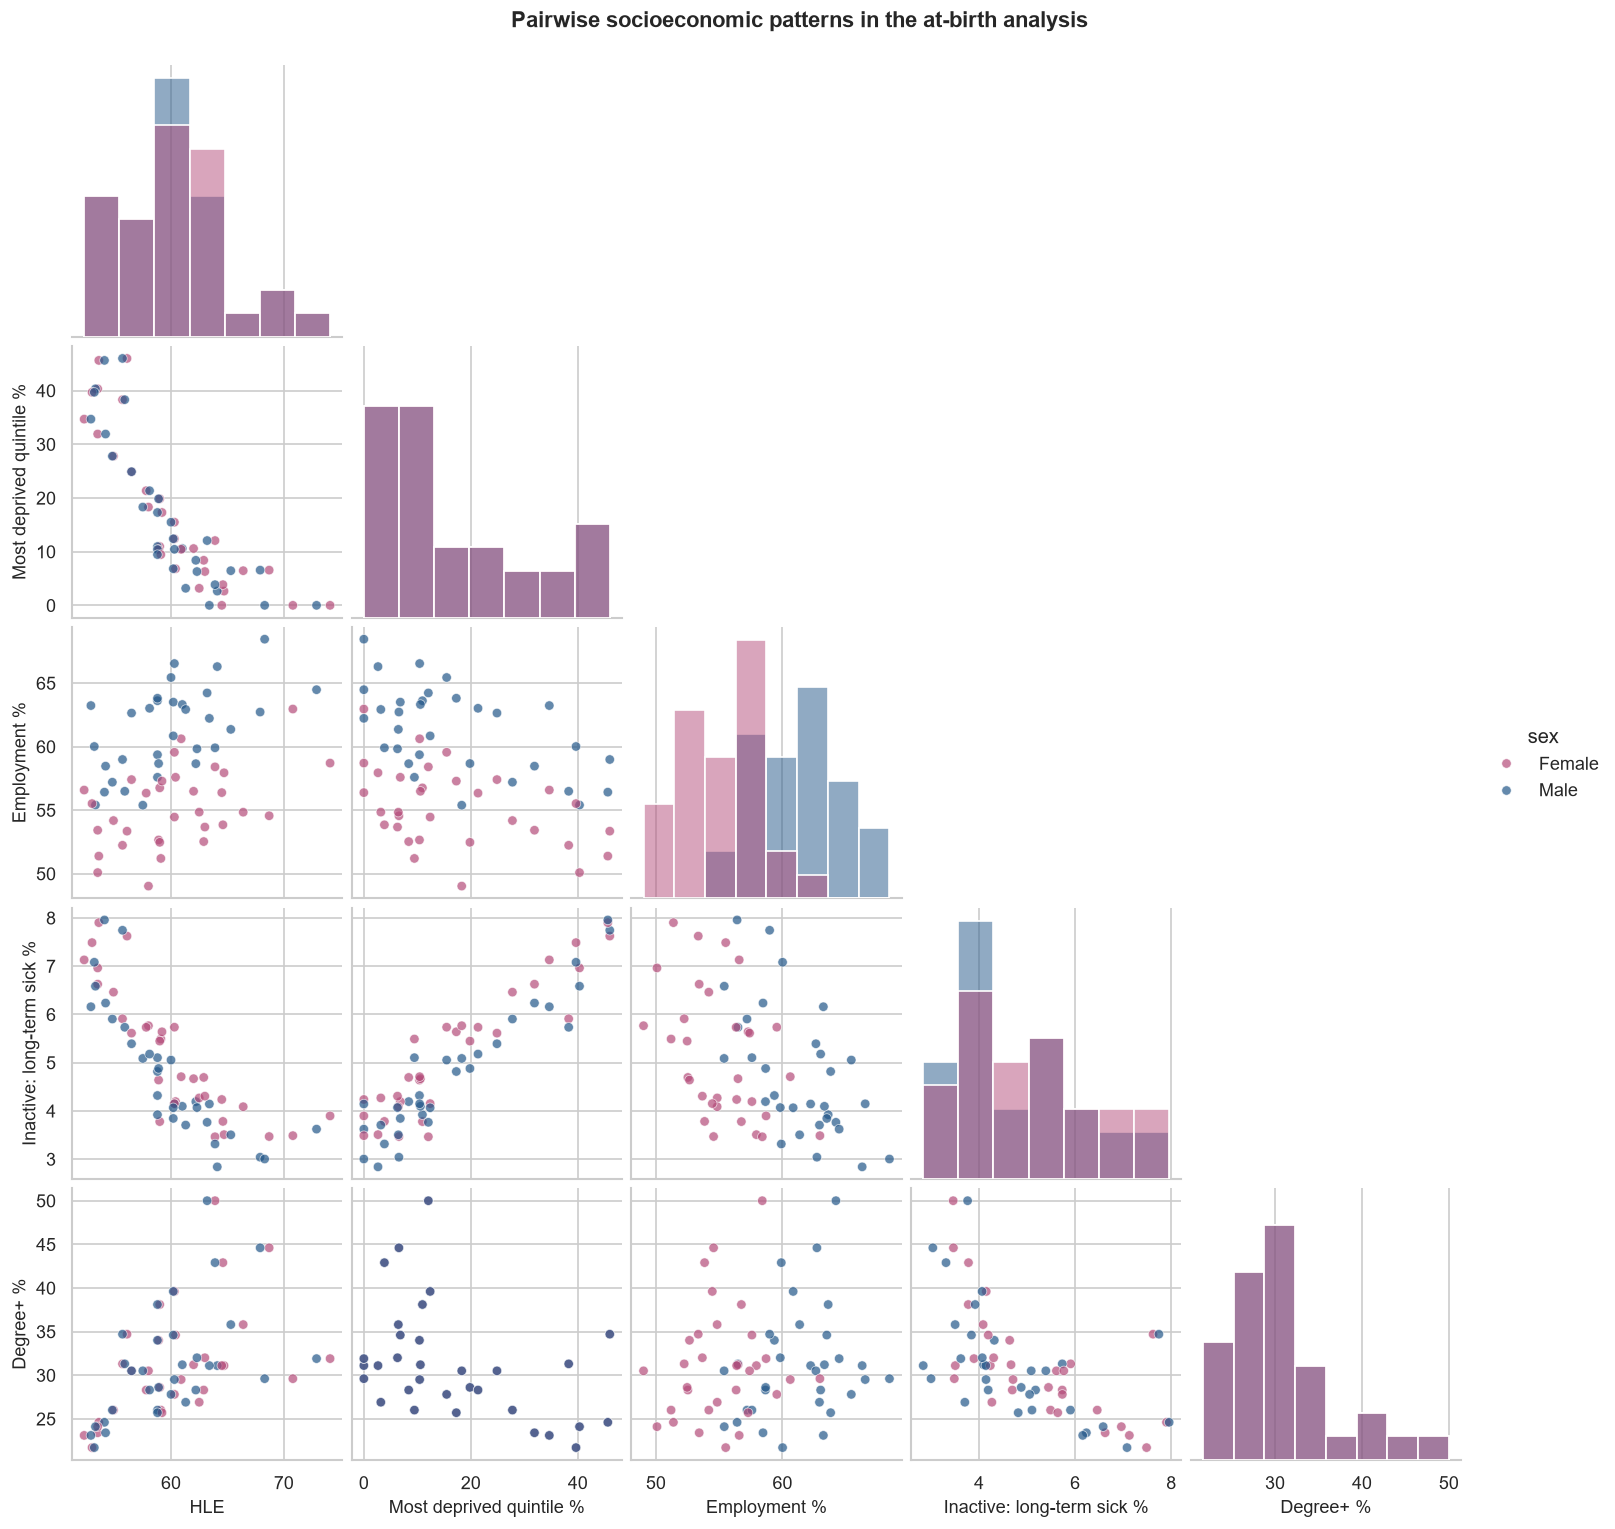

In [15]:
# Selecting and renaming the main socioeconomic fields for a readable pairwise plot.
pair_data = at_birth[[
    "healthy_life_expectancy_years", "simd_most_deprived_quintile_datazones_share_pct",
    "economic_employment_rate_pct", "economic_inactive_long_term_sick_disabled_rate_pct",
    "census_degree_level_qualification_or_above_population_aged_16plus_pct", "sex"
]].rename(columns={
    "healthy_life_expectancy_years": "HLE",
    "simd_most_deprived_quintile_datazones_share_pct": "Most deprived quintile %",
    "economic_employment_rate_pct": "Employment %",
    "economic_inactive_long_term_sick_disabled_rate_pct": "Inactive: long-term sick %",
    "census_degree_level_qualification_or_above_population_aged_16plus_pct": "Degree+ %",
})
# Showing the distributions and pairwise relationships, separated by sex.
pair_grid = sns.pairplot(pair_data, hue="sex", palette=SEX_COLOURS, corner=True, diag_kind="hist", plot_kws={"alpha": 0.7, "s": 32})
pair_grid.fig.suptitle("Pairwise socioeconomic patterns in the at-birth analysis", y=1.02, fontweight="bold")
pair_grid.fig.savefig(figures_dir / "10_socioeconomic_pairplot.png", bbox_inches="tight")
plt.show()

### Correlation matrix

Spearman correlation is used because some variables are not normally distributed. It shows whether variables tend to increase or decrease together, but it does not show cause and effect.


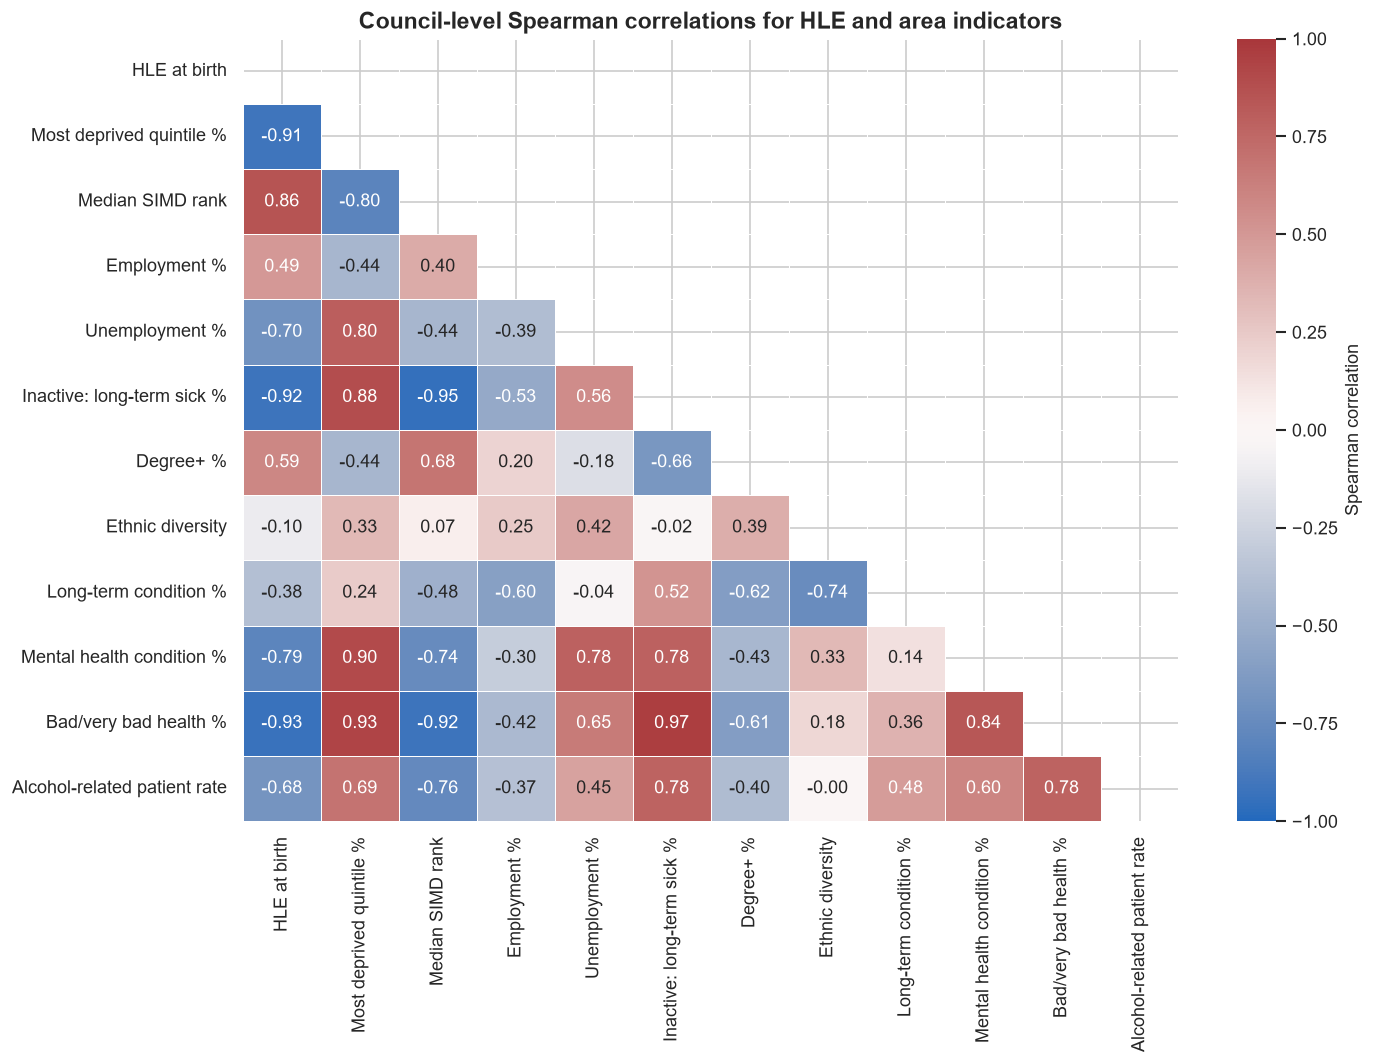

In [16]:
# Choosing clear labels for the HLE, social and health indicators used in the correlation analysis.
correlation_features = {
    "healthy_life_expectancy_years": "HLE at birth",
    "simd_most_deprived_quintile_datazones_share_pct": "Most deprived quintile %",
    "simd_rank_median": "Median SIMD rank",
    "economic_employment_rate_pct": "Employment %",
    "economic_unemployment_rate_pct": "Unemployment %",
    "economic_inactive_long_term_sick_disabled_rate_pct": "Inactive: long-term sick %",
    "census_degree_level_qualification_or_above_population_aged_16plus_pct": "Degree+ %",
    "census_ethnic_diversity_simpson_index_broad_groups": "Ethnic diversity",
    "census_long_term_illness_disease_or_condition_pct": "Long-term condition %",
    "census_mental_health_condition_pct": "Mental health condition %",
    "census_bad_or_very_bad_general_health_age_standardised_pct": "Bad/very bad health %",
    "hospital_alcohol_related_patients_easr_per_100000_2023_24": "Alcohol-related patient rate",
}

# Averaging the sex-specific rows so each council contributes once to the correlations.
correlation_council_data = (
    at_birth.groupby("council_area_code", as_index=False)[list(correlation_features)]
    .mean()
)
# Calculating and saving the council-level Spearman correlation matrix.
correlation_matrix = (
    correlation_council_data[list(correlation_features)]
    .rename(columns=correlation_features)
    .corr(method="spearman")
)
correlation_matrix.to_csv(tables_dir / "06_spearman_correlation_matrix.csv")

# Plotting the lower half of the matrix to avoid repeating the same correlations.
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
# Labelling, saving and displaying the correlation heatmap.
ax.set(title="Council-level Spearman correlations for HLE and area indicators")
fig.tight_layout()
fig.savefig(figures_dir / "11_spearman_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### Correlations with HLE, including uncertainty and multiple-testing control

The Benjamini-Hochberg procedure helps control false positives when testing many correlations.

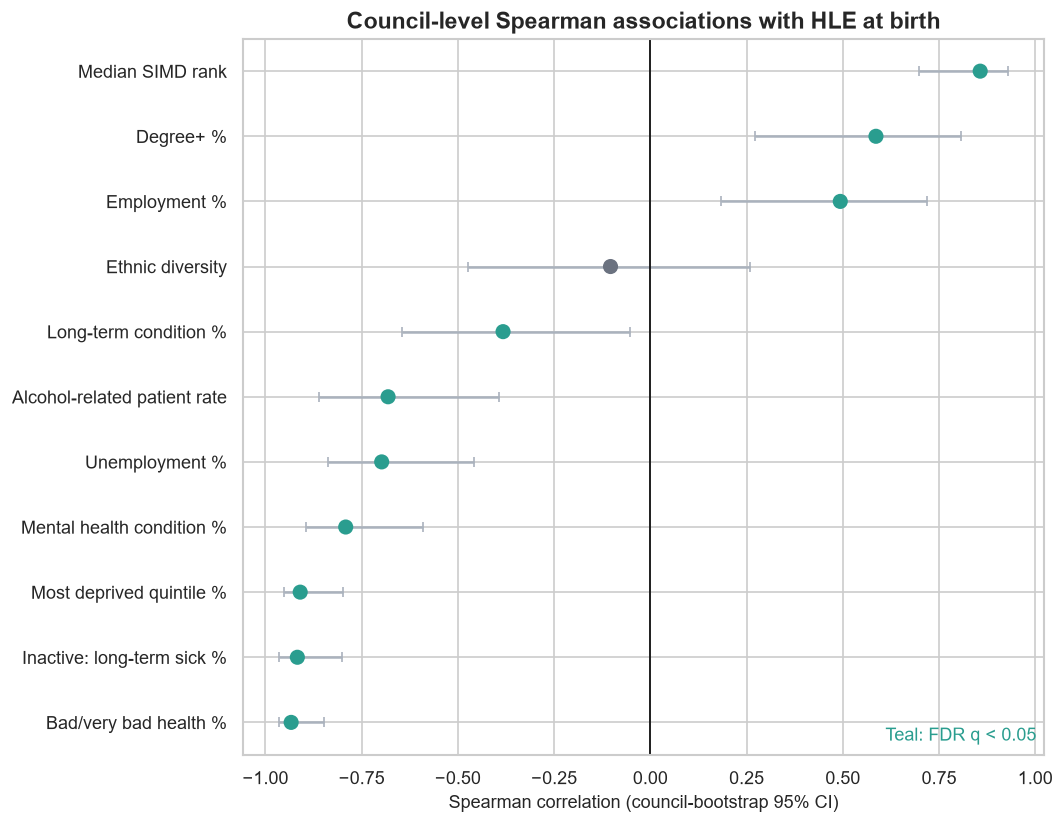

In [17]:
# Estimating each indicator's Spearman association with council HLE.
correlation_rows = []
for column, label in list(correlation_features.items())[1:]:
    rho, p_value = stats.spearmanr(
        correlation_council_data[column],
        correlation_council_data["healthy_life_expectancy_years"],
    )
    # Resampling whole councils to show the uncertainty around each correlation.
    bootstrap_rho = []
    for _ in range(2000):
        sampled_positions = rng.choice(
            len(correlation_council_data),
            size=len(correlation_council_data),
            replace=True,
        )
        sampled = correlation_council_data.iloc[sampled_positions]
        bootstrap_rho.append(
            stats.spearmanr(
                sampled[column],
                sampled["healthy_life_expectancy_years"],
            ).statistic
        )
    correlation_rows.append({
        "feature": column,
        "feature_label": label,
        "n_councils": len(correlation_council_data),
        "spearman_rho": rho,
        "p_value": p_value,
        "ci_lower": np.nanpercentile(bootstrap_rho, 2.5),
        "ci_upper": np.nanpercentile(bootstrap_rho, 97.5),
    })

# Adjusting the p-values for multiple testing and preparing the results for plotting.
correlation_results = pd.DataFrame(correlation_rows).sort_values("p_value").reset_index(drop=True)
correlation_results["bh_rank"] = np.arange(1, len(correlation_results) + 1)
correlation_results["q_value"] = (
    correlation_results["p_value"] * len(correlation_results) / correlation_results["bh_rank"]
).clip(upper=1)
correlation_results["q_value"] = correlation_results["q_value"][::-1].cummin()[::-1]
correlation_results = correlation_results.sort_values("spearman_rho")
correlation_results.to_csv(tables_dir / "07_correlations_with_hle.csv", index=False)

# Plotting the correlations and their council-bootstrap confidence intervals.
fig, ax = plt.subplots(figsize=(9, 7))
y_positions = np.arange(len(correlation_results))
significant = correlation_results["q_value"].lt(0.05)
colours = np.where(significant, TEAL, GREY)
# Drawing the uncertainty intervals before adding the correlation points.
ax.errorbar(
    correlation_results["spearman_rho"],
    y_positions,
    xerr=[
        correlation_results["spearman_rho"] - correlation_results["ci_lower"],
        correlation_results["ci_upper"] - correlation_results["spearman_rho"],
    ],
    fmt="none",
    ecolor="#AAB2BD",
    capsize=3,
    zorder=1,
)
ax.scatter(correlation_results["spearman_rho"], y_positions, c=colours, s=65, zorder=2)
ax.axvline(0, color="black", lw=1)
# Adding readable labels and highlighting results that remain significant after adjustment.
ax.set_yticks(y_positions)
ax.set_yticklabels(correlation_results["feature_label"])
ax.set(
    title="Council-level Spearman associations with HLE at birth",
    xlabel="Spearman correlation (council-bootstrap 95% CI)",
    ylabel="",
)
ax.text(0.99, 0.02, "Teal: FDR q < 0.05", transform=ax.transAxes, ha="right", color=TEAL)
fig.tight_layout()
fig.savefig(figures_dir / "12_correlation_forest_plot.png", bbox_inches="tight")
plt.show()

### Health-context relationships

These variables are used to examine health patterns but are excluded from the main model because they overlap with HLE

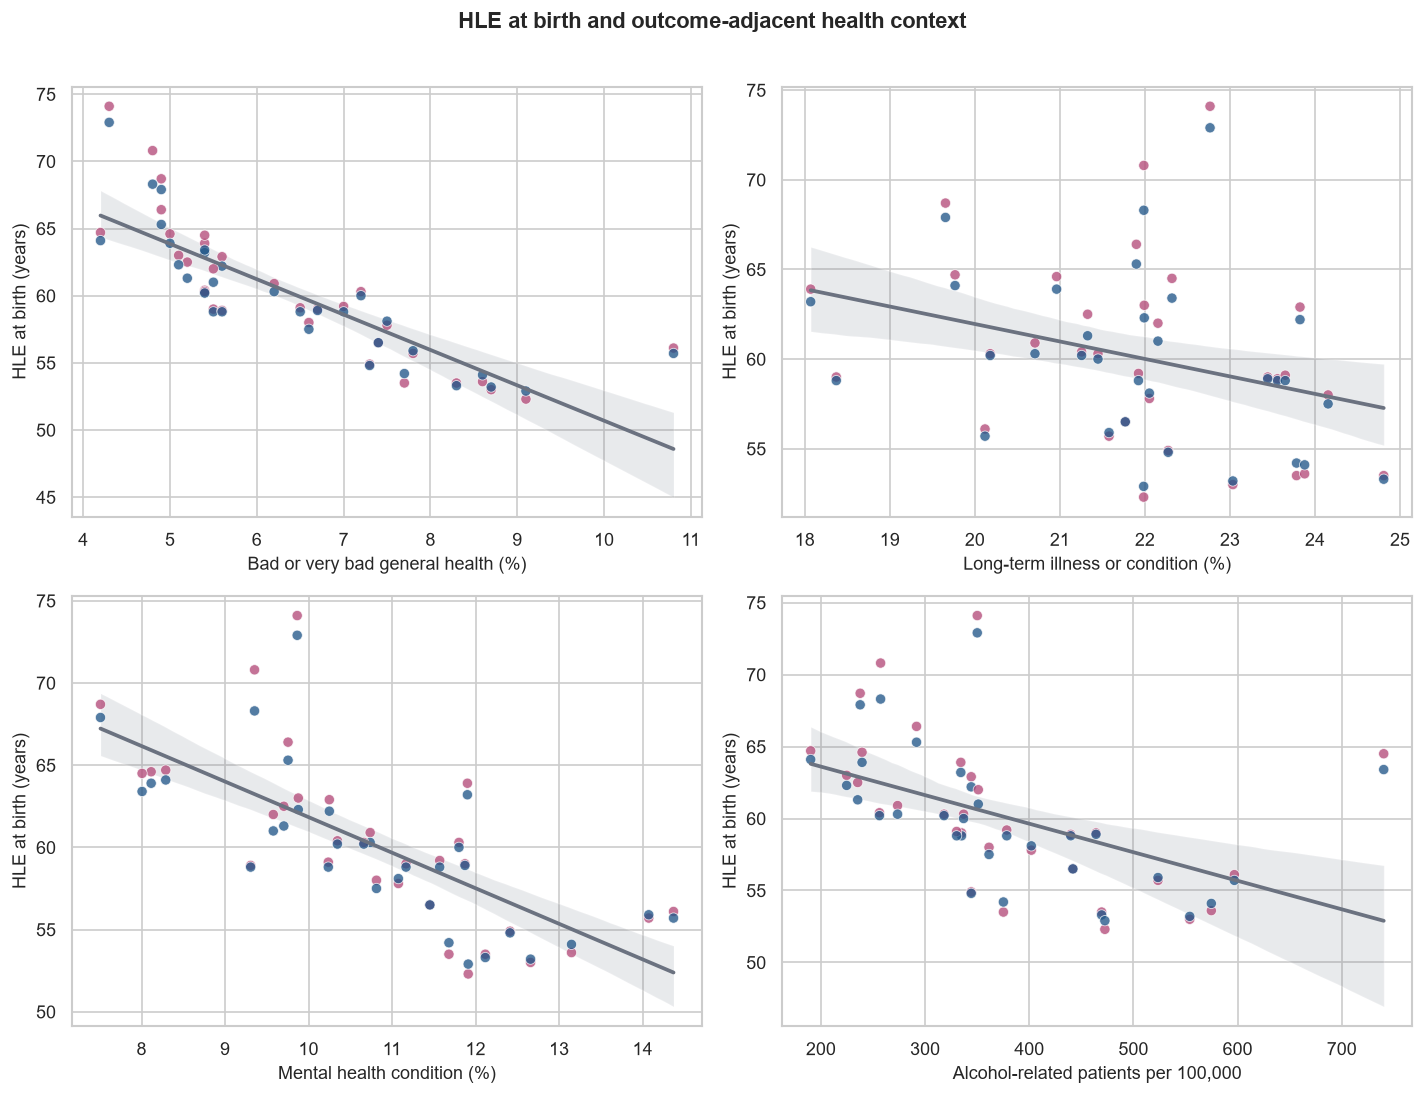

In [18]:
# Selecting the health-context indicators used only for descriptive and sensitivity analysis.
health_context_columns = [
    "census_bad_or_very_bad_general_health_age_standardised_pct",
    "census_long_term_illness_disease_or_condition_pct",
    "census_mental_health_condition_pct",
    "hospital_alcohol_related_patients_easr_per_100000_2023_24",
]
health_context_labels = [
    "Bad or very bad general health (%)",
    "Long-term illness or condition (%)",
    "Mental health condition (%)",
    "Alcohol-related patients per 100,000",
]

# Plotting each health-context indicator against HLE in a four-panel figure.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for axis, column, label in zip(axes.flat, health_context_columns, health_context_labels):
    sns.regplot(data=at_birth, x=column, y="healthy_life_expectancy_years", scatter=False, color=GREY, ax=axis)
    sns.scatterplot(data=at_birth, x=column, y="healthy_life_expectancy_years", hue="sex", palette=SEX_COLOURS, s=38, alpha=0.78, legend=False, ax=axis)
    axis.set(xlabel=label, ylabel="HLE at birth (years)")
# Adding the overall title, then saving and displaying the figure.
fig.suptitle("HLE at birth and outcome-adjacent health context", fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(figures_dir / "13_health_context_small_multiples.png", bbox_inches="tight")
plt.show()

### Standardised council profiles

The clustered heatmap is exploratory. It groups councils with similar social and health contexts; the groups are not formal deprivation categories.


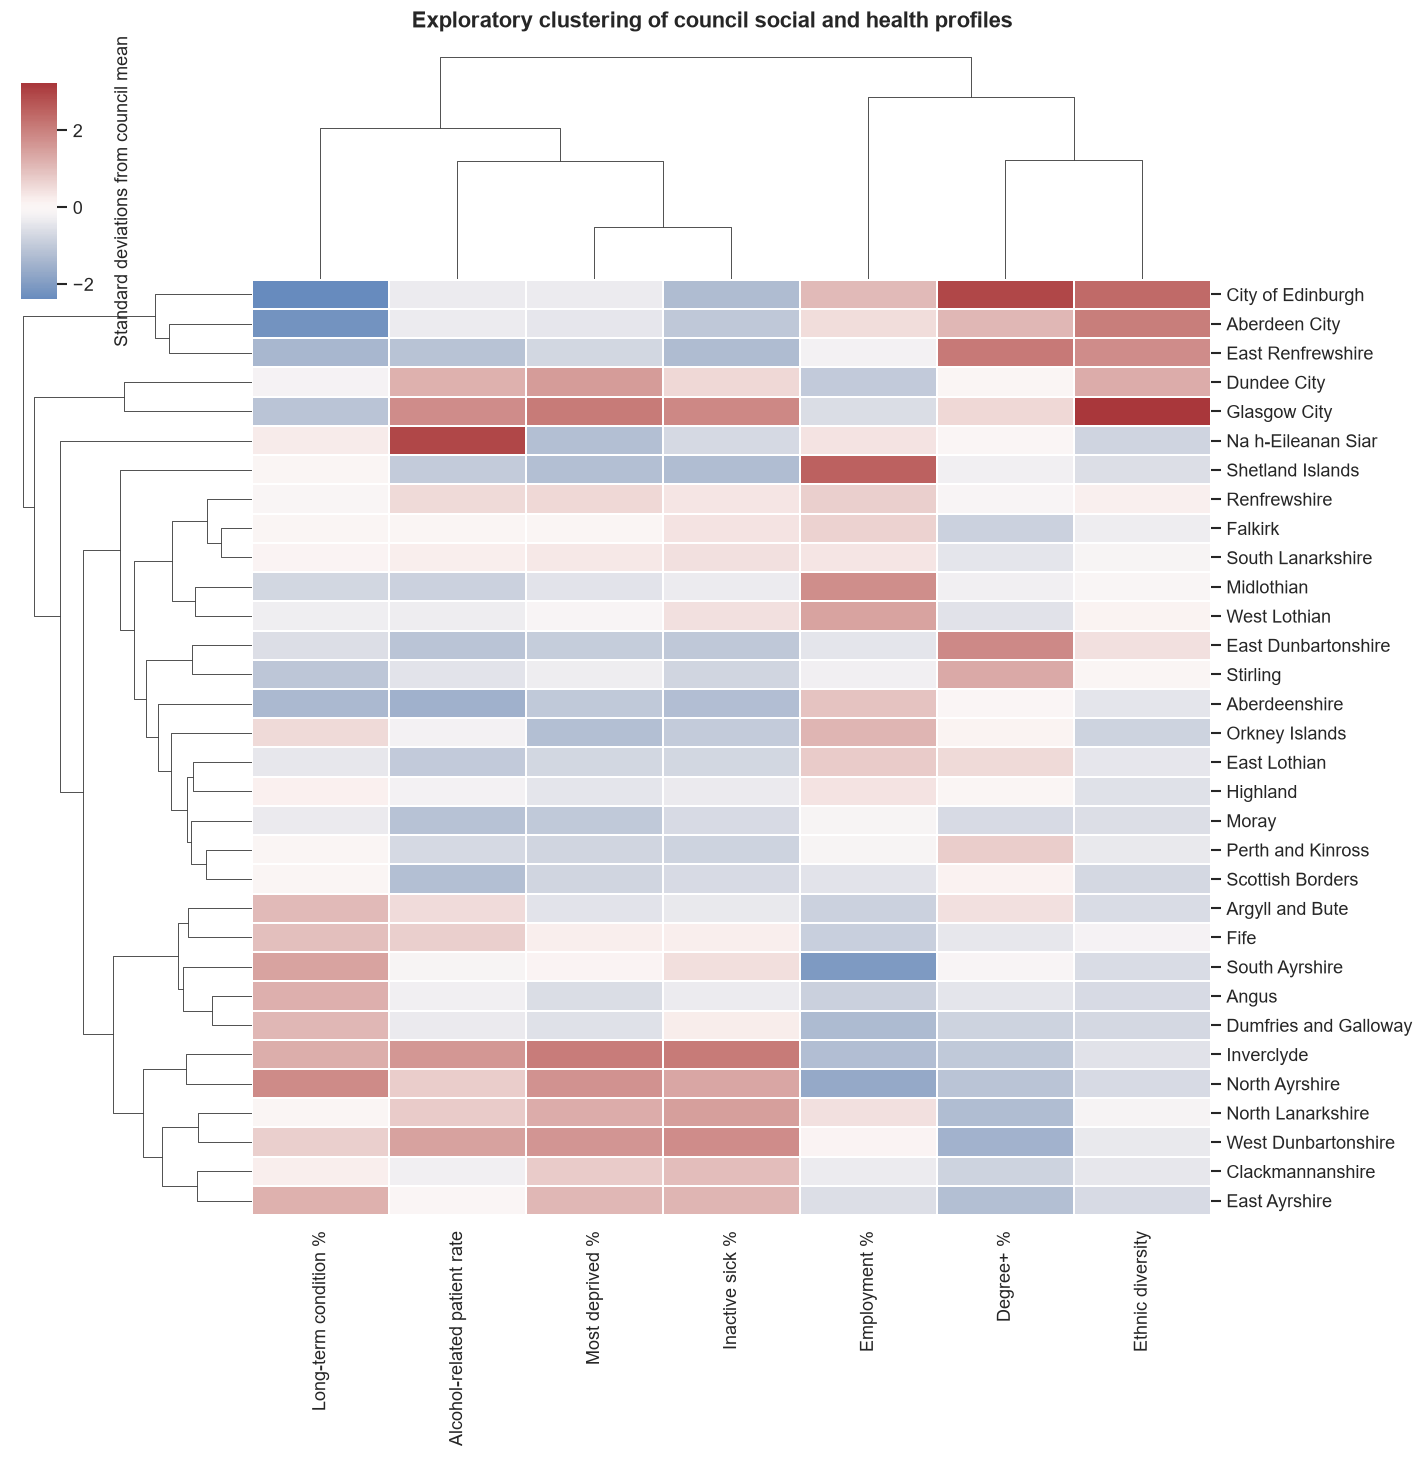

In [19]:
# Selecting and renaming the indicators used to compare council profiles.
profile_columns = {
    "simd_most_deprived_quintile_datazones_share_pct": "Most deprived %",
    "economic_employment_rate_pct": "Employment %",
    "economic_inactive_long_term_sick_disabled_rate_pct": "Inactive sick %",
    "census_degree_level_qualification_or_above_population_aged_16plus_pct": "Degree+ %",
    "census_ethnic_diversity_simpson_index_broad_groups": "Ethnic diversity",
    "census_long_term_illness_disease_or_condition_pct": "Long-term condition %",
    "hospital_alcohol_related_patients_easr_per_100000_2023_24": "Alcohol-related patient rate",
}
# Creating one profile per council and standardising the indicators to a common scale.
profiles = at_birth.groupby("council_area")[[*profile_columns]].first().rename(columns=profile_columns)
profiles.index.name = None
profiles.columns.name = None
profiles_standardised = pd.DataFrame(
    StandardScaler().fit_transform(profiles),
    index=profiles.index,
    columns=profiles.columns,
)
# Clustering councils with similar profiles and displaying the standardised values as a heatmap.
cluster_grid = sns.clustermap(
    profiles_standardised,
    cmap="vlag",
    center=0,
    figsize=(12, 12),
    linewidths=0.15,
    cbar_pos=(0.02, 0.81, 0.025, 0.15),
    cbar_kws={"label": "Standard deviations from council mean"},
)
# Finishing the labels, saving the clustered heatmap and displaying it.
cluster_grid.ax_heatmap.set_xlabel("")
cluster_grid.ax_heatmap.set_ylabel("")
cluster_grid.cax.set_ylabel("Standard deviations from council mean", rotation=90, labelpad=12)
cluster_grid.fig.suptitle(
    "Exploratory clustering of council social and health profiles",
    y=1.01,
    fontweight="bold",
)
cluster_grid.fig.savefig(figures_dir / "14_council_profile_clustered_heatmap.png", bbox_inches="tight")
plt.show()

### Principal component map of councils

PCA combines the profile indicators into two dimensions. It is used to show which councils have similar profiles, not to show cause and effect.


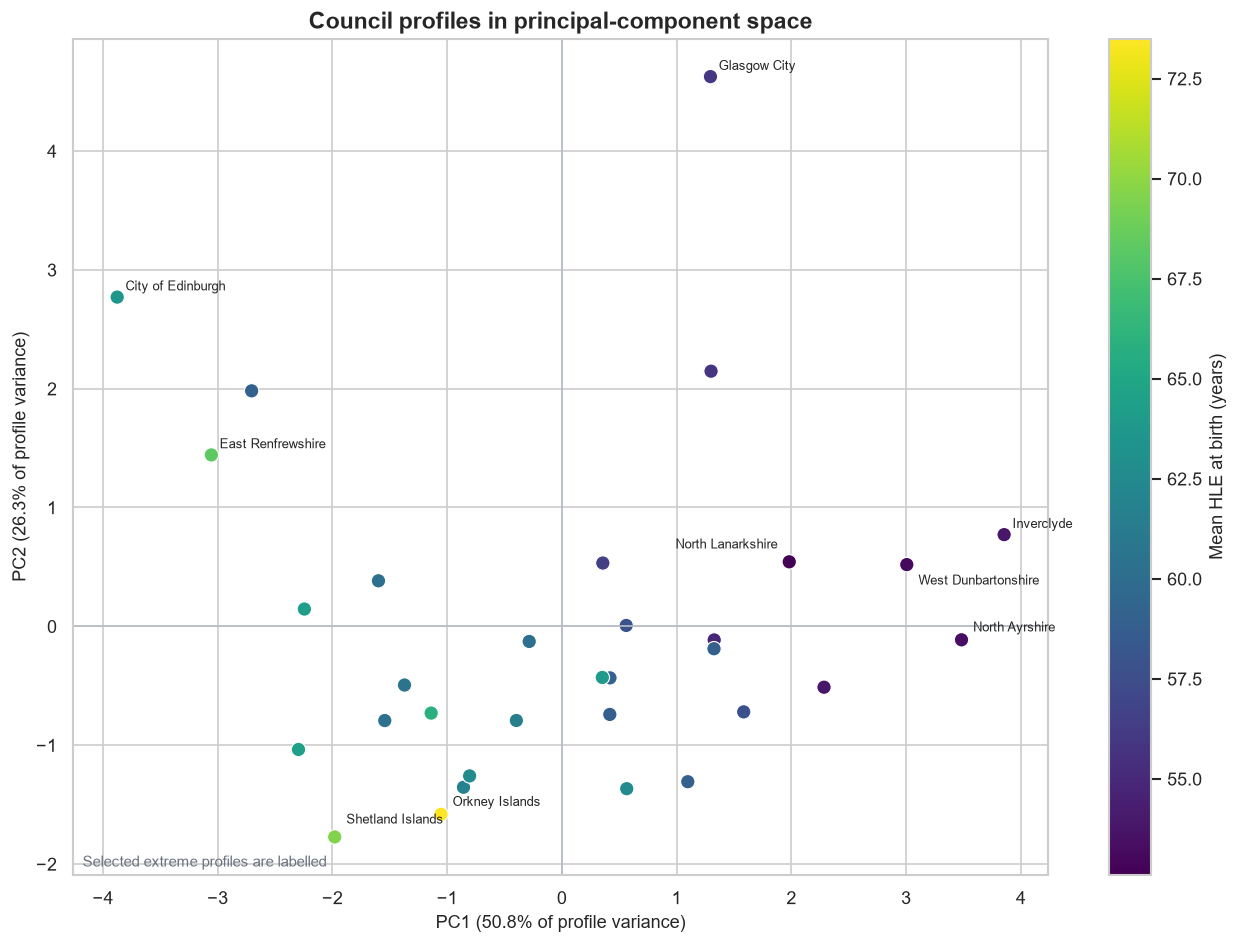

In [20]:
# Reducing the standardised council profiles to two principal components.
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(profiles_standardised)
# Combining the component scores with council HLE and deprivation information, then saving the PCA tables.
pca_table = pd.DataFrame(pca_scores, index=profiles.index, columns=["PC1", "PC2"]).reset_index(names="council_area")
pca_table = pca_table.merge(
    council_context[["council_area", "council_mean_hle", "deprivation_quartile"]],
    on="council_area",
)
pca_loadings = pd.DataFrame(pca.components_.T, index=profiles.columns, columns=["PC1", "PC2"])
pca_table.to_csv(tables_dir / "08_council_pca_scores.csv", index=False)
pca_loadings.to_csv(tables_dir / "09_council_pca_loadings.csv")

# Selecting only the most distinctive councils for labels so the chart remains readable.
label_councils = set()
for selection_column in ["PC1", "PC2", "council_mean_hle"]:
    label_councils.update(pca_table.nlargest(2, selection_column)["council_area"])
    label_councils.update(pca_table.nsmallest(2, selection_column)["council_area"])

# Plotting the councils in principal-component space and colouring them by mean HLE.
fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    pca_table["PC1"],
    pca_table["PC2"],
    c=pca_table["council_mean_hle"],
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.7,
)
# Using small label adjustments to reduce overlap between nearby council names.
pca_label_offsets = {
    "North Lanarkshire": (-7, 8, "right"),
    "West Dunbartonshire": (7, -12, "left"),
    "North Ayrshire": (7, 5, "left"),
    "Shetland Islands": (7, 8, "left"),
    "Orkney Islands": (7, 5, "left"),
}
for _, row in pca_table.loc[pca_table["council_area"].isin(label_councils)].iterrows():
    text_x, text_y, alignment = pca_label_offsets.get(row["council_area"], (5, 4, "left"))
    ax.annotate(
        row["council_area"],
        (row["PC1"], row["PC2"]),
        xytext=(text_x, text_y),
        textcoords="offset points",
        fontsize=8,
        ha=alignment,
    )
# Adding reference lines and explanatory labels, then saving and displaying the figure.
ax.axhline(0, color="#B8BEC6", lw=1)
ax.axvline(0, color="#B8BEC6", lw=1)
ax.set(
    title="Council profiles in principal-component space",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% of profile variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% of profile variance)",
)
ax.text(
    0.01,
    0.01,
    "Selected extreme profiles are labelled",
    transform=ax.transAxes,
    color=GREY,
    fontsize=9,
)
fig.colorbar(scatter, ax=ax, label="Mean HLE at birth (years)")
fig.tight_layout()
fig.savefig(figures_dir / "15_council_pca_map.png", bbox_inches="tight")
plt.show()

## 4. Statistical analysis


### Paired comparison between female and male HLE

The paired design respects the fact that female and male estimates come from the same council. Both the paired t-test and the Wilcoxon signed-rank test are reported.


In [21]:
# Pairing the female and male HLE values within each council and calculating their difference.
paired_hle = at_birth.pivot(index="council_area_code", columns="sex", values="healthy_life_expectancy_years").dropna()
paired_difference = paired_hle["Female"] - paired_hle["Male"]
# Estimating a confidence interval for the mean sex difference and running paired statistical tests.
bootstrap_paired_means = np.mean(rng.choice(paired_difference.to_numpy(), size=(10000, len(paired_difference)), replace=True), axis=1)
t_test = stats.ttest_rel(paired_hle["Female"], paired_hle["Male"])
wilcoxon_test = stats.wilcoxon(paired_hle["Female"], paired_hle["Male"], zero_method="wilcox")

# Collecting, saving and displaying the paired-test results.
paired_test_results = pd.DataFrame({
    "measure": ["Mean female-minus-male difference", "Paired t-test", "Wilcoxon signed-rank test"],
    "estimate": [paired_difference.mean(), t_test.statistic, wilcoxon_test.statistic],
    "ci_lower": [np.percentile(bootstrap_paired_means, 2.5), np.nan, np.nan],
    "ci_upper": [np.percentile(bootstrap_paired_means, 97.5), np.nan, np.nan],
    "p_value": [np.nan, t_test.pvalue, wilcoxon_test.pvalue],
})
paired_test_results.to_csv(tables_dir / "10_paired_sex_tests.csv", index=False)
print(paired_test_results.round(4).to_string(index=False))

                          measure  estimate  ci_lower  ci_upper  p_value
Mean female-minus-male difference    0.4156    0.2063    0.6406      NaN
                    Paired t-test    3.6993       NaN       NaN   0.0008
        Wilcoxon signed-rank test   81.5000       NaN       NaN   0.0011


### Absolute and relative deprivation inequality

The most and least exposed quartiles each contain eight councils. Bootstrap intervals resample whole councils.


In [22]:
# Comparing mean HLE in the least and most deprivation-exposed council groups.
least_exposed = council_context.loc[council_context["deprivation_quartile"].eq("Q1: least exposed"), "council_mean_hle"]
most_exposed = council_context.loc[council_context["deprivation_quartile"].eq("Q4: most exposed"), "council_mean_hle"]
observed_gap = least_exposed.mean() - most_exposed.mean()
observed_ratio = least_exposed.mean() / most_exposed.mean()

# Resampling the two groups to estimate uncertainty around the absolute gap and relative ratio.
bootstrap_gaps = []
bootstrap_ratios = []
for _ in range(10000):
    sampled_least = rng.choice(least_exposed, size=len(least_exposed), replace=True)
    sampled_most = rng.choice(most_exposed, size=len(most_exposed), replace=True)
    bootstrap_gaps.append(sampled_least.mean() - sampled_most.mean())
    bootstrap_ratios.append(sampled_least.mean() / sampled_most.mean())

# Collecting, saving and displaying the deprivation inequality measures.
inequality_results = pd.DataFrame({
    "measure": ["Absolute HLE gap (least minus most exposed quartile)", "Relative HLE ratio (least divided by most exposed quartile)"],
    "estimate": [observed_gap, observed_ratio],
    "ci_lower": [np.percentile(bootstrap_gaps, 2.5), np.percentile(bootstrap_ratios, 2.5)],
    "ci_upper": [np.percentile(bootstrap_gaps, 97.5), np.percentile(bootstrap_ratios, 97.5)],
})
inequality_results.to_csv(tables_dir / "11_deprivation_inequality_measures.csv", index=False)
print(inequality_results.round(3).to_string(index=False))

                                                    measure  estimate  ci_lower  ci_upper
       Absolute HLE gap (least minus most exposed quartile)    11.587     9.194    14.406
Relative HLE ratio (least divided by most exposed quartile)     1.214     1.169     1.267


### Multicollinearity check

Variance Inflation Factors (VIFs) are used to check overlap between predictors. High values indicate that some coefficients may be less stable, particularly for deprivation and long-term sickness-related inactivity.


In [23]:
# Setting the six main regression predictors and giving them readable labels.
primary_feature_labels = {
    "sex_female": "Female sex",
    "simd_most_deprived_quintile_datazones_share_pct": "Most deprived data zones (%)",
    "economic_employment_rate_pct": "Employment rate (%)",
    "economic_inactive_long_term_sick_disabled_rate_pct": "Inactive due to long-term sickness (%)",
    "census_degree_level_qualification_or_above_population_aged_16plus_pct": "Degree-level qualification or above (%)",
    "census_ethnic_diversity_simpson_index_broad_groups": "Ethnic diversity index",
}
primary_features = list(primary_feature_labels)
# Standardising the predictors before checking how strongly they overlap with one another.
vif_input = pd.DataFrame(StandardScaler().fit_transform(at_birth[primary_features]), columns=primary_features)
# Calculating a Variance Inflation Factor for each predictor.
vif_rows = []
for target_column in primary_features:
    other_columns = [column for column in primary_features if column != target_column]
    vif_model = LinearRegression().fit(vif_input[other_columns], vif_input[target_column])
    vif_r_squared = vif_model.score(vif_input[other_columns], vif_input[target_column])
    vif_rows.append({
        "feature": target_column,
        "feature_label": primary_feature_labels[target_column],
        "vif": 1 / max(1 - vif_r_squared, 1e-12),
    })
# Saving and displaying the VIF results from highest to lowest.
vif_results = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
vif_results.to_csv(tables_dir / "12_variance_inflation_factors.csv", index=False)
print(vif_results.round(2).to_string(index=False))

                                                              feature                           feature_label   vif
                   economic_inactive_long_term_sick_disabled_rate_pct  Inactive due to long-term sickness (%) 15.39
                      simd_most_deprived_quintile_datazones_share_pct            Most deprived data zones (%) 12.38
census_degree_level_qualification_or_above_population_aged_16plus_pct Degree-level qualification or above (%)  5.66
                   census_ethnic_diversity_simpson_index_broad_groups                  Ethnic diversity index  3.93
                                         economic_employment_rate_pct                     Employment rate (%)  3.30
                                                           sex_female                              Female sex  2.50


### Staged ecological regression

The models add predictors in stages. Continuous predictors are standardised, while the female indicator is not. Council-clustered errors account for the paired observations within each counci

In [24]:
# Defining the staged regression models, from the basic model to the health-context sensitivity model.
staged_models = {
    "Model 1: sex + deprivation": [
        "sex_female",
        "simd_most_deprived_quintile_datazones_share_pct",
    ],
    "Model 2: + socioeconomic context": [
        "sex_female",
        "simd_most_deprived_quintile_datazones_share_pct",
        "economic_employment_rate_pct",
        "economic_inactive_long_term_sick_disabled_rate_pct",
        "census_degree_level_qualification_or_above_population_aged_16plus_pct",
    ],
    "Model 3: + demographic context": primary_features,
    "Sensitivity: + health context": primary_features + [
        "census_bad_or_very_bad_general_health_age_standardised_pct",
        "hospital_alcohol_related_patients_easr_per_100000_2023_24",
    ],
}

# Adding readable labels for the extra health-context variables.
all_feature_labels = primary_feature_labels | {
    "census_bad_or_very_bad_general_health_age_standardised_pct": "Bad or very bad health (%)",
    "hospital_alcohol_related_patients_easr_per_100000_2023_24": "Alcohol-related patient rate",
}

# Creating empty lists to collect the coefficient and model-fit results.
regression_coefficient_rows = []
regression_fit_rows = []

# Fitting each staged model in turn.
for model_name, model_features in staged_models.items():
    # Standardising the continuous predictors so their coefficients are comparable.
    continuous_features = [column for column in model_features if column != "sex_female"]
    model_scaler = StandardScaler()
    continuous_standardised = model_scaler.fit_transform(at_birth[continuous_features])

    # Building the regression design matrix, including the intercept and female indicator.
    design_columns = ["Intercept"]
    design_parts = [np.ones(len(at_birth))]
    if "sex_female" in model_features:
        design_columns.append("sex_female")
        design_parts.append(at_birth["sex_female"].to_numpy())
    for feature_position, feature_name in enumerate(continuous_features):
        design_columns.append(feature_name)
        design_parts.append(continuous_standardised[:, feature_position])

    # Estimating the coefficients, fitted values and residuals using ordinary least squares.
    design_matrix = np.column_stack(design_parts)
    outcome_values = at_birth["healthy_life_expectancy_years"].to_numpy()
    coefficients = np.linalg.pinv(design_matrix.T @ design_matrix) @ design_matrix.T @ outcome_values
    fitted_values = design_matrix @ coefficients
    residual_values = outcome_values - fitted_values

    # Calculating council-clustered uncertainty because each council contributes two sex observations.
    bread = np.linalg.pinv(design_matrix.T @ design_matrix)
    meat = np.zeros((design_matrix.shape[1], design_matrix.shape[1]))
    cluster_codes = at_birth["council_area_code"].to_numpy()
    unique_clusters = np.unique(cluster_codes)
    for cluster_code in unique_clusters:
        cluster_mask = cluster_codes == cluster_code
        cluster_score = design_matrix[cluster_mask].T @ residual_values[cluster_mask]
        meat += np.outer(cluster_score, cluster_score)

    number_rows = len(at_birth)
    number_parameters = design_matrix.shape[1]
    number_clusters = len(unique_clusters)
    cr1_correction = (number_clusters / (number_clusters - 1)) * ((number_rows - 1) / (number_rows - number_parameters))
    clustered_covariance = cr1_correction * bread @ meat @ bread
    standard_errors = np.sqrt(np.diag(clustered_covariance))
    t_statistics = coefficients / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_statistics), df=number_clusters - 1)
    critical_t = stats.t.ppf(0.975, df=number_clusters - 1)

    # Calculating the main model-fit statistics.
    residual_sum_squares = np.sum(residual_values ** 2)
    total_sum_squares = np.sum((outcome_values - outcome_values.mean()) ** 2)
    model_r_squared = 1 - residual_sum_squares / total_sum_squares
    adjusted_r_squared = 1 - (1 - model_r_squared) * (number_rows - 1) / (number_rows - number_parameters)
    model_rmse = np.sqrt(np.mean(residual_values ** 2))
    model_aic = number_rows * np.log(residual_sum_squares / number_rows) + 2 * number_parameters
    model_bic = number_rows * np.log(residual_sum_squares / number_rows) + number_parameters * np.log(number_rows)

    # Storing the fit statistics for this model.
    regression_fit_rows.append({
        "model": model_name,
        "n_rows": number_rows,
        "n_councils": number_clusters,
        "parameters": number_parameters,
        "r_squared": model_r_squared,
        "adjusted_r_squared": adjusted_r_squared,
        "rmse_years": model_rmse,
        "aic": model_aic,
        "bic": model_bic,
    })

    # Storing every coefficient with its clustered confidence interval and p-value.
    for coefficient_name, estimate, standard_error, t_statistic, p_value in zip(design_columns, coefficients, standard_errors, t_statistics, p_values):
        regression_coefficient_rows.append({
            "model": model_name,
            "feature": coefficient_name,
            "feature_label": "Intercept" if coefficient_name == "Intercept" else all_feature_labels[coefficient_name],
            "estimate_years": estimate,
            "clustered_standard_error": standard_error,
            "ci_lower": estimate - critical_t * standard_error,
            "ci_upper": estimate + critical_t * standard_error,
            "t_statistic": t_statistic,
            "p_value": p_value,
        })

    # Keeping the primary-model matrices for the diagnostic and sensitivity checks that follow.
    if model_name == "Model 3: + demographic context":
        primary_design_matrix = design_matrix.copy()
        primary_design_columns = design_columns.copy()
        primary_coefficients = coefficients.copy()
        primary_fitted = fitted_values.copy()
        primary_residuals = residual_values.copy()
        primary_bread = bread.copy()

# Combining and saving all staged regression results.
regression_coefficients = pd.DataFrame(regression_coefficient_rows)
regression_model_fit = pd.DataFrame(regression_fit_rows)
regression_coefficients.to_csv(tables_dir / "13_staged_regression_coefficients.csv", index=False)
regression_model_fit.to_csv(tables_dir / "14_staged_regression_model_fit.csv", index=False)

In [25]:
# Displaying the fit statistics for the staged regression models.
print(regression_model_fit.round(3).to_string(index=False))

                           model  n_rows  n_councils  parameters  r_squared  adjusted_r_squared  rmse_years     aic     bic
      Model 1: sex + deprivation      64          32           3      0.707               0.697       2.667 131.548 138.024
Model 2: + socioeconomic context      64          32           6      0.749               0.728       2.466 127.532 140.485
  Model 3: + demographic context      64          32           7      0.749               0.723       2.466 129.529 144.641
   Sensitivity: + health context      64          32           9      0.776               0.743       2.331 126.336 145.766


In [26]:
# Selecting and displaying the coefficient results from the primary adjusted regression model.
primary_coefficient_table = regression_coefficients.loc[
    regression_coefficients["model"].eq("Model 3: + demographic context")
].copy()
print(primary_coefficient_table[["feature_label", "estimate_years", "ci_lower", "ci_upper", "p_value"]].round(4).to_string(index=False))

                          feature_label  estimate_years  ci_lower  ci_upper  p_value
                              Intercept         59.2840   58.1606   60.4075   0.0000
                             Female sex          1.6476   -0.4984    3.7935   0.1275
           Most deprived data zones (%)         -3.2270   -5.6065   -0.8474   0.0095
                    Employment rate (%)          0.8435   -0.7301    2.4172   0.2827
 Inactive due to long-term sickness (%)         -0.2552   -3.2428    2.7324   0.8628
Degree-level qualification or above (%)          0.8647   -1.1806    2.9100   0.3952
                 Ethnic diversity index          0.0351   -2.1654    2.2356   0.9743


### Coefficient forest plot


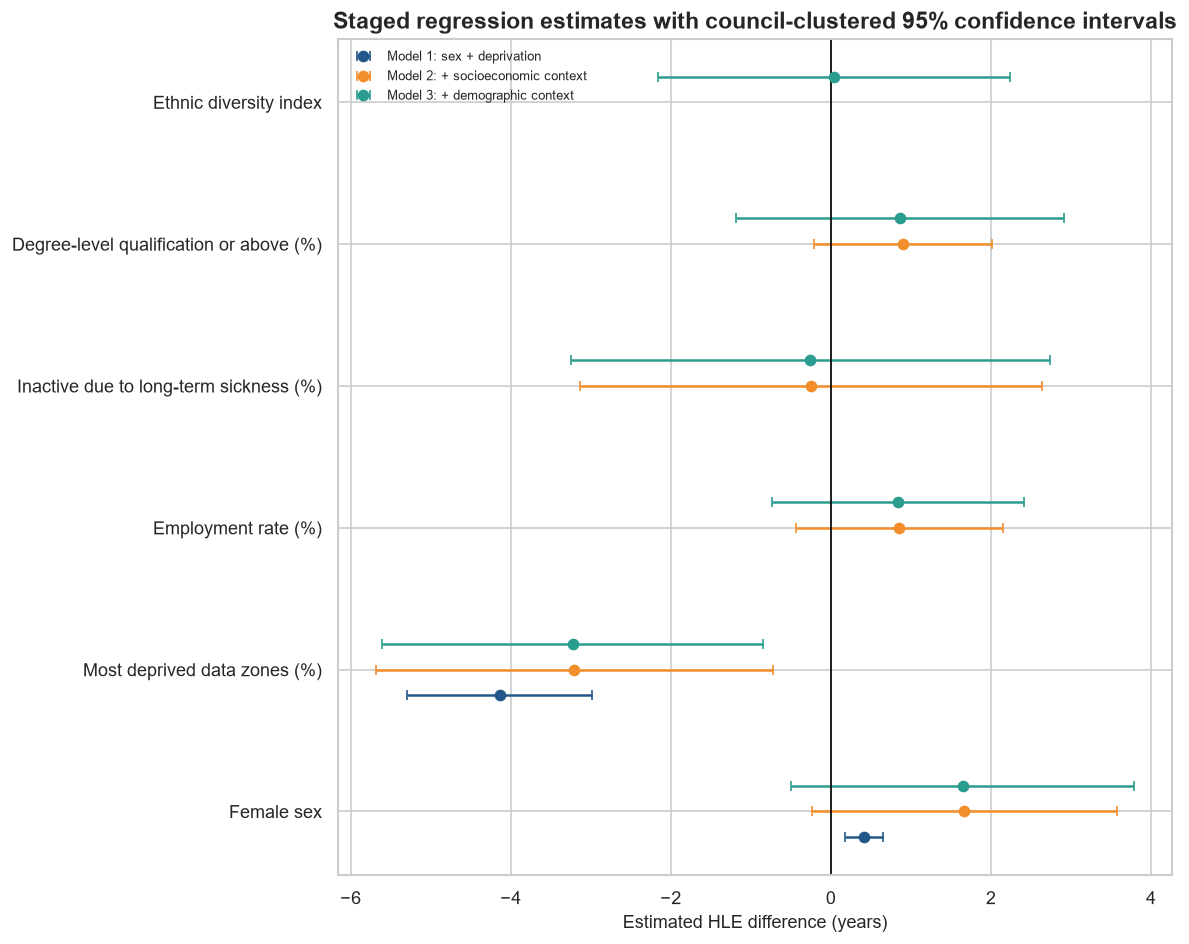

In [27]:
# Preparing the non-intercept coefficients from the three main staged models.
coefficient_plot = regression_coefficients.loc[
    regression_coefficients["model"].isin(["Model 1: sex + deprivation", "Model 2: + socioeconomic context", "Model 3: + demographic context"])
    & regression_coefficients["feature"].ne("Intercept")
].copy()

# Plotting the estimates and their council-clustered confidence intervals.
fig, ax = plt.subplots(figsize=(10, 8))
model_colours = {
    "Model 1: sex + deprivation": BLUE,
    "Model 2: + socioeconomic context": ORANGE,
    "Model 3: + demographic context": TEAL,
}
feature_order = list(dict.fromkeys(coefficient_plot["feature_label"]))
offsets = {"Model 1: sex + deprivation": -0.18, "Model 2: + socioeconomic context": 0, "Model 3: + demographic context": 0.18}
for model_name in model_colours:
    model_part = coefficient_plot.loc[coefficient_plot["model"].eq(model_name)]
    y_values = [feature_order.index(label) + offsets[model_name] for label in model_part["feature_label"]]
    ax.errorbar(
        model_part["estimate_years"], y_values,
        xerr=[model_part["estimate_years"] - model_part["ci_lower"], model_part["ci_upper"] - model_part["estimate_years"]],
        fmt="o", capsize=3, color=model_colours[model_name], label=model_name,
    )
# Adding the zero reference line, then saving and displaying the coefficient plot.
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(feature_order)
ax.set(title="Staged regression estimates with council-clustered 95% confidence intervals", xlabel="Estimated HLE difference (years)", ylabel="")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(figures_dir / "16_staged_regression_coefficient_forest.png", bbox_inches="tight")
plt.show()

### Residuals versus fitted values


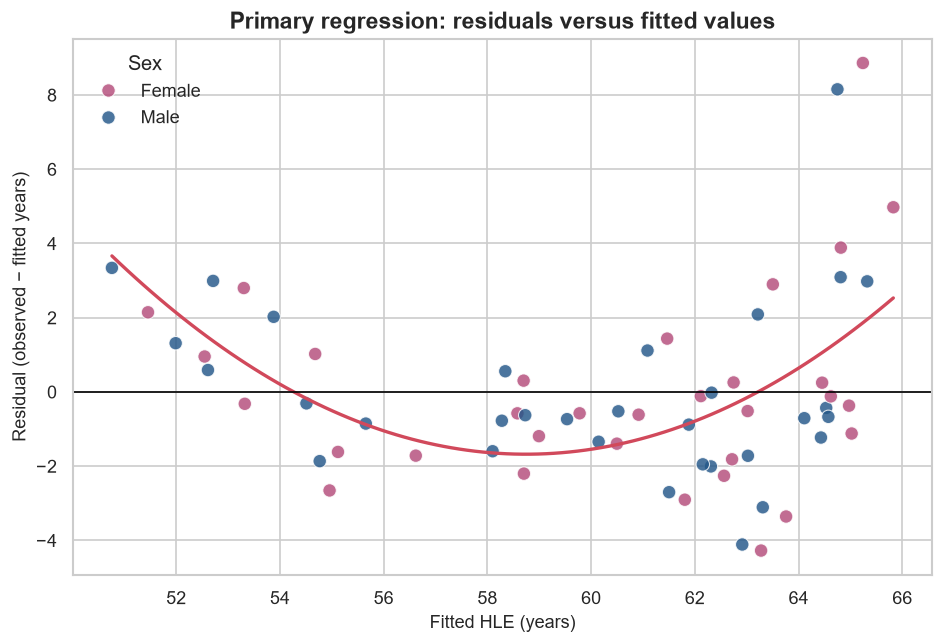

In [28]:
# Plotting the primary-model residuals against its fitted HLE values.
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(x=primary_fitted, y=primary_residuals, hue=at_birth["sex"], palette=SEX_COLOURS, s=65, alpha=0.82, ax=ax)
sns.regplot(x=primary_fitted, y=primary_residuals, scatter=False, order=2, ci=None, color=RED, line_kws={"lw": 2}, ax=ax)
# Adding the zero line, then labelling, saving and displaying the diagnostic plot.
ax.axhline(0, color="black", lw=1)
ax.set(title="Primary regression: residuals versus fitted values", xlabel="Fitted HLE (years)", ylabel="Residual (observed − fitted years)")
ax.legend(title="Sex")
fig.tight_layout()
fig.savefig(figures_dir / "17_regression_residuals_vs_fitted.png", bbox_inches="tight")
plt.show()

### Residual distribution


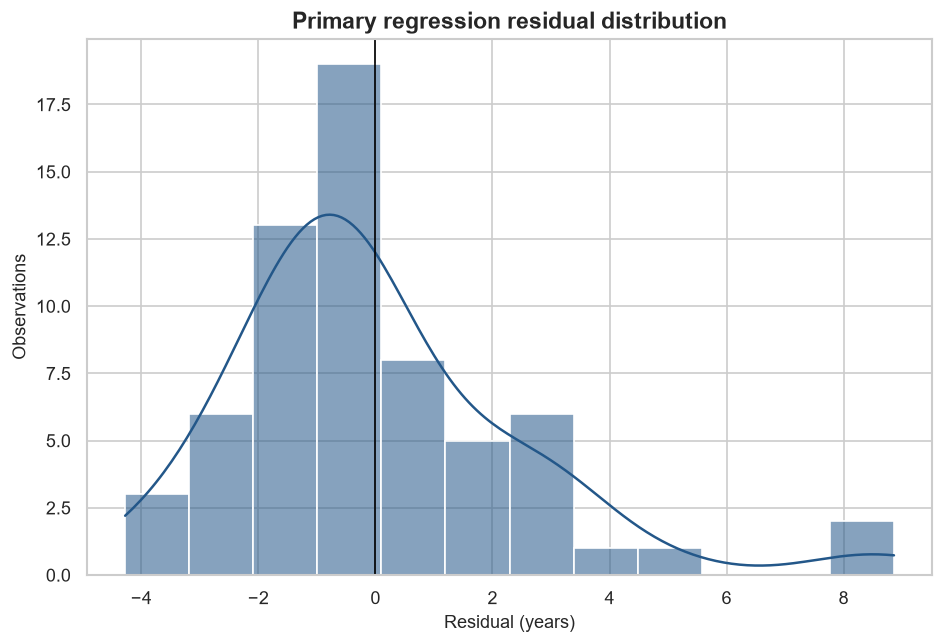

In [29]:
# Plotting the distribution of the primary regression residuals.
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.histplot(primary_residuals, bins=12, kde=True, color=BLUE, alpha=0.55, ax=ax)
# Marking zero, then labelling, saving and displaying the histogram.
ax.axvline(0, color="black", lw=1)
ax.set(title="Primary regression residual distribution", xlabel="Residual (years)", ylabel="Observations")
fig.tight_layout()
fig.savefig(figures_dir / "18_regression_residual_histogram.png", bbox_inches="tight")
plt.show()

### Normal Q-Q plot


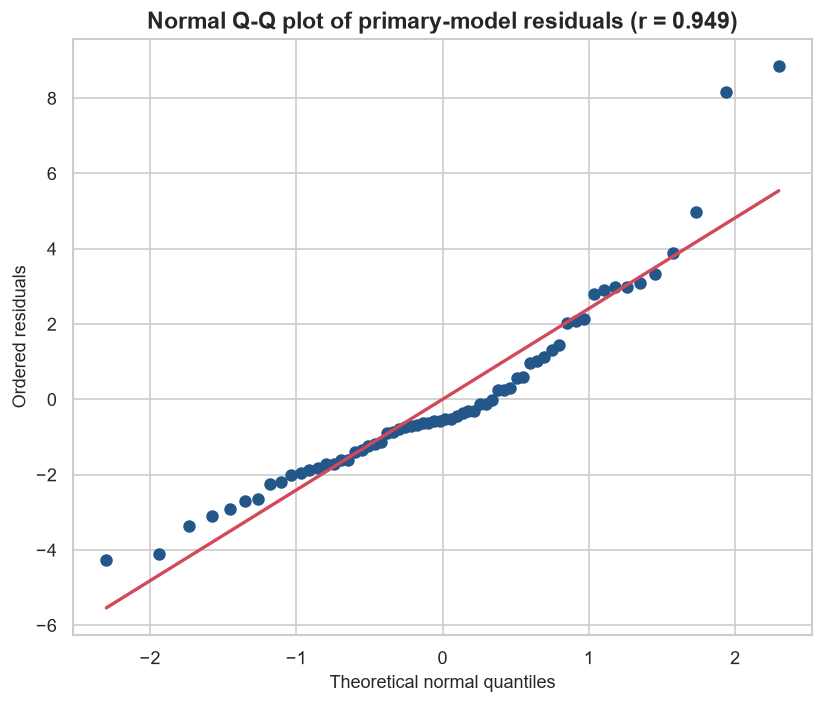

In [30]:
# Comparing the ordered residuals with the values expected under a normal distribution.
theoretical_quantiles, ordered_residuals = stats.probplot(primary_residuals, dist="norm", fit=False)
qq_slope, qq_intercept, qq_r = stats.probplot(primary_residuals, dist="norm", fit=True)[1]
# Drawing the Q-Q points and their fitted reference line.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(theoretical_quantiles, ordered_residuals, color=BLUE, s=42)
ax.plot(theoretical_quantiles, qq_intercept + qq_slope * np.asarray(theoretical_quantiles), color=RED, lw=2)
# Labelling, saving and displaying the Q-Q plot.
ax.set(title=f"Normal Q-Q plot of primary-model residuals (r = {qq_r:.3f})", xlabel="Theoretical normal quantiles", ylabel="Ordered residuals")
fig.tight_layout()
fig.savefig(figures_dir / "19_regression_qq_plot.png", bbox_inches="tight")
plt.show()

### Influence diagnostics

Cook's distance is shown at the observation level. The labels identify the five largest values for review; they are not automatically excluded.


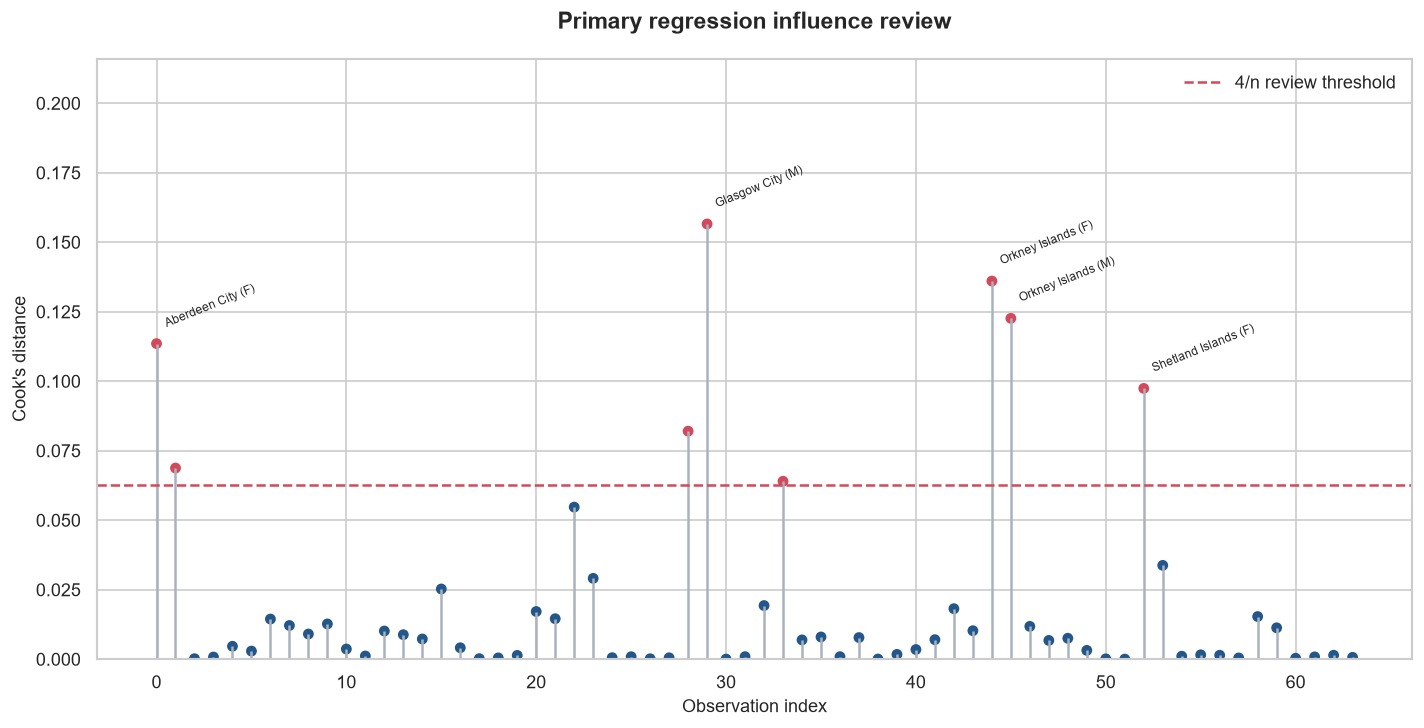

In [31]:
# Calculating leverage and Cook's distance for every primary-model observation.
hat_values = np.sum((primary_design_matrix @ primary_bread) * primary_design_matrix, axis=1)
primary_mse = np.sum(primary_residuals ** 2) / (len(primary_residuals) - primary_design_matrix.shape[1])
cooks_distance = (primary_residuals ** 2 / (primary_design_matrix.shape[1] * primary_mse)) * (
    hat_values / np.maximum((1 - hat_values) ** 2, 1e-12)
)
# Combining the influence measures with the council, sex, outcome and residual information.
diagnostic_table = at_birth[["council_area_code", "council_area", "sex", "healthy_life_expectancy_years"]].copy()
diagnostic_table["fitted_hle"] = primary_fitted
diagnostic_table["residual"] = primary_residuals
diagnostic_table["leverage"] = hat_values
diagnostic_table["cooks_distance"] = cooks_distance
diagnostic_table.to_csv(tables_dir / "15_regression_diagnostics.csv", index=False)

# Plotting Cook's distance and flagging observations above the usual review threshold.
fig, ax = plt.subplots(figsize=(12, 6.2))
positions = np.arange(len(diagnostic_table))
ax.stem(positions, diagnostic_table["cooks_distance"], linefmt="#AAB2BD", markerfmt=" ", basefmt=" ")
ax.scatter(
    positions,
    diagnostic_table["cooks_distance"],
    c=np.where(diagnostic_table["cooks_distance"] > 4 / len(diagnostic_table), RED, BLUE),
    s=30,
)
# Labelling the five observations with the largest Cook's distance.
for row_index in diagnostic_table["cooks_distance"].nlargest(5).index:
    row = diagnostic_table.loc[row_index]
    ax.annotate(
        f"{row['council_area']} ({row['sex'][0]})",
        (row_index, row["cooks_distance"]),
        xytext=(4, 10),
        textcoords="offset points",
        fontsize=7,
        rotation=22,
        ha="left",
    )
# Adding the review threshold, then saving and displaying the influence plot.
ax.axhline(4 / len(diagnostic_table), color=RED, ls="--", lw=1.5, label="4/n review threshold")
ax.set_ylim(0, diagnostic_table["cooks_distance"].max() * 1.38)
ax.set(
    title="Primary regression influence review",
    xlabel="Observation index",
    ylabel="Cook's distance",
)
ax.set_title("Primary regression influence review", pad=18)
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "20_regression_cooks_distance.png", bbox_inches="tight")
plt.show()

In [32]:
# Setting up the residual normality and unequal-variance diagnostic results.
diagnostic_tests = pd.DataFrame({
    "diagnostic": ["Shapiro-Wilk residual normality", "Breusch-Pagan-style auxiliary test"],
    "statistic": [stats.shapiro(primary_residuals).statistic, np.nan],
    "p_value": [stats.shapiro(primary_residuals).pvalue, np.nan],
    "interpretation": ["Small p suggests residual non-normality", "No strong evidence of unequal variance; council clustering accounts for within-council dependence."],
})

# Running the Breusch-Pagan-style auxiliary regression for unequal variance.
squared_residuals = primary_residuals ** 2
bp_model = LinearRegression().fit(primary_design_matrix[:, 1:], squared_residuals)
bp_r_squared = bp_model.score(primary_design_matrix[:, 1:], squared_residuals)
bp_statistic = len(squared_residuals) * bp_r_squared
bp_p_value = stats.chi2.sf(bp_statistic, df=primary_design_matrix.shape[1] - 1)
# Adding the test result, then saving and displaying both diagnostics.
diagnostic_tests.loc[1, "statistic"] = bp_statistic
diagnostic_tests.loc[1, "p_value"] = bp_p_value
diagnostic_tests.to_csv(tables_dir / "16_regression_diagnostic_tests.csv", index=False)
print(diagnostic_tests.round(4).to_string(index=False))

                        diagnostic  statistic  p_value                                                                                     interpretation
   Shapiro-Wilk residual normality     0.9066   0.0001                                                            Small p suggests residual non-normality
Breusch-Pagan-style auxiliary test     6.2823   0.3923 No strong evidence of unequal variance; council clustering accounts for within-council dependence.


## 5. Machine learning regression

The aim is to predict HLE at birth. The models include simple baselines, regularised linear models and nonlinear models. Preprocessing and tuning use only the training data, while validation holds out whole councils.

### Features and grouped validation design


In [33]:
# Preparing the eight predictors, continuous HLE outcome and council grouping field for machine learning.
ml_feature_labels = primary_feature_labels | {
    "economic_part_time_among_employed_pct": "Part-time among employed (%)",
    "economic_self_employed_among_employed_pct": "Self-employed among employed (%)",
}
ml_features = list(ml_feature_labels)

X_regression = at_birth[ml_features].copy()
y_regression = at_birth["healthy_life_expectancy_years"].copy()
regression_groups = at_birth["council_area_code"].copy()

# Creating eight council-grouped test folds so female and male rows from one council stay together.
outer_regression_cv = GroupKFold(n_splits=8)
regression_split_rows = []
# Auditing every fold to confirm that no council appears in both training and test data.
for fold_number, (train_indices, test_indices) in enumerate(outer_regression_cv.split(X_regression, y_regression, regression_groups), start=1):
    train_councils = set(regression_groups.iloc[train_indices])
    test_councils = set(regression_groups.iloc[test_indices])
    regression_split_rows.append({
        "fold": fold_number,
        "training_rows": len(train_indices),
        "test_rows": len(test_indices),
        "training_councils": len(train_councils),
        "test_councils": len(test_councils),
        "council_overlap": len(train_councils & test_councils),
    })
# Saving and displaying the grouped cross-validation audit.
regression_split_audit = pd.DataFrame(regression_split_rows)
regression_split_audit.to_csv(tables_dir / "17_grouped_cv_split_audit.csv", index=False)
print(regression_split_audit.to_string(index=False))

 fold  training_rows  test_rows  training_councils  test_councils  council_overlap
    1             56          8                 28              4                0
    2             56          8                 28              4                0
    3             56          8                 28              4                0
    4             56          8                 28              4                0
    5             56          8                 28              4                0
    6             56          8                 28              4                0
    7             56          8                 28              4                0
    8             56          8                 28              4                0


### Model definitions

The parameter grids are deliberately small. They test meaningful alternatives without turning a 64-row analysis into an uncontrolled search.


In [34]:
# Setting up the regression benchmark and seven candidate machine-learning models.
regression_models = {
    "Dummy mean": Pipeline([("scale", StandardScaler()), ("model", DummyRegressor(strategy="mean"))]),
    "Linear regression": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
    "Elastic Net": Pipeline([("scale", StandardScaler()), ("model", ElasticNet(max_iter=20000, random_state=RANDOM_SEED))]),
    "Random Forest": Pipeline([("scale", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=1))]),
    "Gradient Boosting": Pipeline([("scale", StandardScaler()), ("model", GradientBoostingRegressor(random_state=RANDOM_SEED))]),
    "Support Vector Regression": Pipeline([("scale", StandardScaler()), ("model", SVR())]),
    "k-Nearest Neighbours": Pipeline([("scale", StandardScaler()), ("model", KNeighborsRegressor())]),
}

# Defining the small parameter grids used to tune each model inside the training data.
regression_parameter_grids = {
    "Dummy mean": {},
    "Linear regression": {},
    "Ridge": {"model__alpha": [0.1, 1, 10, 100]},
    "Elastic Net": {"model__alpha": [0.01, 0.1, 1], "model__l1_ratio": [0.1, 0.5, 0.9]},
    "Random Forest": {"model__max_depth": [2, None], "model__min_samples_leaf": [1, 3], "model__max_features": [0.7]},
    "Gradient Boosting": {"model__n_estimators": [50, 100], "model__learning_rate": [0.05, 0.1], "model__max_depth": [1, 2], "model__min_samples_leaf": [2]},
    "Support Vector Regression": {"model__C": [1, 10, 100], "model__epsilon": [0.1, 0.5]},
    "k-Nearest Neighbours": {"model__n_neighbors": [3, 5, 7], "model__weights": ["uniform", "distance"]},
}
# Displaying the practical purpose of each regression model.
print(pd.DataFrame({"model": regression_models.keys(), "purpose": ["Naive benchmark", "Unregularised linear benchmark", "Stable regularised linear model", "Sparse/regularised linear model", "Nonlinear ensemble", "Sequential nonlinear ensemble", "Kernel-based nonlinear model", "Local similarity model"]}).to_string(index=False))

                    model                         purpose
               Dummy mean                 Naive benchmark
        Linear regression  Unregularised linear benchmark
                    Ridge Stable regularised linear model
              Elastic Net Sparse/regularised linear model
            Random Forest              Nonlinear ensemble
        Gradient Boosting   Sequential nonlinear ensemble
Support Vector Regression    Kernel-based nonlinear model
     k-Nearest Neighbours          Local similarity model


### Nested council-grouped cross-validation

This is the main fitting cell. It intentionally prints nothing because the results are displayed in the next cell.


In [35]:
# Creating empty lists for the out-of-fold predictions and fold-level regression results.
regression_oof_rows = []
regression_fold_rows = []

# Evaluating every regression model across the eight outer council-grouped folds.
for model_name, model_pipeline in regression_models.items():
    for fold_number, (train_indices, test_indices) in enumerate(outer_regression_cv.split(X_regression, y_regression, regression_groups), start=1):
        # Separating the training and untouched test councils for this fold.
        X_train = X_regression.iloc[train_indices]
        X_test = X_regression.iloc[test_indices]
        y_train = y_regression.iloc[train_indices]
        y_test = y_regression.iloc[test_indices]
        groups_train = regression_groups.iloc[train_indices]

        # Tuning the model only within the training councils using four inner grouped folds.
        inner_cv = GroupKFold(n_splits=4)
        model_search = GridSearchCV(
            estimator=clone(model_pipeline),
            param_grid=regression_parameter_grids[model_name],
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        )
        model_search.fit(X_train, y_train, groups=groups_train)
        fold_predictions = model_search.predict(X_test)

        # Calculating and storing the prediction error for this test fold.
        fold_mae = mean_absolute_error(y_test, fold_predictions)
        fold_rmse = np.sqrt(mean_squared_error(y_test, fold_predictions))
        regression_fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "mae_years": fold_mae,
            "rmse_years": fold_rmse,
            "best_parameters": str(model_search.best_params_),
        })

        # Keeping one out-of-fold prediction for every held-out council-sex observation.
        for row_position, prediction in zip(test_indices, fold_predictions):
            regression_oof_rows.append({
                "model": model_name,
                "row_index": int(row_position),
                "council_area_code": at_birth.iloc[row_position]["council_area_code"],
                "council_area": at_birth.iloc[row_position]["council_area"],
                "sex": at_birth.iloc[row_position]["sex"],
                "deprivation_quartile": at_birth.iloc[row_position]["deprivation_quartile"],
                "observed_hle": y_regression.iloc[row_position],
                "predicted_hle": prediction,
                "residual": y_regression.iloc[row_position] - prediction,
                "fold": fold_number,
            })

# Combining and saving the fold results and all out-of-fold predictions.
regression_fold_metrics = pd.DataFrame(regression_fold_rows)
regression_oof_predictions = pd.DataFrame(regression_oof_rows).sort_values(["model", "row_index"])
regression_fold_metrics.to_csv(tables_dir / "18_regression_fold_metrics.csv", index=False)
regression_oof_predictions.to_csv(tables_dir / "19_regression_oof_predictions.csv", index=False)

### Regression model comparison


In [36]:
# Comparing the regression models using their combined out-of-fold predictions.
regression_comparison_rows = []
for model_name in regression_models:
    model_predictions = regression_oof_predictions.loc[regression_oof_predictions["model"].eq(model_name)].sort_values("row_index")
    observed = model_predictions["observed_hle"].to_numpy()
    predicted = model_predictions["predicted_hle"].to_numpy()

    # Resampling whole councils to estimate uncertainty around MAE and RMSE.
    bootstrap_mae = []
    bootstrap_rmse = []
    unique_councils = model_predictions["council_area_code"].unique()
    model_group_indices = model_predictions.groupby("council_area_code").indices
    for _ in range(3000):
        sampled_councils = rng.choice(unique_councils, size=len(unique_councils), replace=True)
        sampled_indices = np.concatenate([model_group_indices[code] for code in sampled_councils])
        sampled_rows = model_predictions.iloc[sampled_indices]
        bootstrap_mae.append(mean_absolute_error(sampled_rows["observed_hle"], sampled_rows["predicted_hle"]))
        bootstrap_rmse.append(np.sqrt(mean_squared_error(sampled_rows["observed_hle"], sampled_rows["predicted_hle"])))

    # Storing the overall error, confidence intervals and out-of-fold R-squared for this model.
    regression_comparison_rows.append({
        "model": model_name,
        "mae_years": mean_absolute_error(observed, predicted),
        "mae_ci_lower": np.percentile(bootstrap_mae, 2.5),
        "mae_ci_upper": np.percentile(bootstrap_mae, 97.5),
        "rmse_years": np.sqrt(mean_squared_error(observed, predicted)),
        "rmse_ci_lower": np.percentile(bootstrap_rmse, 2.5),
        "rmse_ci_upper": np.percentile(bootstrap_rmse, 97.5),
        "oof_r_squared": r2_score(observed, predicted),
    })

# Ranking, saving and displaying the regression models by MAE.
regression_model_comparison = pd.DataFrame(regression_comparison_rows).sort_values("mae_years")
regression_model_comparison.to_csv(tables_dir / "20_regression_model_comparison.csv", index=False)
print(regression_model_comparison.round(3).to_string(index=False))

                    model  mae_years  mae_ci_lower  mae_ci_upper  rmse_years  rmse_ci_lower  rmse_ci_upper  oof_r_squared
            Random Forest      1.855         1.321         2.487       2.619          1.690          3.563          0.717
                    Ridge      1.895         1.335         2.588       2.677          1.763          3.624          0.704
        Gradient Boosting      1.919         1.286         2.687       2.857          1.735          3.851          0.663
     k-Nearest Neighbours      1.993         1.316         2.832       2.986          1.868          4.108          0.632
              Elastic Net      2.015         1.468         2.697       2.691          1.829          3.611          0.701
        Linear regression      2.161         1.645         2.757       2.779          2.076          3.478          0.682
Support Vector Regression      2.269         1.550         3.101       3.201          2.144          4.215          0.578
               Dummy mea

### Regression performance plot


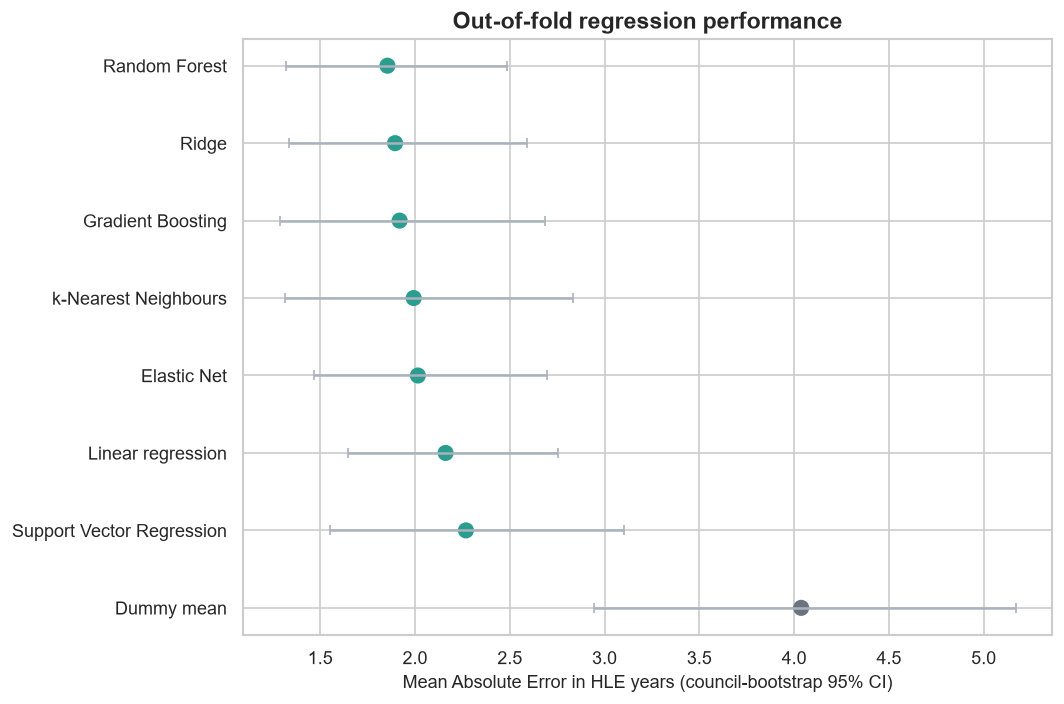

In [37]:
# Ordering the regression models by MAE for a clear performance comparison.
regression_plot = regression_model_comparison.sort_values("mae_years", ascending=False)
# Plotting each model's out-of-fold MAE and council-bootstrap confidence interval.
fig, ax = plt.subplots(figsize=(9, 6))
y_positions = np.arange(len(regression_plot))
colours = [GREY if model == "Dummy mean" else TEAL for model in regression_plot["model"]]
ax.errorbar(
    regression_plot["mae_years"], y_positions,
    xerr=[regression_plot["mae_years"] - regression_plot["mae_ci_lower"], regression_plot["mae_ci_upper"] - regression_plot["mae_years"]],
    fmt="none", ecolor="#AAB2BD", capsize=3,
)
ax.scatter(regression_plot["mae_years"], y_positions, c=colours, s=75)
# Adding the labels, then saving and displaying the comparison plot.
ax.set_yticks(y_positions)
ax.set_yticklabels(regression_plot["model"])
ax.set(title="Out-of-fold regression performance", xlabel="Mean Absolute Error in HLE years (council-bootstrap 95% CI)", ylabel="")
fig.tight_layout()
fig.savefig(figures_dir / "21_regression_model_comparison.png", bbox_inches="tight")
plt.show()

### Observed versus predicted HLE


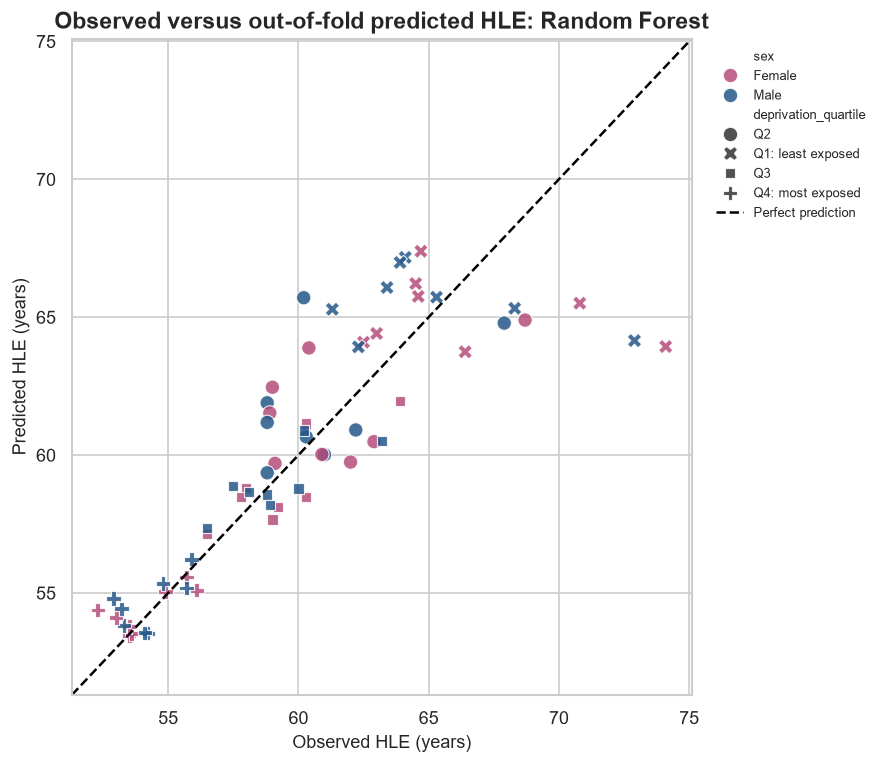

In [38]:
# Selecting the best non-dummy regression model and its out-of-fold predictions.
best_regression_model_name = regression_model_comparison.loc[
    ~regression_model_comparison["model"].eq("Dummy mean")
].iloc[0]["model"]
best_regression_predictions = regression_oof_predictions.loc[
    regression_oof_predictions["model"].eq(best_regression_model_name)
].copy()

# Comparing its observed and predicted HLE values across sex and deprivation groups.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.scatterplot(data=best_regression_predictions, x="observed_hle", y="predicted_hle", hue="sex", style="deprivation_quartile", palette=SEX_COLOURS, s=75, alpha=0.85, ax=ax)
# Adding the perfect-prediction line and using the same scale on both axes.
axis_min = min(best_regression_predictions["observed_hle"].min(), best_regression_predictions["predicted_hle"].min()) - 1
axis_max = max(best_regression_predictions["observed_hle"].max(), best_regression_predictions["predicted_hle"].max()) + 1
ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", ls="--", lw=1.5, label="Perfect prediction")
ax.set(xlim=(axis_min, axis_max), ylim=(axis_min, axis_max), title=f"Observed versus out-of-fold predicted HLE: {best_regression_model_name}", xlabel="Observed HLE (years)", ylabel="Predicted HLE (years)")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / "22_regression_observed_vs_predicted.png", bbox_inches="tight")
plt.show()

### Prediction error across deprivation quartiles


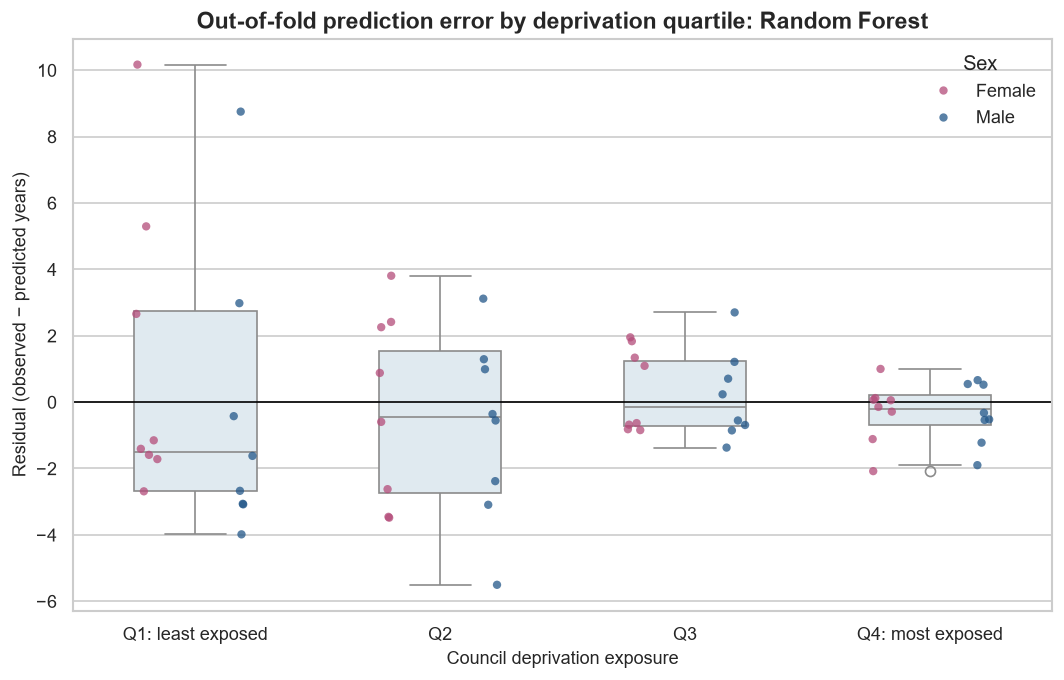

In [39]:
# Comparing the best model's prediction errors across deprivation groups and sex.
fig, ax = plt.subplots(figsize=(9, 5.8))
sns.boxplot(data=best_regression_predictions, x="deprivation_quartile", y="residual", order=quartile_order, color="#DDEBF3", width=0.5, ax=ax)
sns.stripplot(data=best_regression_predictions, x="deprivation_quartile", y="residual", order=quartile_order, hue="sex", palette=SEX_COLOURS, dodge=True, alpha=0.75, size=5, ax=ax)
# Marking zero error, then labelling, saving and displaying the plot.
ax.axhline(0, color="black", lw=1)
ax.set(title=f"Out-of-fold prediction error by deprivation quartile: {best_regression_model_name}", xlabel="Council deprivation exposure", ylabel="Residual (observed − predicted years)")
ax.legend(title="Sex", loc="best")
fig.tight_layout()
fig.savefig(figures_dir / "23_regression_error_by_deprivation.png", bbox_inches="tight")
plt.show()

### Subgroup error check


In [40]:
# Calculating absolute and squared prediction errors for the best regression model.
best_regression_predictions["absolute_error"] = best_regression_predictions["residual"].abs()
best_regression_predictions["squared_error"] = best_regression_predictions["residual"] ** 2
# Summarising MAE, average error and RMSE within each sex and deprivation group.
regression_subgroup_error = best_regression_predictions.groupby(["sex", "deprivation_quartile"], observed=True).agg(
    n=("residual", "size"),
    mae_years=("absolute_error", "mean"),
    mean_error_years=("residual", "mean"),
    mean_squared_error=("squared_error", "mean"),
).reset_index()
regression_subgroup_error["rmse_years"] = np.sqrt(regression_subgroup_error["mean_squared_error"])
regression_subgroup_error = regression_subgroup_error.drop(columns="mean_squared_error")
# Saving and displaying the subgroup error table.
regression_subgroup_error.to_csv(tables_dir / "21_regression_subgroup_error.csv", index=False)
print(regression_subgroup_error.round(3).to_string(index=False))

   sex deprivation_quartile  n  mae_years  mean_error_years  rmse_years
Female    Q1: least exposed  8      3.334             1.195       4.394
Female                   Q2  8      2.440            -0.101       2.681
Female                   Q3  8      1.149             0.405       1.245
Female     Q4: most exposed  8      0.609            -0.298       0.915
  Male    Q1: least exposed  8      3.323            -0.390       4.034
  Male                   Q2  8      2.162            -0.813       2.701
  Male                   Q3  8      1.040             0.173       1.260
  Male     Q4: most exposed  8      0.780            -0.348       0.921


## 6. Low, Middle and High HLE classification

HLE is grouped into Low, Middle and High using tertiles from the 64 at-birth observations. These are sample-based groups, not official thresholds. Councils are kept together during validation.

In [41]:
# Preparing the predictors, three-class HLE outcome and council groups for classification.
X_classification = at_birth[ml_features].copy()
y_classification = at_birth["hle_category_code"].copy()
classification_groups = at_birth["council_area_code"].copy()
classification_class_codes = [0, 1, 2]

# Counting the Low, Middle and High observations and recording their HLE boundaries.
class_balance_rows = []
for class_code, class_label in zip(classification_class_codes, hle_category_labels):
    class_rows = at_birth.loc[at_birth["hle_category_code"].eq(class_code)]
    class_balance_rows.append({
        "class_code": class_code,
        "hle_category": class_label,
        "rows": len(class_rows),
        "female_rows": class_rows["sex"].eq("Female").sum(),
        "male_rows": class_rows["sex"].eq("Male").sum(),
        "represented_councils": class_rows["council_area_code"].nunique(),
        "lower_boundary_years": -np.inf if class_code == 0 else (hle_low_threshold if class_code == 1 else hle_high_threshold),
        "upper_boundary_years": hle_low_threshold if class_code == 0 else (hle_high_threshold if class_code == 1 else np.inf),
    })

# Saving and displaying the class-balance table.
class_balance = pd.DataFrame(class_balance_rows)
class_balance.to_csv(tables_dir / "22_class_balance.csv", index=False)
print(class_balance.to_string(index=False))

 class_code hle_category  rows  female_rows  male_rows  represented_councils  lower_boundary_years  upper_boundary_years
          0      Low HLE    22           11         11                    11                  -inf                  58.1
          1   Middle HLE    21           10         11                    11                  58.1                  62.0
          2     High HLE    21           11         10                    11                  62.0                   inf


### Classification model definitions


In [42]:
# Setting up the classification benchmark and five candidate three-class models.
classification_models = {
    "Dummy most frequent": Pipeline([("scale", StandardScaler()), ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED))]),
    "Multinomial Logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_SEED))]),
    "Random Forest": Pipeline([("scale", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=1))]),
    "Gradient Boosting": Pipeline([("scale", StandardScaler()), ("model", GradientBoostingClassifier(random_state=RANDOM_SEED))]),
    "Support Vector Machine": Pipeline([("scale", StandardScaler()), ("model", SVC(probability=True, class_weight="balanced", random_state=RANDOM_SEED))]),
    "k-Nearest Neighbours": Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier())]),
}

# Defining the parameter grids used to tune each classifier inside the training data.
classification_parameter_grids = {
    "Dummy most frequent": {},
    "Multinomial Logistic": {"model__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest": {"model__max_depth": [2, None], "model__min_samples_leaf": [1, 3], "model__max_features": [0.7]},
    "Gradient Boosting": {"model__n_estimators": [50, 100], "model__learning_rate": [0.05, 0.1], "model__max_depth": [1, 2], "model__min_samples_leaf": [2]},
    "Support Vector Machine": {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.1]},
    "k-Nearest Neighbours": {"model__n_neighbors": [3, 5, 7], "model__weights": ["uniform", "distance"]},
}



### Nested stratified, council-grouped cross-validation


In [43]:
# Creating stratified council-grouped folds and empty lists for the classification results.
outer_classification_cv = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=RANDOM_SEED)
classification_oof_rows = []
classification_fold_rows = []

# Evaluating every classifier while keeping both sex rows from a council together.
for model_name, model_pipeline in classification_models.items():
    for fold_number, (train_indices, test_indices) in enumerate(
        outer_classification_cv.split(X_classification, y_classification, classification_groups),
        start=1,
    ):
        # Separating the training and untouched test councils for this fold.
        X_train = X_classification.iloc[train_indices]
        X_test = X_classification.iloc[test_indices]
        y_train = y_classification.iloc[train_indices]
        y_test = y_classification.iloc[test_indices]
        groups_train = classification_groups.iloc[train_indices]

        # Tuning the classifier only within the training councils using four inner grouped folds.
        inner_classifier_cv = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=RANDOM_SEED + fold_number,
        )
        model_search = GridSearchCV(
            estimator=clone(model_pipeline),
            param_grid=classification_parameter_grids[model_name],
            scoring="balanced_accuracy",
            cv=inner_classifier_cv,
            n_jobs=-1,
            refit=True,
        )
        model_search.fit(X_train, y_train, groups=groups_train)
        # Predicting the HLE group and align each model's probabilities to the same Low, Middle and High order.
        predicted_class = model_search.predict(X_test).astype(int)
        raw_probabilities = model_search.predict_proba(X_test)
        fitted_class_codes = model_search.best_estimator_.named_steps["model"].classes_.astype(int)
        predicted_probabilities = np.zeros((len(test_indices), len(classification_class_codes)))
        for probability_position, fitted_class_code in enumerate(fitted_class_codes):
            predicted_probabilities[:, fitted_class_code] = raw_probabilities[:, probability_position]

        # Storing the balanced accuracy, macro-F1 and weighted kappa for this test fold.
        classification_fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "balanced_accuracy": balanced_accuracy_score(y_test, predicted_class),
            "macro_f1": f1_score(y_test, predicted_class, average="macro", zero_division=0),
            "weighted_kappa": cohen_kappa_score(y_test, predicted_class, weights="quadratic"),
            "best_parameters": str(model_search.best_params_),
        })

        # Keeping the predicted group and probabilities for every held-out observation.
        for local_position, row_position in enumerate(test_indices):
            classification_oof_rows.append({
                "model": model_name,
                "row_index": int(row_position),
                "council_area_code": at_birth.iloc[row_position]["council_area_code"],
                "council_area": at_birth.iloc[row_position]["council_area"],
                "sex": at_birth.iloc[row_position]["sex"],
                "observed_class_code": int(y_classification.iloc[row_position]),
                "observed_category": hle_category_labels[int(y_classification.iloc[row_position])],
                "predicted_class_code": int(predicted_class[local_position]),
                "predicted_category": hle_category_labels[int(predicted_class[local_position])],
                "probability_low_hle": predicted_probabilities[local_position, 0],
                "probability_middle_hle": predicted_probabilities[local_position, 1],
                "probability_high_hle": predicted_probabilities[local_position, 2],
                "fold": fold_number,
            })

# Combining and saving the fold results and all out-of-fold class predictions.
classification_fold_metrics = pd.DataFrame(classification_fold_rows)
classification_oof_predictions = pd.DataFrame(classification_oof_rows).sort_values(["model", "row_index"])
classification_fold_metrics.to_csv(tables_dir / "23_classification_fold_metrics.csv", index=False)
classification_oof_predictions.to_csv(tables_dir / "24_classification_oof_predictions.csv", index=False)

### Classification model comparison


In [44]:
# Comparing the classifiers using their combined out-of-fold predictions and probabilities.
classification_comparison_rows = []
probability_columns = ["probability_low_hle", "probability_middle_hle", "probability_high_hle"]

for model_name in classification_models:
    model_predictions = classification_oof_predictions.loc[
        classification_oof_predictions["model"].eq(model_name)
    ].sort_values("row_index")
    observed = model_predictions["observed_class_code"].to_numpy()
    predicted = model_predictions["predicted_class_code"].to_numpy()
    probabilities = model_predictions[probability_columns].to_numpy()
    observed_binary = label_binarize(observed, classes=classification_class_codes)

    # Resampling whole councils to estimate uncertainty around balanced accuracy.
    bootstrap_balanced_accuracy = []
    unique_councils = model_predictions["council_area_code"].unique()
    model_group_indices = model_predictions.groupby("council_area_code").indices

    for _ in range(3000):
        sampled_councils = rng.choice(
            unique_councils,
            size=len(unique_councils),
            replace=True,
        )
        sampled_indices = np.concatenate(
            [model_group_indices[code] for code in sampled_councils]
        )
        sampled_rows = model_predictions.iloc[sampled_indices]

        bootstrap_balanced_accuracy.append(
            balanced_accuracy_score(
                sampled_rows["observed_class_code"],
                sampled_rows["predicted_class_code"],
            )
        )

    # Storing the full set of classification metrics for this model.
    classification_comparison_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(observed, predicted),
        "balanced_accuracy": balanced_accuracy_score(observed, predicted),
        "balanced_accuracy_ci_lower": np.percentile(
            bootstrap_balanced_accuracy, 2.5
        ),
        "balanced_accuracy_ci_upper": np.percentile(
            bootstrap_balanced_accuracy, 97.5
        ),
        "macro_precision": precision_score(
            observed, predicted, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            observed, predicted, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            observed, predicted, average="macro", zero_division=0
        ),
        "weighted_kappa": cohen_kappa_score(
            observed, predicted, weights="quadratic"
        ),
        "extreme_error_rate": np.mean(
            np.abs(observed - predicted) == 2
        ),
        "roc_auc_ovr_macro": roc_auc_score(
            observed,
            probabilities,
            labels=classification_class_codes,
            multi_class="ovr",
            average="macro",
        ),
        "average_precision_macro": average_precision_score(
            observed_binary,
            probabilities,
            average="macro",
        ),
    })

# Ranking, saving and displaying the classifiers by balanced accuracy and macro-F1.
classification_model_comparison = pd.DataFrame(
    classification_comparison_rows
).sort_values(
    ["balanced_accuracy", "macro_f1"],
    ascending=False,
)

classification_model_comparison.to_csv(
    tables_dir / "25_classification_model_comparison.csv",
    index=False,
)

print(classification_model_comparison.round(3).to_string(index=False))

                 model  accuracy  balanced_accuracy  balanced_accuracy_ci_lower  balanced_accuracy_ci_upper  macro_precision  macro_recall  macro_f1  weighted_kappa  extreme_error_rate  roc_auc_ovr_macro  average_precision_macro
         Random Forest     0.828              0.827                       0.696                       0.949            0.829         0.827     0.828           0.870               0.000              0.879                    0.732
     Gradient Boosting     0.828              0.827                       0.688                       0.946            0.829         0.827     0.828           0.870               0.000              0.859                    0.762
  Multinomial Logistic     0.750              0.748                       0.589                       0.881            0.748         0.748     0.746           0.818               0.000              0.883                    0.760
  k-Nearest Neighbours     0.688              0.685                       0.545     

### Classification performance plot


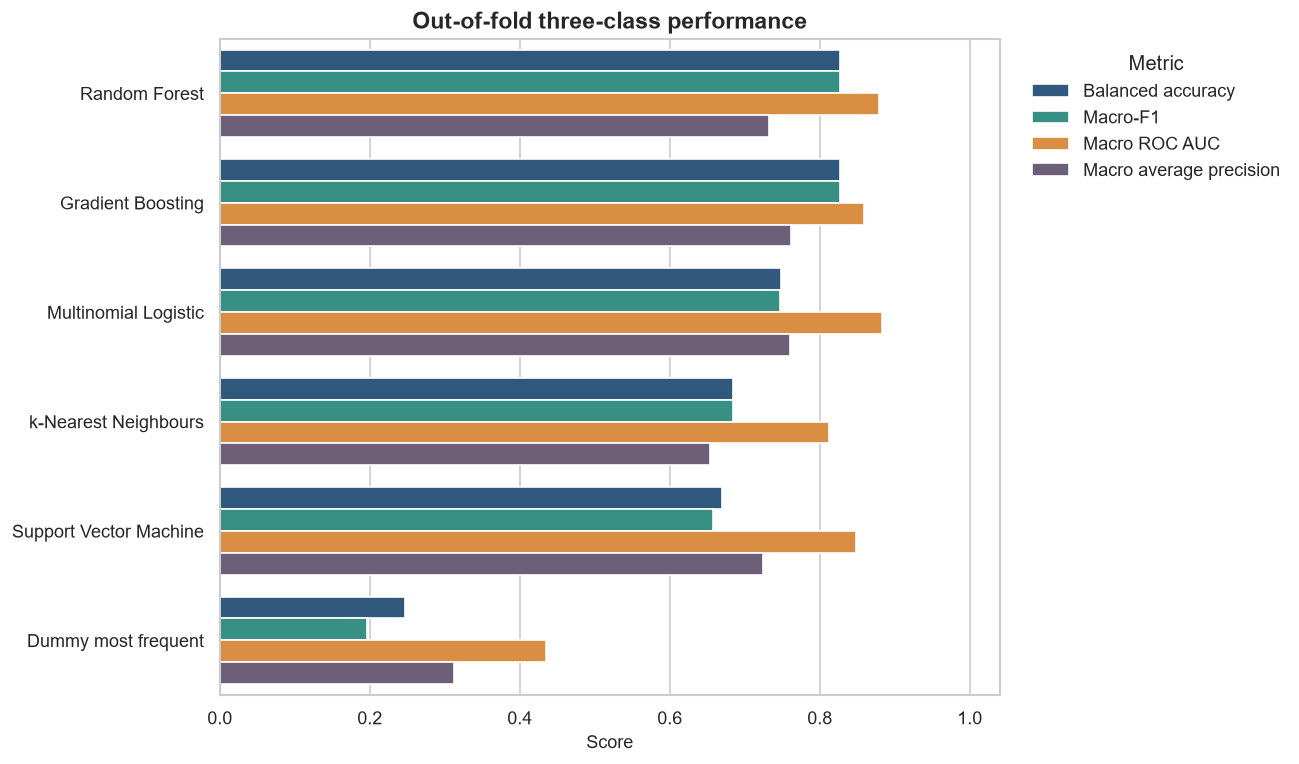

In [45]:
# Reshaping the main classification scores into a format suitable for one comparison chart.
classification_long = classification_model_comparison.melt(
    id_vars="model",
    value_vars=["balanced_accuracy", "macro_f1", "roc_auc_ovr_macro", "average_precision_macro"],
    var_name="metric",
    value_name="score",
)
# Replacing technical field names with readable metric labels.
metric_labels = {
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro-F1",
    "roc_auc_ovr_macro": "Macro ROC AUC",
    "average_precision_macro": "Macro average precision",
}
classification_long["metric"] = classification_long["metric"].map(metric_labels)

# Plotting the out-of-fold scores for every three-class model.
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=classification_long,
    x="score",
    y="model",
    hue="metric",
    palette=[BLUE, TEAL, ORANGE, PURPLE],
    ax=ax,
)
# Setting the common score scale, then saving and displaying the chart.
ax.set(xlim=(0, 1.04), title="Out-of-fold three-class performance", xlabel="Score", ylabel="")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / "24_classification_model_comparison.png", bbox_inches="tight")
plt.show()

### Confusion matrix for the strongest non-dummy classifier


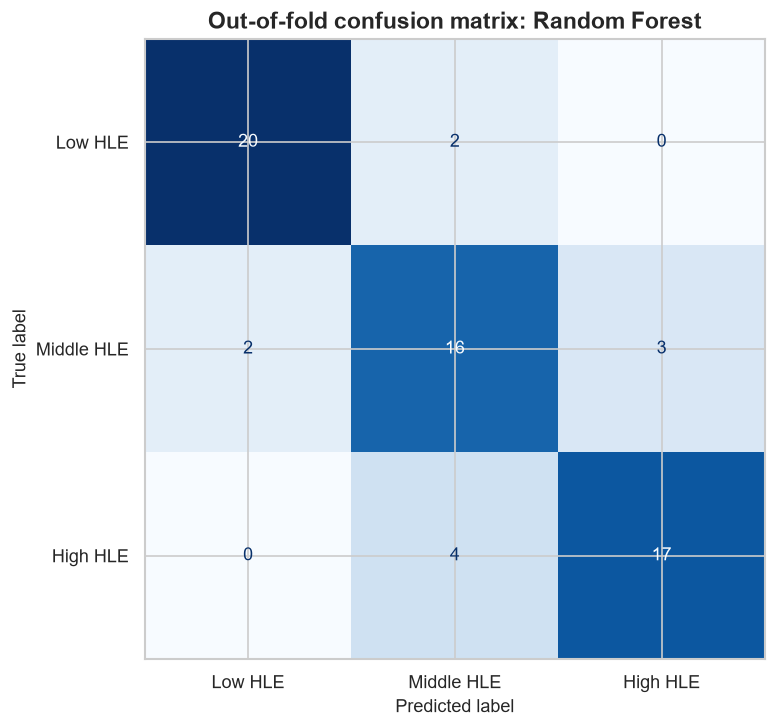

In [46]:
# Selecting the best non-dummy classifier and its out-of-fold predictions.
best_classifier_name = classification_model_comparison.loc[
    ~classification_model_comparison["model"].eq("Dummy most frequent")
].iloc[0]["model"]
best_classifier_predictions = classification_oof_predictions.loc[
    classification_oof_predictions["model"].eq(best_classifier_name)
].sort_values("row_index")

# Counting how often each observed HLE group was predicted as Low, Middle or High.
best_confusion_matrix = confusion_matrix(
    best_classifier_predictions["observed_class_code"],
    best_classifier_predictions["predicted_class_code"],
    labels=classification_class_codes,
)
# Saving the confusion-matrix counts as a results table.
confusion_matrix_table = pd.DataFrame(
    best_confusion_matrix,
    index=[f"Observed {label}" for label in hle_category_labels],
    columns=[f"Predicted {label}" for label in hle_category_labels],
)
confusion_matrix_table.to_csv(tables_dir / "26_classification_confusion_matrix.csv")

# Displaying, saving and showing the three-class confusion matrix.
fig, ax = plt.subplots(figsize=(7.2, 6.2))
ConfusionMatrixDisplay(
    best_confusion_matrix,
    display_labels=hle_category_labels,
).plot(cmap="Blues", values_format="d", colorbar=False, ax=ax)
ax.set_title(f"Out-of-fold confusion matrix: {best_classifier_name}")
fig.tight_layout()
fig.savefig(figures_dir / "25_classification_confusion_matrix.png", bbox_inches="tight")
plt.show()

### ROC curves


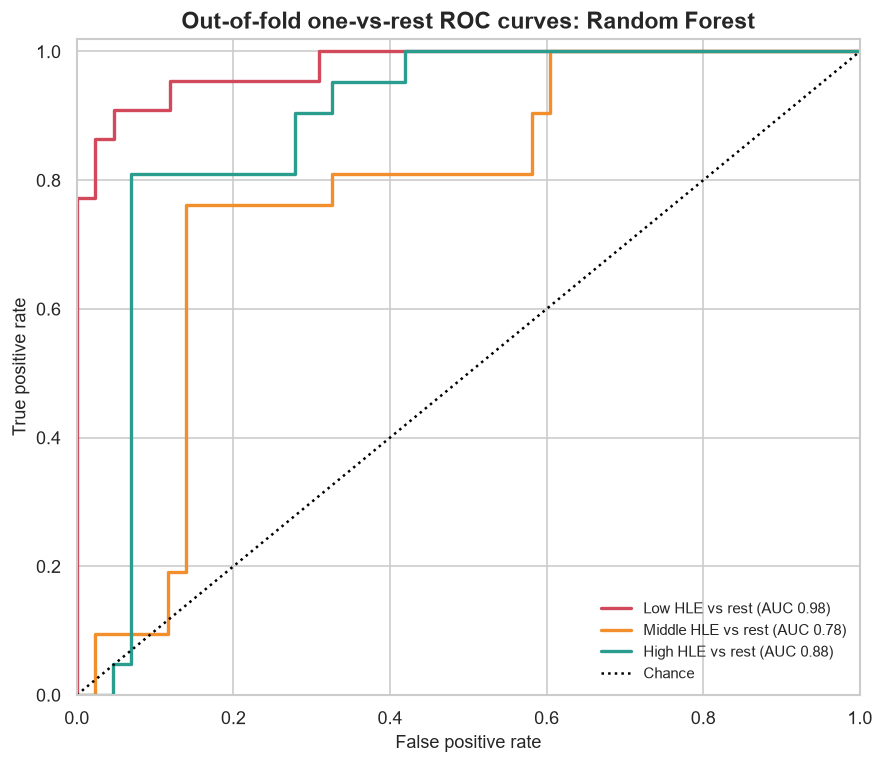

In [47]:
# Preparing the observed labels and predicted probabilities for one-versus-rest ROC analysis.
best_observed = best_classifier_predictions["observed_class_code"].to_numpy()
best_probabilities = best_classifier_predictions[probability_columns].to_numpy()
best_observed_binary = label_binarize(best_observed, classes=classification_class_codes)
classification_colours = [RED, ORANGE, TEAL]

# Plotting a separate ROC curve for each HLE group.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for class_position, class_label in enumerate(hle_category_labels):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        best_observed_binary[:, class_position],
        best_probabilities[:, class_position],
    )
    class_auc = roc_auc_score(best_observed_binary[:, class_position], best_probabilities[:, class_position])
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        lw=2,
        color=classification_colours[class_position],
        label=f"{class_label} vs rest (AUC {class_auc:.2f})",
    )
# Adding the chance reference line, then saving and displaying the ROC figure.
ax.plot([0, 1], [0, 1], color="black", ls=":", label="Chance")
ax.set(
    title=f"Out-of-fold one-vs-rest ROC curves: {best_classifier_name}",
    xlabel="False positive rate",
    ylabel="True positive rate",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(figures_dir / "26_classification_roc_curves.png", bbox_inches="tight")
plt.show()

### Precision-recall curves


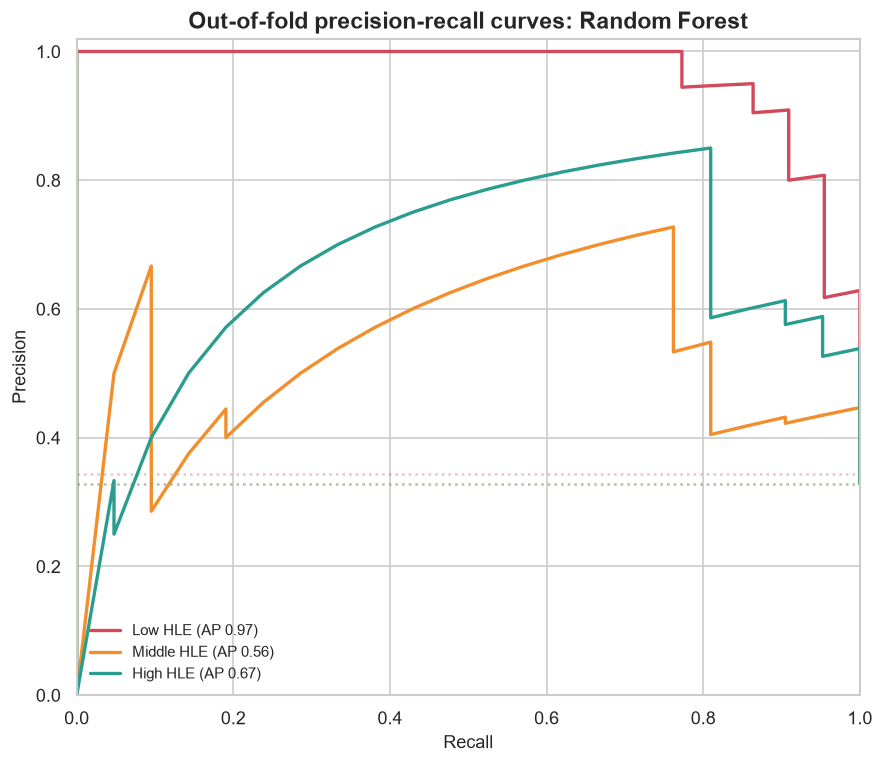

In [48]:
# Plotting one-versus-rest precision-recall curves for the three HLE groups.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for class_position, class_label in enumerate(hle_category_labels):
    precision_values, recall_values, _ = precision_recall_curve(
        best_observed_binary[:, class_position],
        best_probabilities[:, class_position],
    )
    class_average_precision = average_precision_score(
        best_observed_binary[:, class_position],
        best_probabilities[:, class_position],
    )
    class_prevalence = best_observed_binary[:, class_position].mean()
    ax.plot(
        recall_values,
        precision_values,
        lw=2,
        color=classification_colours[class_position],
        label=f"{class_label} (AP {class_average_precision:.2f})",
    )
    ax.axhline(class_prevalence, color=classification_colours[class_position], ls=":", alpha=0.35)
# Labelling, saving and displaying the precision-recall figure.
ax.set(
    title=f"Out-of-fold precision-recall curves: {best_classifier_name}",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(fontsize=9, loc="lower left")
fig.tight_layout()
fig.savefig(figures_dir / "27_classification_precision_recall_curves.png", bbox_inches="tight")
plt.show()

### Probability calibration

Calibration is descriptive because the sample contains only 64 council-sex observations and the three classes are evaluated with five probability bins.


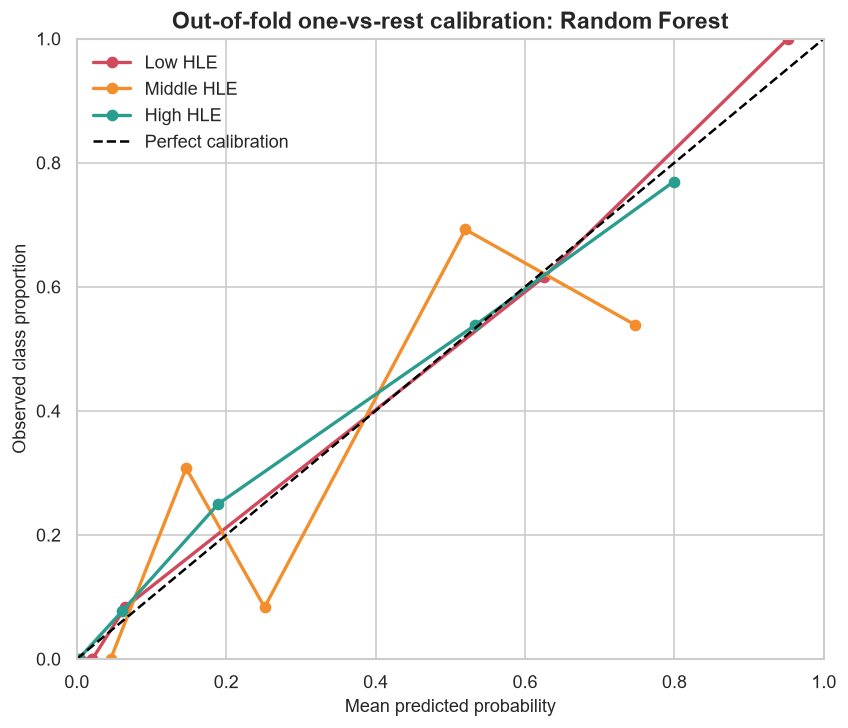

In [49]:
# Creating a table and figure for checking the classifier's predicted probabilities.
calibration_rows = []
fig, ax = plt.subplots(figsize=(7.2, 6.2))

# Calculating five-bin calibration points for each HLE group.
for class_position, class_label in enumerate(hle_category_labels):
    calibration_observed, calibration_predicted = calibration_curve(
        best_observed_binary[:, class_position],
        best_probabilities[:, class_position],
        n_bins=5,
        strategy="quantile",
    )
    for mean_probability, observed_proportion in zip(calibration_predicted, calibration_observed):
        calibration_rows.append({
            "hle_category": class_label,
            "mean_predicted_probability": mean_probability,
            "observed_class_proportion": observed_proportion,
        })
    ax.plot(
        calibration_predicted,
        calibration_observed,
        marker="o",
        lw=2,
        color=classification_colours[class_position],
        label=class_label,
    )

# Saving the calibration values used in the figure.
calibration_table = pd.DataFrame(calibration_rows)
calibration_table.to_csv(tables_dir / "27_classification_calibration.csv", index=False)

# Adding the perfect-calibration line, then saving and displaying the plot.
ax.plot([0, 1], [0, 1], ls="--", color="black", label="Perfect calibration")
ax.set(
    title=f"Out-of-fold one-vs-rest calibration: {best_classifier_name}",
    xlabel="Mean predicted probability",
    ylabel="Observed class proportion",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "28_classification_calibration.png", bbox_inches="tight")
plt.show()

### Classification performance by sex


In [50]:
# Calculating the best classifier's performance separately for female and male observations.
classification_subgroup_rows = []
for sex_name in ["Female", "Male"]:
    subgroup = best_classifier_predictions.loc[best_classifier_predictions["sex"].eq(sex_name)]
    subgroup_observed = subgroup["observed_class_code"].to_numpy()
    subgroup_predicted = subgroup["predicted_class_code"].to_numpy()
    subgroup_probabilities = subgroup[probability_columns].to_numpy()
    classification_subgroup_rows.append({
        "sex": sex_name,
        "n": len(subgroup),
        "accuracy": accuracy_score(subgroup_observed, subgroup_predicted),
        "balanced_accuracy": balanced_accuracy_score(subgroup_observed, subgroup_predicted),
        "macro_precision": precision_score(subgroup_observed, subgroup_predicted, average="macro", zero_division=0),
        "macro_recall": recall_score(subgroup_observed, subgroup_predicted, average="macro", zero_division=0),
        "macro_f1": f1_score(subgroup_observed, subgroup_predicted, average="macro", zero_division=0),
        "weighted_kappa": cohen_kappa_score(subgroup_observed, subgroup_predicted, weights="quadratic"),
        "extreme_error_rate": np.mean(np.abs(subgroup_observed - subgroup_predicted) == 2),
        "roc_auc_ovr_macro": roc_auc_score(
            subgroup_observed,
            subgroup_probabilities,
            labels=classification_class_codes,
            multi_class="ovr",
            average="macro",
        ),
    })

# Saving and displaying the sex-specific classification results.
classification_subgroup_metrics = pd.DataFrame(classification_subgroup_rows)
classification_subgroup_metrics.to_csv(tables_dir / "28_classification_subgroup_metrics.csv", index=False)
print(classification_subgroup_metrics.round(3).to_string(index=False))

   sex  n  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_kappa  extreme_error_rate  roc_auc_ovr_macro
Female 32     0.844              0.842            0.845         0.842     0.843           0.884                 0.0              0.894
  Male 32     0.812              0.812            0.812         0.812     0.812           0.857                 0.0              0.860


### Predicted probabilities by council and sex

The strongest classifier gives a probability for each HLE band, not just a final label. The two-panel profile shows female and male council populations separately and highlights where the model is more or less certain.


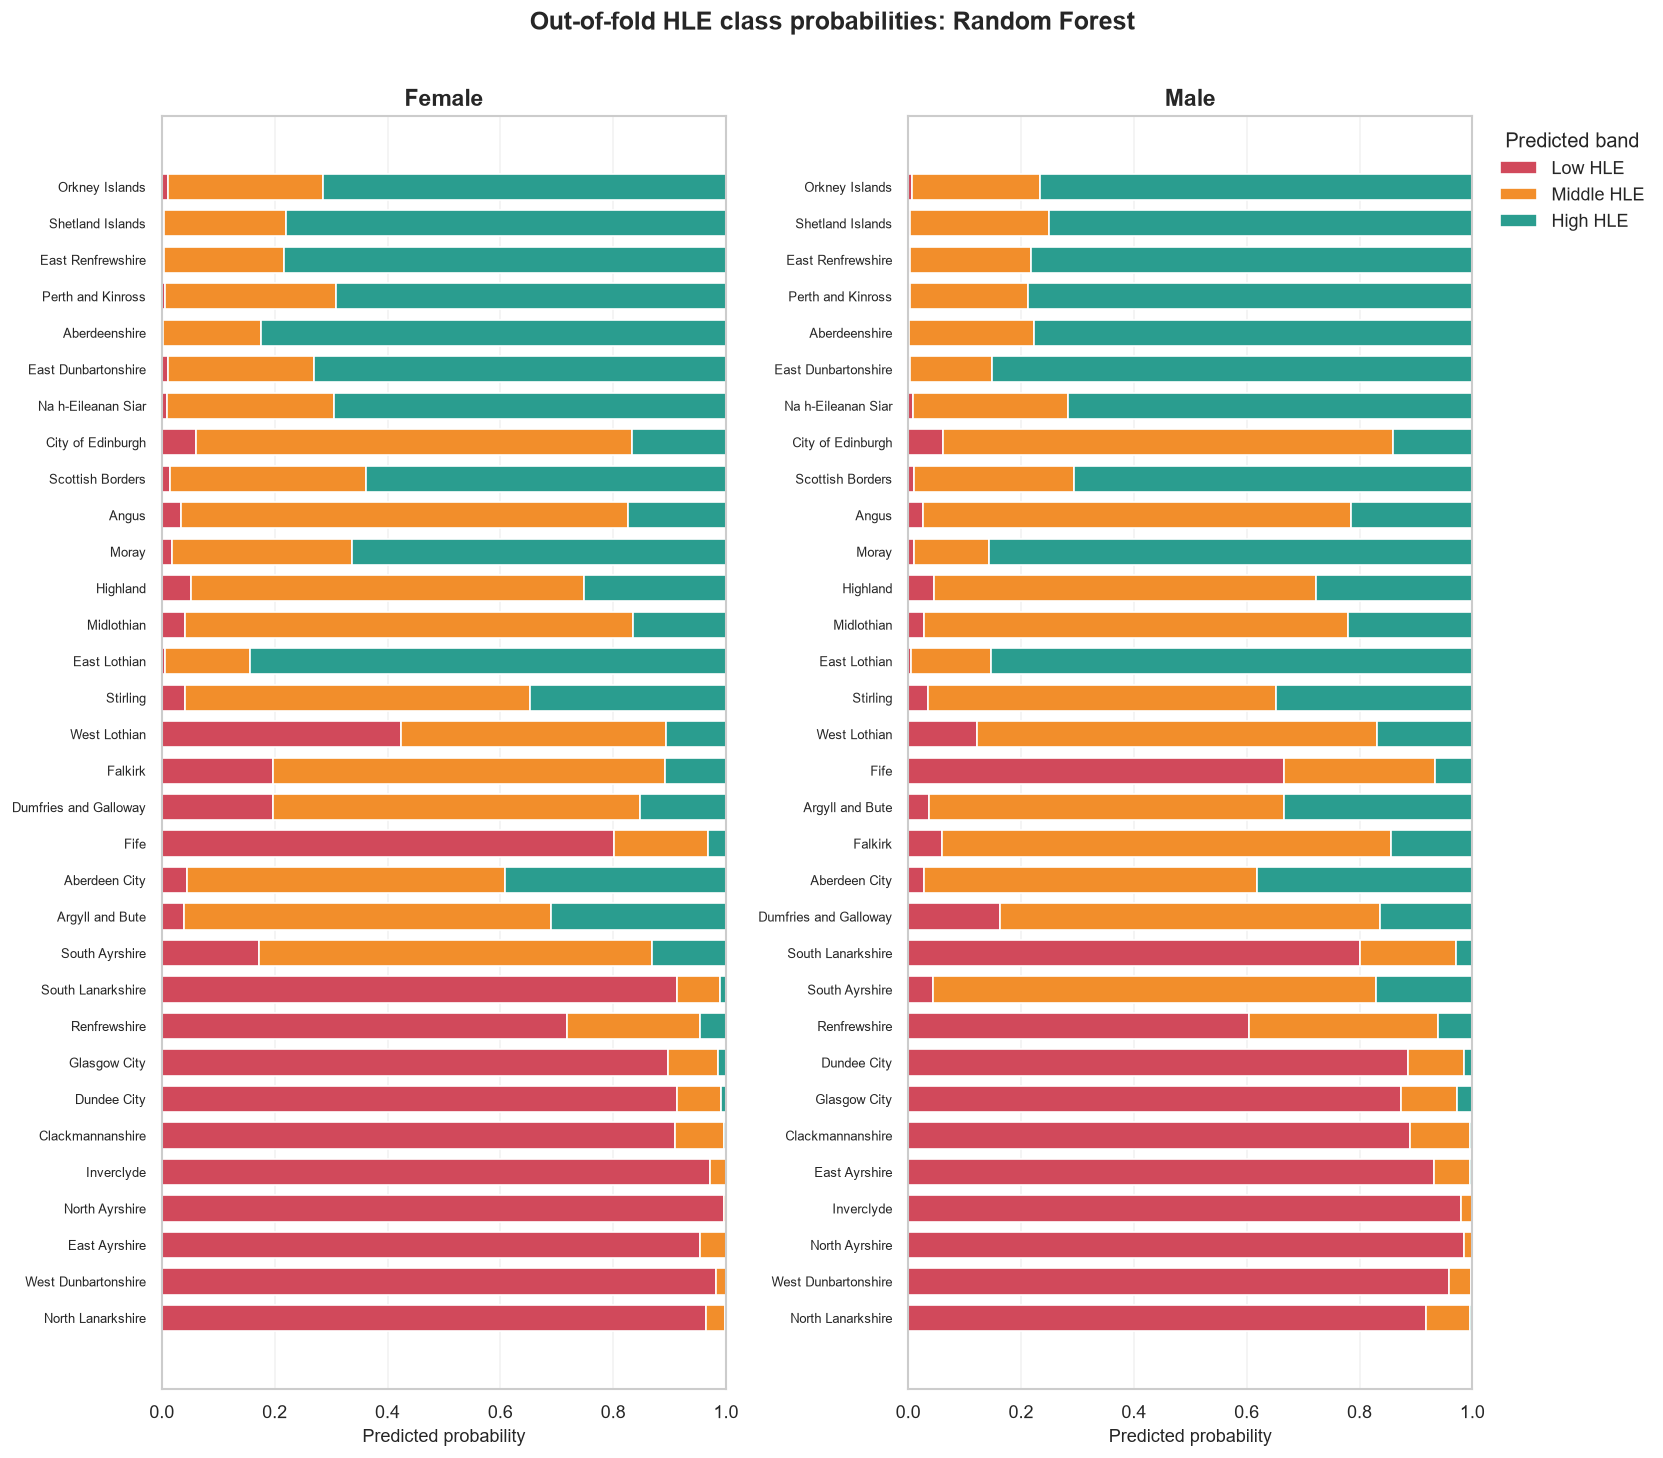

In [51]:
# Combining the best classifier probabilities with observed HLE and the best regression predictions.
classification_probability_profiles = best_classifier_predictions.merge(
    at_birth[["council_area", "sex", "healthy_life_expectancy_years"]].reset_index(names="row_index"),
    on=["row_index", "council_area", "sex"],
    how="left",
    validate="one_to_one",
)
classification_probability_profiles = classification_probability_profiles.merge(
    best_regression_predictions[["row_index", "predicted_hle"]],
    on="row_index",
    how="left",
    validate="one_to_one",
)
# Converting the regression predictions into the same three HLE groups and saving the combined profiles.
classification_probability_profiles["regression_category"] = pd.cut(
    classification_probability_profiles["predicted_hle"],
    bins=[-np.inf, hle_low_threshold, hle_high_threshold, np.inf],
    labels=hle_category_labels,
    ordered=True,
)
classification_probability_profiles.to_csv(tables_dir / "29_classification_probability_profiles.csv", index=False)

# Plotting the Low, Middle and High predicted probabilities for every council, separately by sex.
fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharex=True)
for axis, sex_name in zip(axes, ["Female", "Male"]):
    subgroup = classification_probability_profiles.loc[
        classification_probability_profiles["sex"].eq(sex_name)
    ].sort_values("healthy_life_expectancy_years")
    positions = np.arange(len(subgroup))
    left_values = np.zeros(len(subgroup))
    for probability_column, class_label, class_colour in zip(
        probability_columns,
        hle_category_labels,
        classification_colours,
    ):
        probabilities = subgroup[probability_column].to_numpy()
        axis.barh(
            positions,
            probabilities,
            left=left_values,
            color=class_colour,
            label=class_label,
            height=0.72,
        )
        left_values = left_values + probabilities
    axis.set_yticks(positions)
    axis.set_yticklabels(subgroup["council_area"], fontsize=8)
    axis.set(title=sex_name, xlabel="Predicted probability", xlim=(0, 1))
    axis.grid(axis="x", alpha=0.25)
    axis.grid(axis="y", visible=False)

# Adding the shared legend, then saving and displaying the probability profiles.
axes[1].legend(title="Predicted band", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"Out-of-fold HLE class probabilities: {best_classifier_name}", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(figures_dir / "29_classification_probability_profiles.png", bbox_inches="tight")
plt.show()


### Agreement between regression-derived and directly classified bands

The strongest regression model's HLE predictions can be placed into Low, Middle or High using the same fixed boundaries. Comparing these groups with the direct classifier shows whether both approaches give similar results

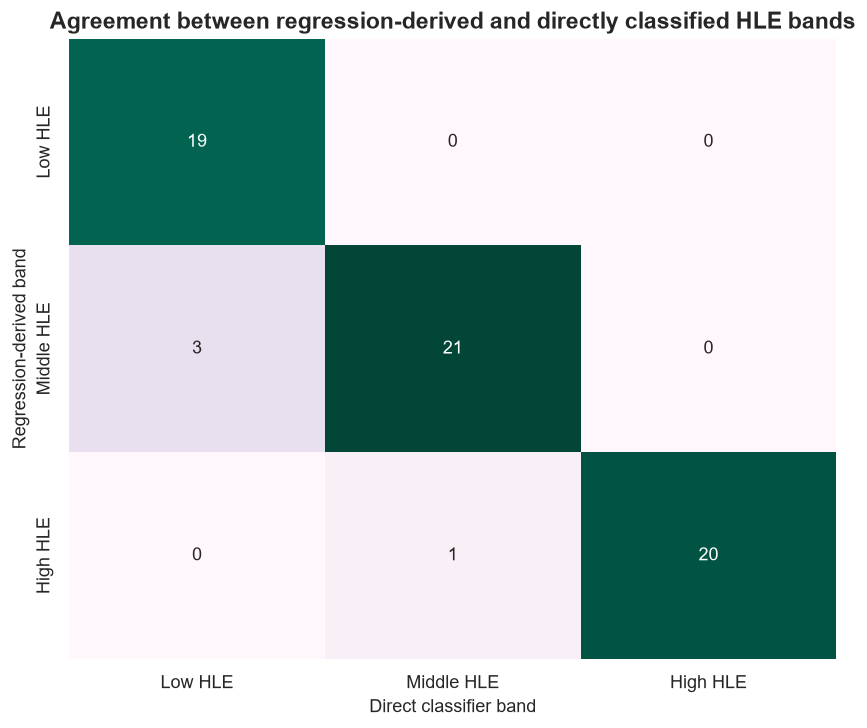

In [52]:
# Converting the regression-derived HLE groups to the same numeric codes used by the classifier.
classification_probability_profiles["regression_category_code"] = classification_probability_profiles[
    "regression_category"
].map(hle_category_codes).astype(int)

# Creating a matrix comparing the groups produced by the two modelling routes.
method_agreement_matrix = confusion_matrix(
    classification_probability_profiles["regression_category_code"],
    classification_probability_profiles["predicted_class_code"],
    labels=classification_class_codes,
)

# Calculating how accurately each route matches the observed groups and how often the routes agree.
regression_band_accuracy = accuracy_score(
    classification_probability_profiles["observed_class_code"],
    classification_probability_profiles["regression_category_code"],
)
regression_band_kappa = cohen_kappa_score(
    classification_probability_profiles["observed_class_code"],
    classification_probability_profiles["regression_category_code"],
    weights="quadratic",
)
direct_classifier_accuracy = accuracy_score(
    classification_probability_profiles["observed_class_code"],
    classification_probability_profiles["predicted_class_code"],
)
direct_classifier_kappa = cohen_kappa_score(
    classification_probability_profiles["observed_class_code"],
    classification_probability_profiles["predicted_class_code"],
    weights="quadratic",
)
method_agreement_rate = accuracy_score(
    classification_probability_profiles["regression_category_code"],
    classification_probability_profiles["predicted_class_code"],
)
extreme_method_disagreement_rate = np.mean(
    np.abs(
        classification_probability_profiles["regression_category_code"]
        - classification_probability_profiles["predicted_class_code"]
    ) == 2
)

# Collecting and saving the regression-classification consistency measures.
regression_classification_summary = pd.DataFrame({
    "metric": [
        "Regression-derived band accuracy",
        "Regression-derived weighted kappa",
        "Direct classifier accuracy",
        "Direct classifier weighted kappa",
        "Agreement between modelling routes",
        "Extreme disagreement between routes",
    ],
    "value": [
        regression_band_accuracy,
        regression_band_kappa,
        direct_classifier_accuracy,
        direct_classifier_kappa,
        method_agreement_rate,
        extreme_method_disagreement_rate,
    ],
})
regression_classification_summary.to_csv(tables_dir / "30_regression_classification_consistency.csv", index=False)

# Displaying, saving and showing the agreement matrix.
fig, ax = plt.subplots(figsize=(7.2, 6.2))
sns.heatmap(
    method_agreement_matrix,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    cbar=False,
    xticklabels=hle_category_labels,
    yticklabels=hle_category_labels,
    ax=ax,
)
ax.set(
    title="Agreement between regression-derived and directly classified HLE bands",
    xlabel="Direct classifier band",
    ylabel="Regression-derived band",
)
fig.tight_layout()
fig.savefig(figures_dir / "30_regression_classification_consistency.png", bbox_inches="tight")
plt.show()



### Regression and classification consistency summary

In [53]:
# Displaying the consistency results for the regression-derived and directly classified HLE groups.
print(regression_classification_summary.round(3).to_string(index=False))

                             metric  value
   Regression-derived band accuracy  0.797
  Regression-derived weighted kappa  0.843
         Direct classifier accuracy  0.828
   Direct classifier weighted kappa  0.870
 Agreement between modelling routes  0.938
Extreme disagreement between routes  0.000


## 7. Model interpretation and feature importance

Different explanation methods provide different views of model behaviour.

### Tune the final regression models on all at-birth data

These fitted models are used for interpretation only. Random Forest is retained as the best predictive regression model based on the out-of-fold results, while Gradient Boosting is used for permutation importance, partial dependence and Shapley analysis. Ridge is used to provide a standardised linear coefficient comparison.

In [54]:
# Using all councils to tune the final models only after the out-of-fold performance comparison is complete.
full_group_cv = GroupKFold(n_splits=8)

# Refitting the selected regression model for final prediction and interpretation.
best_regression_search = GridSearchCV(
    estimator=clone(regression_models[best_regression_model_name]),
    param_grid=regression_parameter_grids[best_regression_model_name],
    scoring="neg_mean_absolute_error",
    cv=full_group_cv,
    n_jobs=-1,
    refit=True,
)
best_regression_search.fit(X_regression, y_regression, groups=regression_groups)
best_regression_full_model = best_regression_search.best_estimator_

# Fitting a Gradient Boosting model for permutation, partial-dependence and SHAP explanations.
explanation_search = GridSearchCV(
    estimator=clone(regression_models["Gradient Boosting"]),
    param_grid=regression_parameter_grids["Gradient Boosting"],
    scoring="neg_mean_absolute_error",
    cv=full_group_cv,
    n_jobs=-1,
    refit=True,
)
explanation_search.fit(X_regression, y_regression, groups=regression_groups)
explanation_model = explanation_search.best_estimator_

# Fitting a Ridge model so the standardised linear coefficients can be interpreted.
ridge_search = GridSearchCV(
    estimator=clone(regression_models["Ridge"]),
    param_grid=regression_parameter_grids["Ridge"],
    scoring="neg_mean_absolute_error",
    cv=full_group_cv,
    n_jobs=-1,
    refit=True,
)
ridge_search.fit(X_regression, y_regression, groups=regression_groups)
ridge_model = ridge_search.best_estimator_

# Fitting a Random Forest model for its tree-based feature-importance comparison.
forest_search = GridSearchCV(
    estimator=clone(regression_models["Random Forest"]),
    param_grid=regression_parameter_grids["Random Forest"],
    scoring="neg_mean_absolute_error",
    cv=full_group_cv,
    n_jobs=-1,
    refit=True,
)
forest_search.fit(X_regression, y_regression, groups=regression_groups)
forest_model = forest_search.best_estimator_

# Displaying the final parameter settings selected for the fitted models.
print(pd.DataFrame({
    "model": [best_regression_model_name, "Gradient Boosting explanation model", "Ridge", "Random Forest"],
    "selected_parameters": [str(best_regression_search.best_params_), str(explanation_search.best_params_), str(ridge_search.best_params_), str(forest_search.best_params_)],
}).to_string(index=False))

                              model                                                                                           selected_parameters
                      Random Forest                          {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 3}
Gradient Boosting explanation model {'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__min_samples_leaf': 2, 'model__n_estimators': 50}
                              Ridge                                                                                          {'model__alpha': 10}
                      Random Forest                          {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 3}


### Ridge coefficient importance


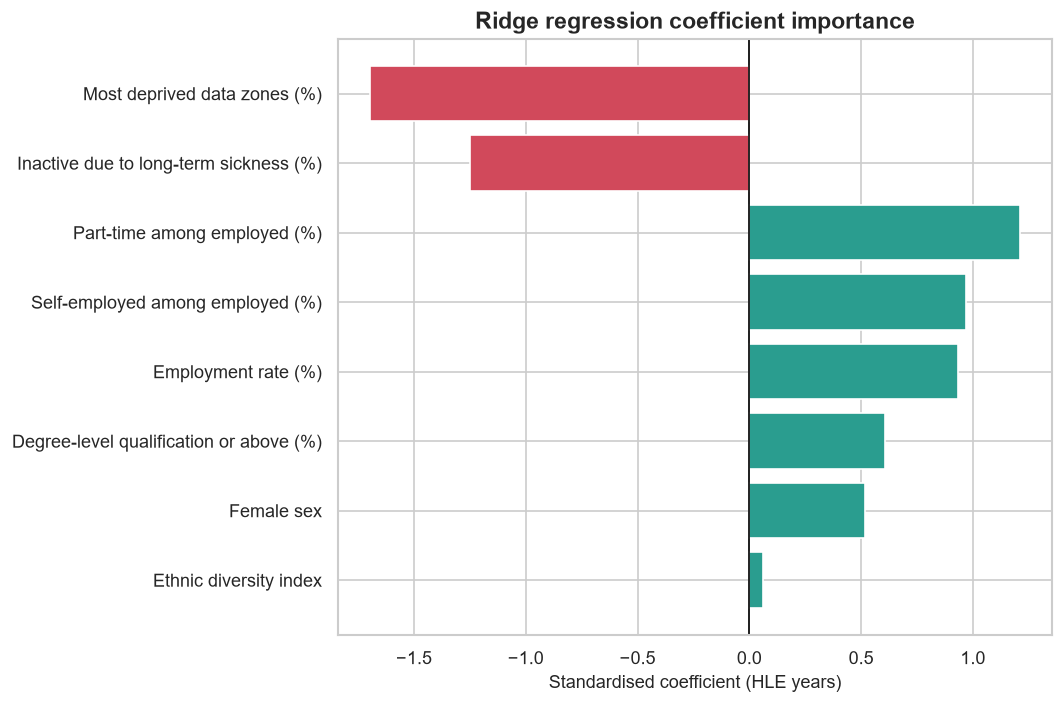

In [55]:
# Collecting and ranking the fitted Ridge model's standardised coefficients.
ridge_coefficients = pd.DataFrame({
    "feature": ml_features,
    "feature_label": [ml_feature_labels[column] for column in ml_features],
    "standardised_coefficient_years": ridge_model.named_steps["model"].coef_,
})
ridge_coefficients["absolute_coefficient"] = ridge_coefficients["standardised_coefficient_years"].abs()
ridge_coefficients = ridge_coefficients.sort_values("absolute_coefficient")
ridge_coefficients.to_csv(tables_dir / "31_ridge_coefficients.csv", index=False)

# Plotting whether each predictor is associated with a higher or lower fitted HLE value.
fig, ax = plt.subplots(figsize=(9, 6))
bar_colours = np.where(ridge_coefficients["standardised_coefficient_years"] >= 0, TEAL, RED)
ax.barh(ridge_coefficients["feature_label"], ridge_coefficients["standardised_coefficient_years"], color=bar_colours)
# Adding the zero reference line, then saving and displaying the coefficient chart.
ax.axvline(0, color="black", lw=1)
ax.set(title="Ridge regression coefficient importance", xlabel="Standardised coefficient (HLE years)", ylabel="")
fig.tight_layout()
fig.savefig(figures_dir / "31_ridge_coefficient_importance.png", bbox_inches="tight")
plt.show()

### Random Forest impurity importance

This view is descriptive and can favour continuous or highly variable predictors. It is therefore interpreted alongside permutation importance and SHAP.


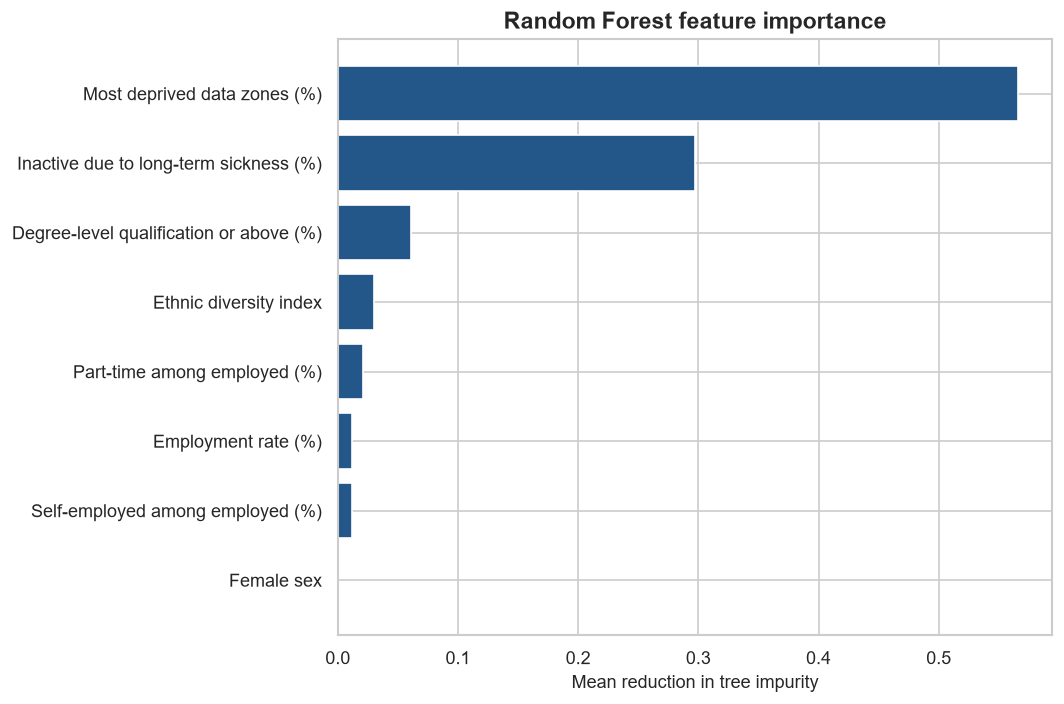

In [56]:
# Collecting and ranking the Random Forest's built-in feature importance values.
forest_importance = pd.DataFrame({
    "feature": ml_features,
    "feature_label": [ml_feature_labels[column] for column in ml_features],
    "importance": forest_model.named_steps["model"].feature_importances_,
}).sort_values("importance")
forest_importance.to_csv(tables_dir / "32_random_forest_feature_importance.csv", index=False)

# Plotting, saving and displaying the tree-based feature ranking.
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(forest_importance["feature_label"], forest_importance["importance"], color=BLUE)
ax.set(title="Random Forest feature importance", xlabel="Mean reduction in tree impurity", ylabel="")
fig.tight_layout()
fig.savefig(figures_dir / "32_random_forest_feature_importance.png", bbox_inches="tight")
plt.show()

### Permutation importance

Permutation importance shows how much the fitted Gradient Boosting model's MAE changes when each feature is shuffled. Larger changes indicate greater model reliance. These results describe model behaviour, not causation.

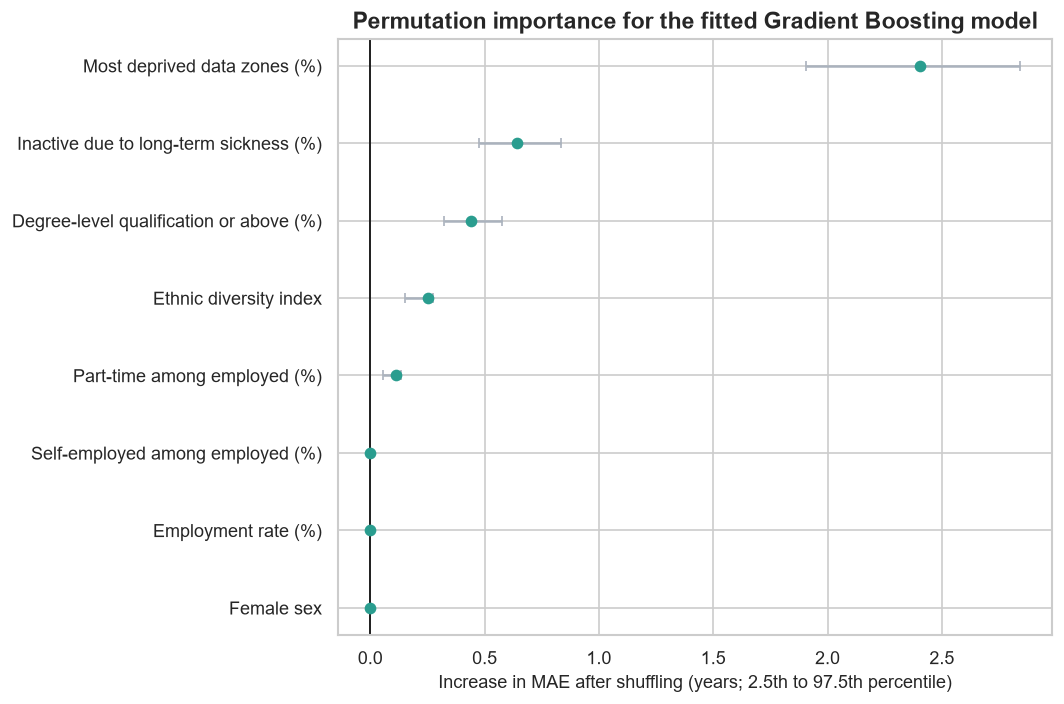

In [57]:
# Measuring how much the fitted Gradient Boosting model worsens when each feature is shuffled.
permutation_result = permutation_importance(
    explanation_model,
    X_regression,
    y_regression,
    scoring="neg_mean_absolute_error",
    n_repeats=100,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
# Organising and saving the permutation importance results and their shuffle intervals.
permutation_table = pd.DataFrame({
    "feature": ml_features,
    "feature_label": [ml_feature_labels[column] for column in ml_features],
    "mean_mae_increase": permutation_result.importances_mean,
    "standard_deviation": permutation_result.importances_std,
    "shuffle_interval_lower": np.percentile(permutation_result.importances, 2.5, axis=1),
    "shuffle_interval_upper": np.percentile(permutation_result.importances, 97.5, axis=1),
})
permutation_table = permutation_table.sort_values("mean_mae_increase")
permutation_table.to_csv(tables_dir / "33_permutation_importance.csv", index=False)

# Plotting each feature's increase in prediction error after shuffling.
fig, ax = plt.subplots(figsize=(9, 6))
y_positions = np.arange(len(permutation_table))
ax.errorbar(
    permutation_table["mean_mae_increase"],
    y_positions,
    xerr=[
        permutation_table["mean_mae_increase"] - permutation_table["shuffle_interval_lower"],
        permutation_table["shuffle_interval_upper"] - permutation_table["mean_mae_increase"],
    ],
    fmt="o",
    color=TEAL,
    ecolor="#AAB2BD",
    capsize=3,
)
# Adding the zero reference line, then saving and displaying the importance plot.
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(permutation_table["feature_label"])
ax.set(
    title="Permutation importance for the fitted Gradient Boosting model",
    xlabel="Increase in MAE after shuffling (years; 2.5th to 97.5th percentile)",
    ylabel="",
)
fig.tight_layout()
fig.savefig(figures_dir / "33_permutation_importance.png", bbox_inches="tight")
plt.show()

### Partial dependence

Partial dependence shows how the model's average prediction changes as one feature varies. It is used to understand model behaviour, not cause and effect.

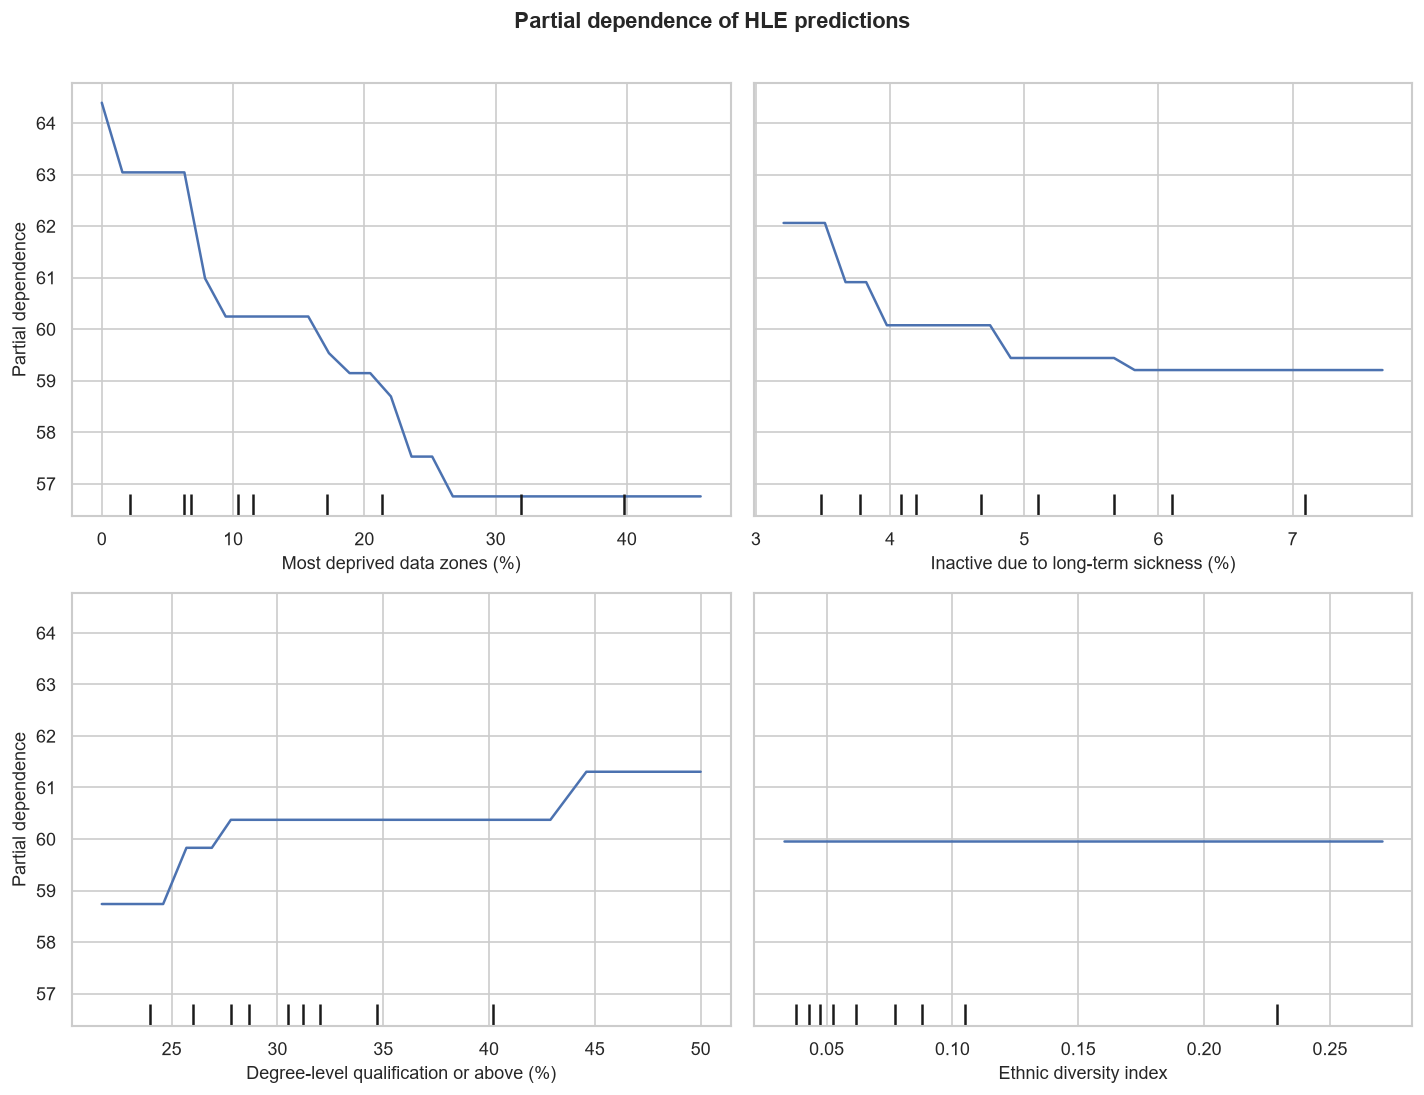

In [58]:
# Selecting the four features with the largest permutation importance.
top_permutation_features = permutation_table.sort_values("mean_mae_increase", ascending=False).head(4)["feature"].tolist()
top_permutation_positions = [ml_features.index(feature) for feature in top_permutation_features]
# Plotting how the fitted HLE prediction changes across each selected feature.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
PartialDependenceDisplay.from_estimator(
    explanation_model,
    X_regression,
    features=top_permutation_positions,
    feature_names=[ml_feature_labels[column] for column in ml_features],
    kind="average",
    grid_resolution=30,
    ax=axes,
)
# Adding the overall title, then saving and displaying the partial-dependence figure.
fig.suptitle("Partial dependence of HLE predictions", fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(figures_dir / "34_partial_dependence.png", bbox_inches="tight")
plt.show()

## 8. Exact reference-based Shapley analysis

Exact reference-based Shapley values are calculated for the fitted Gradient Boosting model using all feature subsets. Missing features use the Scottish at-birth sample mean. Correlated features may share their contribution

### Exact Shapley calculation and additivity check


In [59]:
# Setting the mean predictor profile as the SHAP reference and calculating its model prediction.
shap_feature_count = len(ml_features)
shap_reference = X_regression.mean().to_numpy()
shap_reference_frame = pd.DataFrame([shap_reference], columns=ml_features)
shap_baseline_prediction = explanation_model.predict(shap_reference_frame)[0]
shap_values = np.zeros((len(X_regression), shap_feature_count))

# Listing every possible feature subset needed for exact Shapley values with eight predictors.
all_masks = list(range(2 ** shap_feature_count))
# Explaining each council-sex prediction by comparing all combinations of observed and reference values.
for row_position in range(len(X_regression)):
    observed_row = X_regression.iloc[row_position].to_numpy()
    prediction_cache = {}

    # Caching the model prediction for every feature combination in this row.
    for mask in all_masks:
        hybrid_row = shap_reference.copy()
        included_positions = [feature_position for feature_position in range(shap_feature_count) if mask & (1 << feature_position)]
        hybrid_row[included_positions] = observed_row[included_positions]
        hybrid_frame = pd.DataFrame([hybrid_row], columns=ml_features)
        prediction_cache[mask] = explanation_model.predict(hybrid_frame)[0]

    # Calculating each feature's weighted contribution across all combinations that exclude it.
    for feature_position in range(shap_feature_count):
        feature_contribution = 0.0
        for mask in all_masks:
            if mask & (1 << feature_position):
                continue
            subset_size = mask.bit_count()
            shap_weight = factorial(subset_size) * factorial(shap_feature_count - subset_size - 1) / factorial(shap_feature_count)
            feature_contribution += shap_weight * (prediction_cache[mask | (1 << feature_position)] - prediction_cache[mask])
        shap_values[row_position, feature_position] = feature_contribution

# Checking that the baseline plus all SHAP contributions exactly reconstructs each model prediction.
shap_predictions = explanation_model.predict(X_regression)
shap_reconstructed_predictions = shap_baseline_prediction + shap_values.sum(axis=1)
shap_max_additivity_error = np.max(np.abs(shap_predictions - shap_reconstructed_predictions))

# Saving the individual SHAP values together with each observation and prediction.
shap_table = pd.DataFrame(shap_values, columns=[f"SHAP: {ml_feature_labels[column]}" for column in ml_features])
shap_table.insert(0, "model_prediction", shap_predictions)
shap_table.insert(0, "observed_hle", y_regression.to_numpy())
shap_table.insert(0, "sex", at_birth["sex"].to_numpy())
shap_table.insert(0, "council_area", at_birth["council_area"].to_numpy())
shap_table.to_csv(tables_dir / "34_shap_values.csv", index=False)

# Saving and displaying the SHAP additivity check.
shap_check = pd.DataFrame({
    "check": ["Reference prediction", "Maximum SHAP additivity error", "Rows explained", "Features explained"],
    "value": [shap_baseline_prediction, shap_max_additivity_error, len(X_regression), shap_feature_count],
})
shap_check.to_csv(tables_dir / "35_shap_additivity_check.csv", index=False)
print(shap_check.to_string(index=False))

                        check        value
         Reference prediction 5.892551e+01
Maximum SHAP additivity error 1.421085e-14
               Rows explained 6.400000e+01
           Features explained 8.000000e+00


### Global SHAP importance


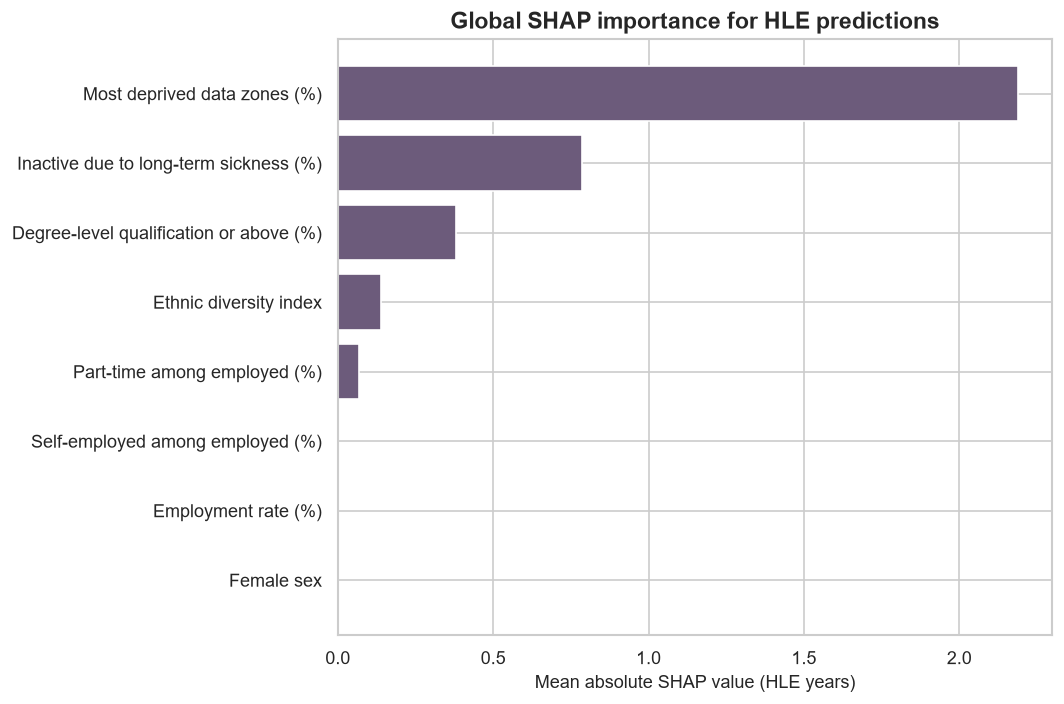

In [60]:
# Averaging the absolute SHAP contributions to create a global feature ranking.
mean_absolute_shap = np.mean(np.abs(shap_values), axis=0)
shap_importance = pd.DataFrame({
    "feature": ml_features,
    "feature_label": [ml_feature_labels[column] for column in ml_features],
    "mean_absolute_shap_years": mean_absolute_shap,
}).sort_values("mean_absolute_shap_years")
shap_importance.to_csv(tables_dir / "36_shap_global_importance.csv", index=False)

# Plotting, saving and displaying the global SHAP importance values in HLE years.
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_importance["feature_label"], shap_importance["mean_absolute_shap_years"], color=PURPLE)
ax.set(title="Global SHAP importance for HLE predictions", xlabel="Mean absolute SHAP value (HLE years)", ylabel="")
fig.tight_layout()
fig.savefig(figures_dir / "35_shap_global_bar.png", bbox_inches="tight")
plt.show()

### SHAP summary plot

Each dot represents a council-sex observation. Position shows whether the feature increased or decreased predicted HLE, while colour shows whether its value was low or high


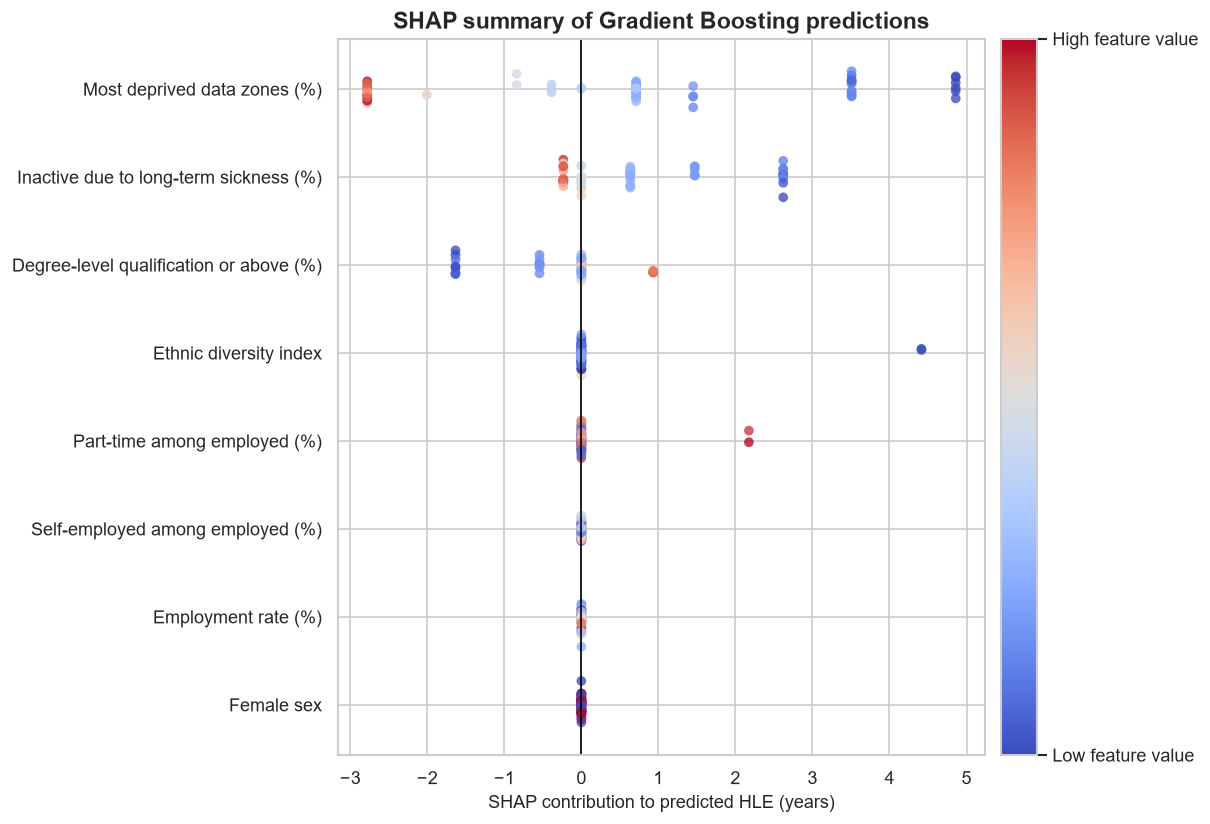

In [61]:
# Ordering the predictors from lower to higher average SHAP importance.
shap_order = np.argsort(mean_absolute_shap)
# Plotting every observation's SHAP contribution and colour it by the feature value.
fig, ax = plt.subplots(figsize=(10, 7))
for display_position, feature_position in enumerate(shap_order):
    feature_values = X_regression.iloc[:, feature_position].to_numpy()
    feature_min = feature_values.min()
    feature_range = max(feature_values.max() - feature_min, 1e-12)
    normalised_values = (feature_values - feature_min) / feature_range
    vertical_jitter = rng.normal(0, 0.09, size=len(feature_values))
    ax.scatter(
        shap_values[:, feature_position],
        display_position + vertical_jitter,
        c=normalised_values,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        s=34,
        alpha=0.78,
        edgecolor="none",
    )
# Adding the zero line and feature labels, then saving and displaying the SHAP summary.
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(shap_feature_count))
ax.set_yticklabels([ml_feature_labels[ml_features[position]] for position in shap_order])
ax.set(title="SHAP summary of Gradient Boosting predictions", xlabel="SHAP contribution to predicted HLE (years)", ylabel="")
colour_map = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1))
colour_bar = fig.colorbar(colour_map, ax=ax, pad=0.02)
colour_bar.set_ticks([0, 1])
colour_bar.set_ticklabels(["Low feature value", "High feature value"])
fig.tight_layout()
fig.savefig(figures_dir / "36_shap_beeswarm.png", bbox_inches="tight")
plt.show()

### SHAP dependence plot for the most influential feature


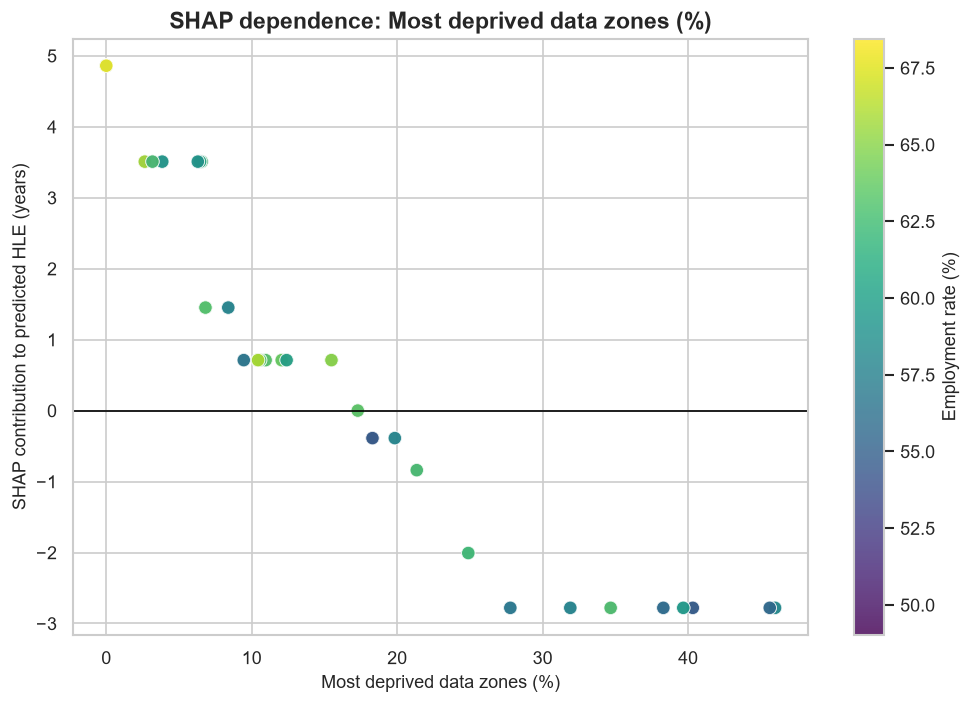

In [62]:
# Choosing the most important SHAP feature and a second feature for the colour scale.
top_shap_position = int(np.argmax(mean_absolute_shap))
top_shap_feature = ml_features[top_shap_position]
interaction_colour_feature = "economic_employment_rate_pct" if top_shap_feature != "economic_employment_rate_pct" else "census_degree_level_qualification_or_above_population_aged_16plus_pct"

# Plotting how the top feature's values relate to its contribution to predicted HLE.
fig, ax = plt.subplots(figsize=(8.5, 6))
dependence_scatter = ax.scatter(
    X_regression[top_shap_feature],
    shap_values[:, top_shap_position],
    c=X_regression[interaction_colour_feature],
    cmap="viridis",
    s=65,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.5,
)
# Adding the zero reference line, then saving and displaying the dependence plot.
ax.axhline(0, color="black", lw=1)
ax.set(title=f"SHAP dependence: {ml_feature_labels[top_shap_feature]}", xlabel=ml_feature_labels[top_shap_feature], ylabel="SHAP contribution to predicted HLE (years)")
fig.colorbar(dependence_scatter, ax=ax, label=ml_feature_labels[interaction_colour_feature])
fig.tight_layout()
fig.savefig(figures_dir / "37_shap_dependence.png", bbox_inches="tight")
plt.show()

### Local SHAP explanation

The council-sex observation with the lowest HLE is used as an example. This explains the model prediction for that population, not an individual's health.

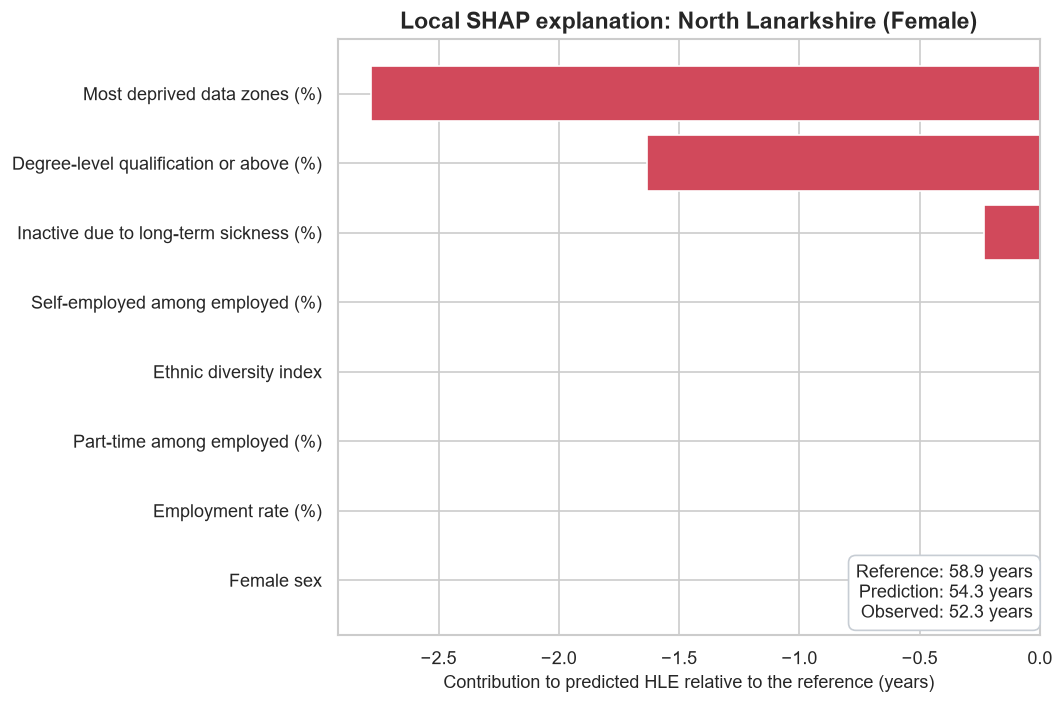

In [63]:
# Selecting the observation with the lowest recorded HLE for a local model explanation.
local_row_position = int(np.argmin(y_regression.to_numpy()))
# Collecting and ranking the SHAP contributions for this one council-sex observation.
local_contributions = pd.DataFrame({
    "feature_label": [ml_feature_labels[column] for column in ml_features],
    "shap_value": shap_values[local_row_position],
})
local_contributions["absolute_shap"] = local_contributions["shap_value"].abs()
local_contributions = local_contributions.sort_values("absolute_shap")

# Plotting the features that push this prediction above or below the reference prediction.
fig, ax = plt.subplots(figsize=(9, 6))
local_colours = np.where(local_contributions["shap_value"] >= 0, TEAL, RED)
ax.barh(local_contributions["feature_label"], local_contributions["shap_value"], color=local_colours)
ax.axvline(0, color="black", lw=1)
# Adding the reference, predicted and observed HLE values, then saving and displaying the explanation.
local_row = at_birth.iloc[local_row_position]
ax.set(
    title=f"Local SHAP explanation: {local_row['council_area']} ({local_row['sex']})",
    xlabel="Contribution to predicted HLE relative to the reference (years)",
    ylabel="",
)
ax.text(
    0.99, 0.02,
    f"Reference: {shap_baseline_prediction:.1f} years\nPrediction: {shap_predictions[local_row_position]:.1f} years\nObserved: {y_regression.iloc[local_row_position]:.1f} years",
    transform=ax.transAxes, ha="right", va="bottom",
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "#C7CDD4"},
)
fig.tight_layout()
fig.savefig(figures_dir / "38_shap_local_explanation.png", bbox_inches="tight")
plt.show()

### Multinomial-logistic importance for classification

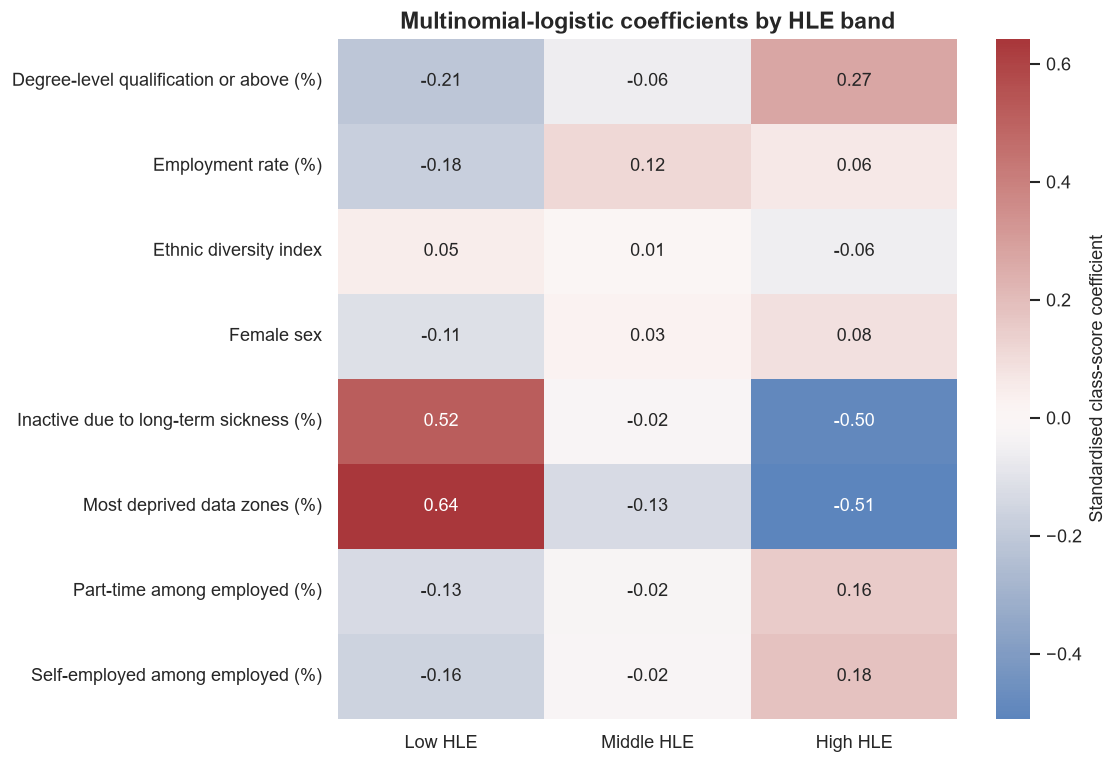

In [64]:
# Tuning and fitting the multinomial logistic model using all councils for coefficient interpretation.
classifier_full_cv = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=RANDOM_SEED)
logistic_search = GridSearchCV(
    estimator=clone(classification_models["Multinomial Logistic"]),
    param_grid=classification_parameter_grids["Multinomial Logistic"],
    scoring="balanced_accuracy",
    cv=classifier_full_cv,
    n_jobs=-1,
    refit=True,
)
logistic_search.fit(X_classification, y_classification, groups=classification_groups)
logistic_model = logistic_search.best_estimator_

# Collecting each feature's standardised coefficient for Low, Middle and High HLE.
logistic_coefficient_rows = []
for class_position, class_code in enumerate(logistic_model.named_steps["model"].classes_.astype(int)):
    for feature_position, feature_name in enumerate(ml_features):
        logistic_coefficient_rows.append({
            "class_code": class_code,
            "hle_category": hle_category_labels[class_code],
            "feature": feature_name,
            "feature_label": ml_feature_labels[feature_name],
            "standardised_class_score_coefficient": logistic_model.named_steps["model"].coef_[class_position, feature_position],
        })

# Saving the coefficients and arranging them into a three-column matrix.
logistic_coefficients = pd.DataFrame(logistic_coefficient_rows)
logistic_coefficients.to_csv(tables_dir / "37_multinomial_logistic_coefficients.csv", index=False)

logistic_coefficient_matrix = logistic_coefficients.pivot(
    index="feature_label",
    columns="hle_category",
    values="standardised_class_score_coefficient",
).reindex(columns=hle_category_labels)

# Displaying, saving and showing the class-specific coefficient heatmap.
fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.heatmap(
    logistic_coefficient_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    cbar_kws={"label": "Standardised class-score coefficient"},
    ax=ax,
)
ax.set(title="Multinomial-logistic coefficients by HLE band", xlabel="", ylabel="")
fig.tight_layout()
fig.savefig(figures_dir / "39_multinomial_logistic_coefficients.png", bbox_inches="tight")
plt.show()

### Class-feature overlap audit

Severe-deprivation exposure is compared across the three HLE bands to see whether the groups overlap or are mainly separated by this feature.

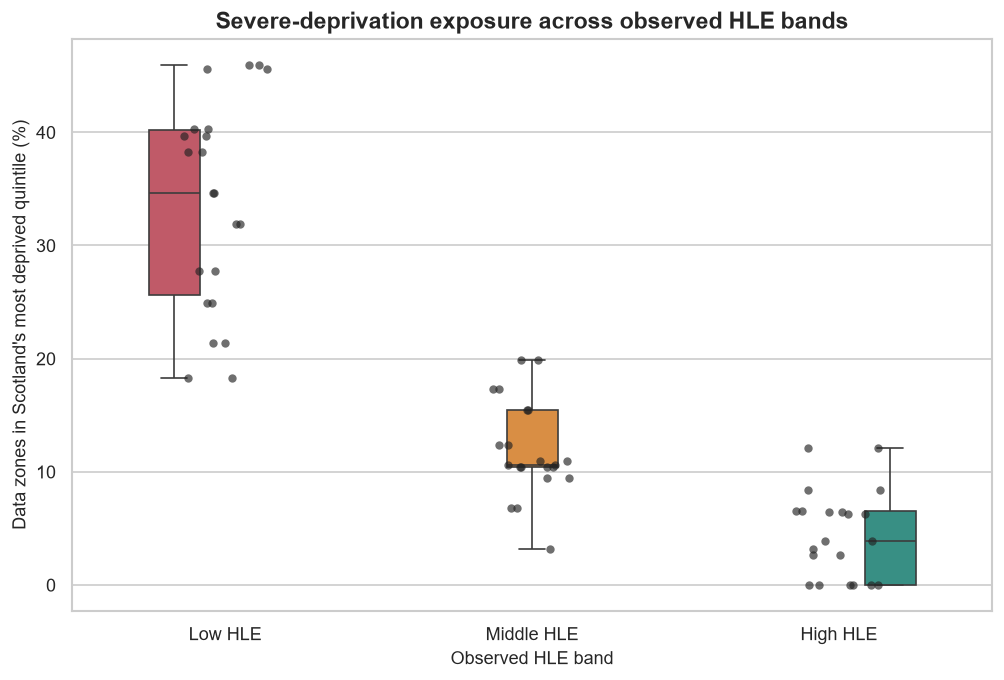

In [65]:
# Summarising how severe-deprivation exposure overlaps across the observed HLE groups.
separation_feature = "simd_most_deprived_quintile_datazones_share_pct"
separation_audit = at_birth.groupby("hle_category", observed=True)[separation_feature].agg(
    ["count", "min", "median", "max"]
).reset_index()
separation_audit.to_csv(tables_dir / "38_class_feature_overlap_audit.csv", index=False)

# Showing the distribution and individual observations within each HLE group.
fig, ax = plt.subplots(figsize=(8.5, 5.8))
sns.boxplot(
    data=at_birth,
    x="hle_category",
    y=separation_feature,
    hue="hle_category",
    order=hle_category_labels,
    hue_order=hle_category_labels,
    palette={"Low HLE": RED, "Middle HLE": ORANGE, "High HLE": TEAL},
    legend=False,
    width=0.5,
    ax=ax,
)
sns.stripplot(
    data=at_birth,
    x="hle_category",
    y=separation_feature,
    order=hle_category_labels,
    color="#222222",
    alpha=0.65,
    jitter=0.14,
    size=5,
    ax=ax,
)
# Labelling, saving and displaying the overlap audit plot.
ax.set(
    title="Severe-deprivation exposure across observed HLE bands",
    xlabel="Observed HLE band",
    ylabel="Data zones in Scotland's most deprived quintile (%)",
)
fig.tight_layout()
fig.savefig(figures_dir / "40_class_feature_overlap_audit.png", bbox_inches="tight")
plt.show()

## 9. Sensitivity analysis

The extended model adds health-context variables to check whether model performance and results change. Hyperparameters are selected within each training fold to avoid data leakage.

In [66]:
# Creating an extended feature set by adding the four outcome-adjacent health indicators.
extended_features = ml_features + health_context_columns
feature_set_results = []

# Comparing the core and extended feature sets using Ridge and Gradient Boosting.
for feature_set_name, feature_columns in {
    "Core upstream features": ml_features,
    "Extended health-context features": extended_features,
}.items():
    for model_name in ["Ridge", "Gradient Boosting"]:
        # Generating council-grouped out-of-fold predictions for this feature set and model.
        sensitivity_predictions = np.zeros(len(at_birth))
        for train_indices, test_indices in outer_regression_cv.split(
            at_birth[feature_columns],
            y_regression,
            regression_groups,
        ):
            X_train = at_birth.iloc[train_indices][feature_columns]
            X_test = at_birth.iloc[test_indices][feature_columns]
            y_train = y_regression.iloc[train_indices]
            groups_train = regression_groups.iloc[train_indices]

            # Tuning the model only inside each outer training fold.
            sensitivity_search = GridSearchCV(
                estimator=clone(regression_models[model_name]),
                param_grid=regression_parameter_grids[model_name],
                scoring="neg_mean_absolute_error",
                cv=GroupKFold(n_splits=4),
                n_jobs=-1,
                refit=True,
            )
            sensitivity_search.fit(X_train, y_train, groups=groups_train)
            sensitivity_predictions[test_indices] = sensitivity_search.predict(X_test)

        # Storing the out-of-fold error for this feature-set comparison.
        feature_set_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "number_of_features": len(feature_columns),
            "mae_years": mean_absolute_error(y_regression, sensitivity_predictions),
            "rmse_years": np.sqrt(mean_squared_error(y_regression, sensitivity_predictions)),
            "oof_r_squared": r2_score(y_regression, sensitivity_predictions),
        })

# Saving and displaying the completed sensitivity results.
sensitivity_feature_sets = pd.DataFrame(feature_set_results)
sensitivity_feature_sets.to_csv(tables_dir / "39_sensitivity_feature_sets.csv", index=False)
print(sensitivity_feature_sets.round(3).to_string(index=False))

                     feature_set             model  number_of_features  mae_years  rmse_years  oof_r_squared
          Core upstream features             Ridge                   8      1.895       2.677          0.704
          Core upstream features Gradient Boosting                   8      1.919       2.857          0.663
Extended health-context features             Ridge                  12      1.937       2.712          0.697
Extended health-context features Gradient Boosting                  12      1.881       2.487          0.745


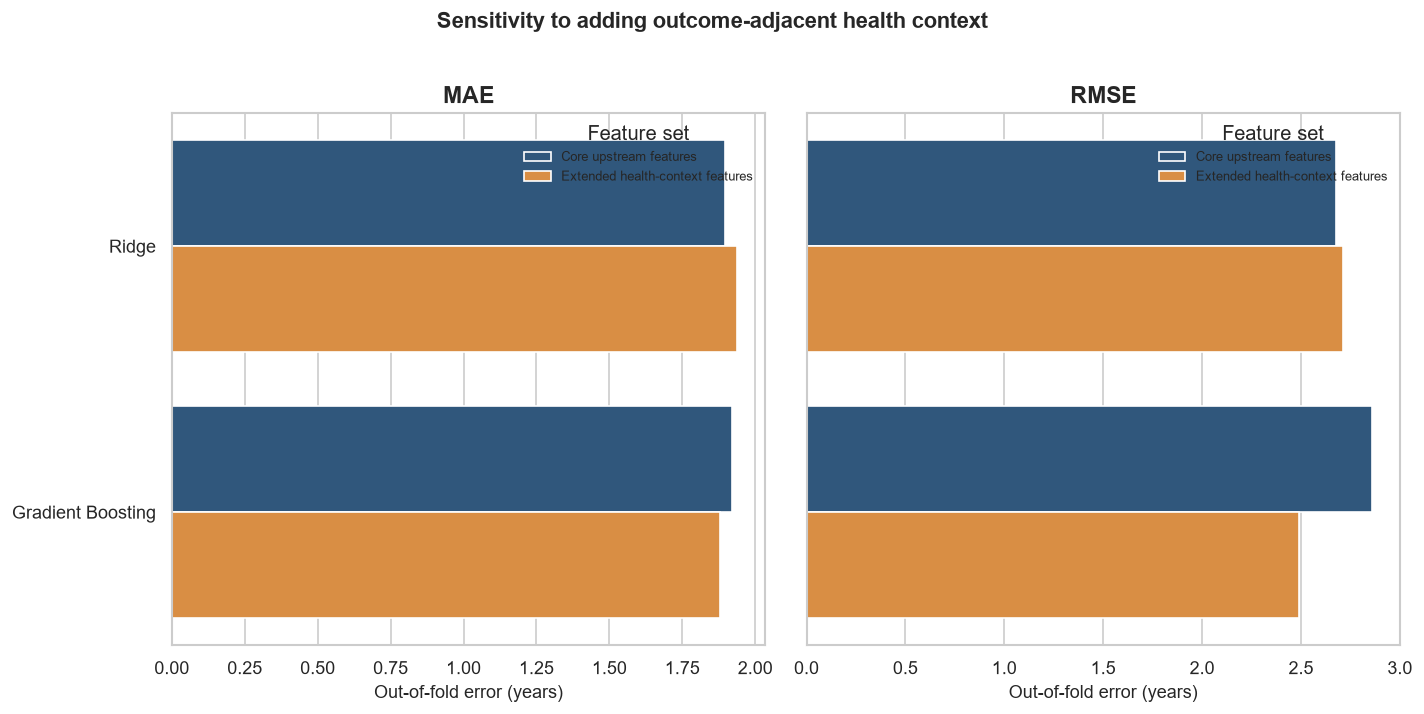

In [67]:
# Reshaping the feature-set sensitivity results for plotting.
sensitivity_long = sensitivity_feature_sets.melt(id_vars=["feature_set", "model"], value_vars=["mae_years", "rmse_years"], var_name="metric", value_name="error_years")
sensitivity_long["metric"] = sensitivity_long["metric"].map({"mae_years": "MAE", "rmse_years": "RMSE"})
# Comparing MAE and RMSE for the core and extended feature sets.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), sharey=True)
for axis, metric_name in zip(axes, ["MAE", "RMSE"]):
    metric_data = sensitivity_long.loc[sensitivity_long["metric"].eq(metric_name)]
    sns.barplot(data=metric_data, x="error_years", y="model", hue="feature_set", palette=[BLUE, ORANGE], ax=axis)
    axis.set(title=metric_name, xlabel="Out-of-fold error (years)", ylabel="")
    axis.legend(title="Feature set", fontsize=8)
# Adding the overall title, then saving and displaying the comparison.
fig.suptitle("Sensitivity to adding outcome-adjacent health context", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(figures_dir / "41_sensitivity_feature_sets.png", bbox_inches="tight")
plt.show()

### Checking if the official HLE uncertainty aligns with model error


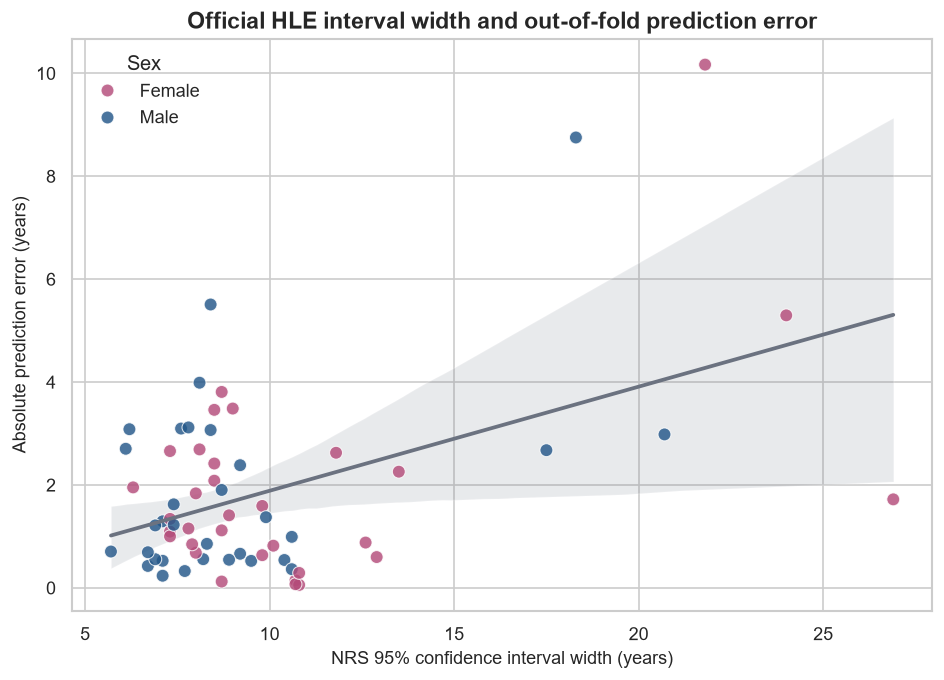

In [68]:
# Joining the official HLE confidence-interval width to the best model's prediction errors.
uncertainty_error = best_regression_predictions.merge(
    at_birth.reset_index(drop=True)[["council_area_code", "sex", "hle_ci_width_years"]],
    on=["council_area_code", "sex"],
    how="left",
)
# Checking whether less precise official HLE estimates are associated with larger prediction errors.
fig, ax = plt.subplots(figsize=(8, 5.8))
sns.regplot(data=uncertainty_error, x="hle_ci_width_years", y="absolute_error", scatter=False, color=GREY, ax=ax)
sns.scatterplot(data=uncertainty_error, x="hle_ci_width_years", y="absolute_error", hue="sex", palette=SEX_COLOURS, s=60, alpha=0.82, ax=ax)
# Labelling, saving and displaying the uncertainty comparison.
ax.set(title="Official HLE interval width and out-of-fold prediction error", xlabel="NRS 95% confidence interval width (years)", ylabel="Absolute prediction error (years)")
ax.legend(title="Sex")
fig.tight_layout()
fig.savefig(figures_dir / "42_hle_uncertainty_vs_prediction_error.png", bbox_inches="tight")
plt.show()

### Inverse-variance weighted regression

The regression gives more weight to HLE estimates with narrower confidence intervals. This tests whether differences in HLE precision affect the results.

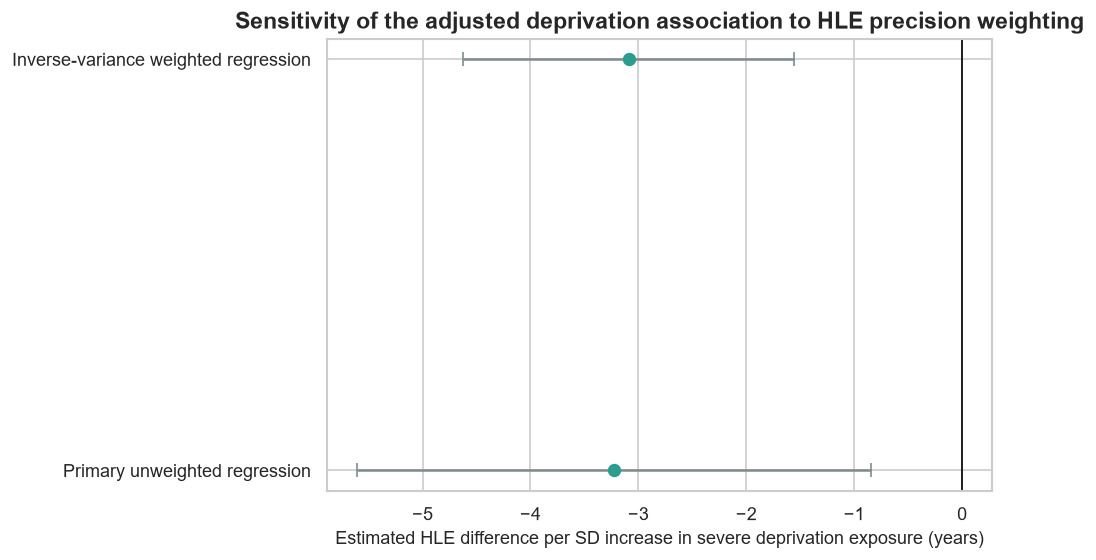

In [69]:
# Converting each official HLE confidence interval into a standard error and precision weight.
hle_standard_error = (
    at_birth["healthy_life_expectancy_upper_95_ci"]
    - at_birth["healthy_life_expectancy_lower_95_ci"]
) / (2 * 1.96)
inverse_variance_weights = 1 / np.maximum(hle_standard_error ** 2, 1e-12)
inverse_variance_weights = inverse_variance_weights / inverse_variance_weights.mean()

# Refitting the primary regression so more precise HLE estimates receive more weight.
weighted_outcome = at_birth["healthy_life_expectancy_years"].to_numpy()
weighted_bread = np.linalg.pinv(
    primary_design_matrix.T @ (inverse_variance_weights.to_numpy()[:, None] * primary_design_matrix)
)
weighted_coefficients = weighted_bread @ primary_design_matrix.T @ (
    inverse_variance_weights.to_numpy() * weighted_outcome
)
weighted_fitted = primary_design_matrix @ weighted_coefficients
weighted_residuals = weighted_outcome - weighted_fitted

# Calculating council-clustered uncertainty for the weighted regression.
weighted_meat = np.zeros((primary_design_matrix.shape[1], primary_design_matrix.shape[1]))
weighted_cluster_codes = at_birth["council_area_code"].to_numpy()
weighted_unique_clusters = np.unique(weighted_cluster_codes)
for cluster_code in weighted_unique_clusters:
    cluster_mask = weighted_cluster_codes == cluster_code
    cluster_score = primary_design_matrix[cluster_mask].T @ (
        inverse_variance_weights.to_numpy()[cluster_mask] * weighted_residuals[cluster_mask]
    )
    weighted_meat += np.outer(cluster_score, cluster_score)

# Applying the small-sample correction and obtaining clustered confidence intervals.
weighted_rows = len(at_birth)
weighted_parameters = primary_design_matrix.shape[1]
weighted_clusters = len(weighted_unique_clusters)
weighted_cr1 = (weighted_clusters / (weighted_clusters - 1)) * (
    (weighted_rows - 1) / (weighted_rows - weighted_parameters)
)
weighted_covariance = weighted_cr1 * weighted_bread @ weighted_meat @ weighted_bread
weighted_standard_errors = np.sqrt(np.diag(weighted_covariance))
weighted_critical_t = stats.t.ppf(0.975, df=weighted_clusters - 1)

# Collecting and saving the weighted regression coefficients.
weighted_regression = pd.DataFrame({
    "feature": primary_design_columns,
    "feature_label": [
        "Intercept" if feature == "Intercept" else all_feature_labels[feature]
        for feature in primary_design_columns
    ],
    "weighted_estimate_years": weighted_coefficients,
    "clustered_standard_error": weighted_standard_errors,
    "ci_lower": weighted_coefficients - weighted_critical_t * weighted_standard_errors,
    "ci_upper": weighted_coefficients + weighted_critical_t * weighted_standard_errors,
})
weighted_regression.to_csv(tables_dir / "43_weighted_regression_sensitivity.csv", index=False)

# Preparing a direct comparison of the weighted and unweighted deprivation estimates.
weighted_deprivation = weighted_regression.loc[
    weighted_regression["feature"].eq("simd_most_deprived_quintile_datazones_share_pct")
].iloc[0]
unweighted_deprivation = primary_coefficient_table.loc[
    primary_coefficient_table["feature"].eq("simd_most_deprived_quintile_datazones_share_pct")
].iloc[0]
weighted_plot = pd.DataFrame({
    "model": ["Primary unweighted regression", "Inverse-variance weighted regression"],
    "estimate": [unweighted_deprivation["estimate_years"], weighted_deprivation["weighted_estimate_years"]],
    "ci_lower": [unweighted_deprivation["ci_lower"], weighted_deprivation["ci_lower"]],
    "ci_upper": [unweighted_deprivation["ci_upper"], weighted_deprivation["ci_upper"]],
})

# Plotting both estimates and their clustered confidence intervals.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
weighted_positions = np.arange(len(weighted_plot))
ax.errorbar(
    weighted_plot["estimate"],
    weighted_positions,
    xerr=[
        weighted_plot["estimate"] - weighted_plot["ci_lower"],
        weighted_plot["ci_upper"] - weighted_plot["estimate"],
    ],
    fmt="o",
    color=TEAL,
    ecolor="#7F8C8D",
    capsize=4,
    markersize=7,
)
# Adding the zero reference line, then saving and displaying the sensitivity plot.
ax.axvline(0, color="black", lw=1)
ax.set_yticks(weighted_positions)
ax.set_yticklabels(weighted_plot["model"])
ax.set(
    title="Sensitivity of the adjusted deprivation association to HLE precision weighting",
    xlabel="Estimated HLE difference per SD increase in severe deprivation exposure (years)",
    ylabel="",
)
fig.tight_layout()
fig.savefig(figures_dir / "43_weighted_regression_sensitivity.png", bbox_inches="tight")
plt.show()

### Leave-one-council-out coefficient stability

The regression is refitted 32 times, leaving out one council each time. This tests whether the results depend heavily on any single council.


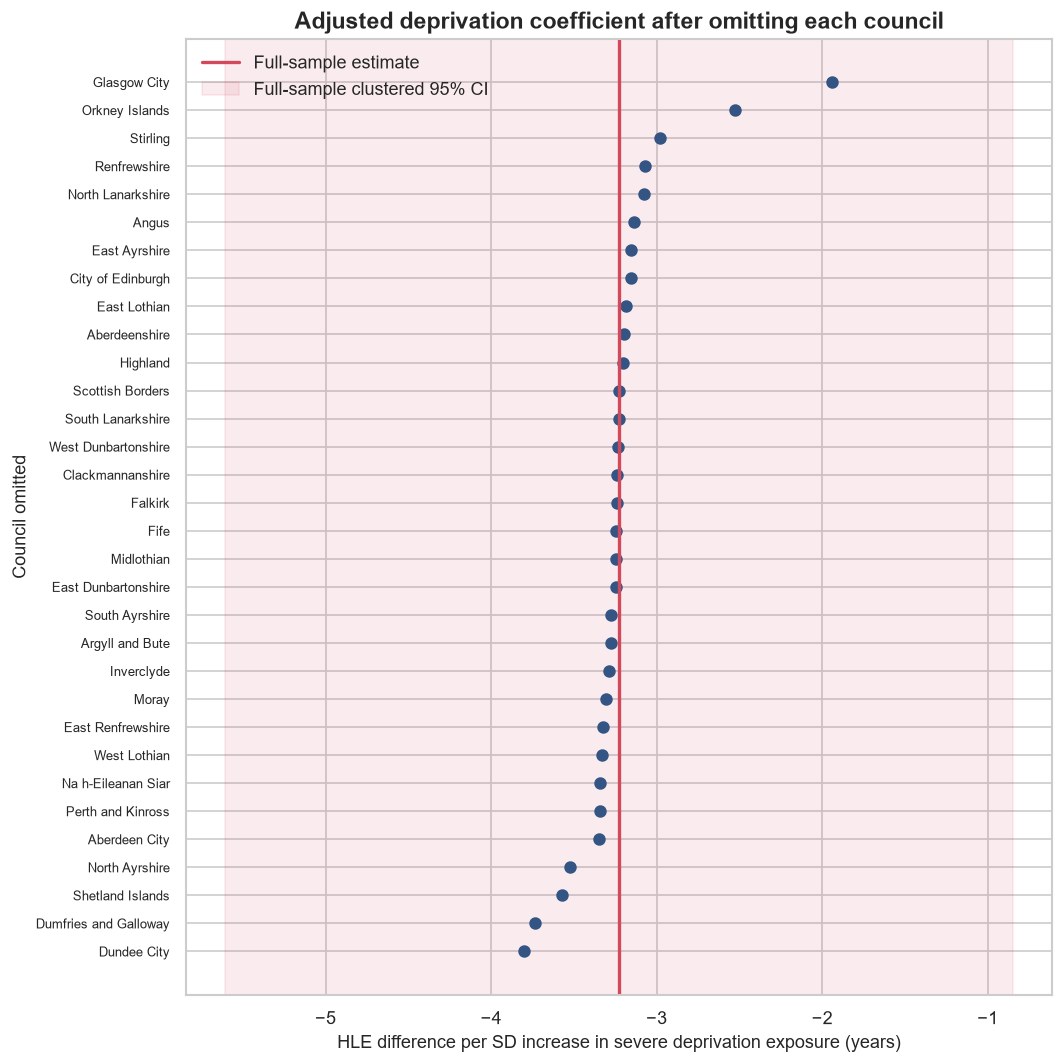

In [70]:
# Setting up the leave-one-council-out check for the adjusted deprivation coefficient.
leave_one_out_rows = []
deprivation_position = primary_design_columns.index(
    "simd_most_deprived_quintile_datazones_share_pct"
)
full_deprivation_estimate = primary_coefficients[deprivation_position]

# Refitting the primary regression after removing each council in turn.
for council_code in at_birth["council_area_code"].unique():
    keep_rows = at_birth["council_area_code"].ne(council_code).to_numpy()
    reduced_design = primary_design_matrix[keep_rows]
    reduced_outcome = at_birth.loc[keep_rows, "healthy_life_expectancy_years"].to_numpy()
    reduced_coefficients = (
        np.linalg.pinv(reduced_design.T @ reduced_design)
        @ reduced_design.T
        @ reduced_outcome
    )
    omitted_name = at_birth.loc[
        at_birth["council_area_code"].eq(council_code),
        "council_area",
    ].iloc[0]
    leave_one_out_rows.append({
        "omitted_council_code": council_code,
        "omitted_council": omitted_name,
        "deprivation_estimate_years_per_sd": reduced_coefficients[deprivation_position],
        "full_sample_estimate_years_per_sd": full_deprivation_estimate,
        "difference_from_full_estimate": reduced_coefficients[deprivation_position] - full_deprivation_estimate,
    })

# Combining and saving the deprivation estimates from all 32 refitted models.
leave_one_out_results = pd.DataFrame(leave_one_out_rows).sort_values(
    "deprivation_estimate_years_per_sd"
).reset_index(drop=True)
leave_one_out_results.to_csv(tables_dir / "44_leave_one_council_out_sensitivity.csv", index=False)

# Plotting how the deprivation estimate changes when each council is omitted.
fig, ax = plt.subplots(figsize=(9, 9))
leave_positions = np.arange(len(leave_one_out_results))
ax.scatter(
    leave_one_out_results["deprivation_estimate_years_per_sd"],
    leave_positions,
    color=BLUE,
    s=42,
)
# Adding the full-sample estimate and confidence interval, then saving and displaying the plot.
ax.axvline(full_deprivation_estimate, color=RED, lw=2, label="Full-sample estimate")
ax.axvspan(
    unweighted_deprivation["ci_lower"],
    unweighted_deprivation["ci_upper"],
    color=RED,
    alpha=0.10,
    label="Full-sample clustered 95% CI",
)
ax.set_yticks(leave_positions)
ax.set_yticklabels(leave_one_out_results["omitted_council"], fontsize=8)
ax.set(
    title="Adjusted deprivation coefficient after omitting each council",
    xlabel="HLE difference per SD increase in severe deprivation exposure (years)",
    ylabel="Council omitted",
)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(figures_dir / "44_leave_one_council_out_sensitivity.png", bbox_inches="tight")
plt.show()

### Public results summary


In [71]:
# Collecting the selected regression, classification and deprivation results used in the final summary.
best_regression_row = regression_model_comparison.loc[
    regression_model_comparison["model"].eq(best_regression_model_name)
].iloc[0]
best_classifier_row = classification_model_comparison.loc[
    classification_model_comparison["model"].eq(best_classifier_name)
].iloc[0]
deprivation_coefficient = primary_coefficient_table.loc[
    primary_coefficient_table["feature"].eq("simd_most_deprived_quintile_datazones_share_pct")
].iloc[0]

# Building a concise table of the main numerical findings from the completed analysis.
results_summary = pd.DataFrame({
    "result": [
        "Mean female-minus-male HLE difference",
        "Least-versus-most deprivation quartile HLE gap",
        "Adjusted deprivation association in primary regression",
        "Weighted deprivation sensitivity estimate",
        "Leave-one-council-out deprivation estimate range",
        "Low HLE upper boundary",
        "Middle HLE upper boundary",
        "Best non-dummy regression model",
        "Best regression MAE",
        "Best regression RMSE",
        "Best non-dummy three-class classifier",
        "Best classifier balanced accuracy",
        "Best classifier macro-F1",
        "Best classifier weighted kappa",
        "Agreement between regression and classification bands",
        "Maximum exact Shapley additivity error",
    ],
    "value": [
        f"{paired_difference.mean():.2f} years (bootstrap 95% CI {np.percentile(bootstrap_paired_means, 2.5):.2f} to {np.percentile(bootstrap_paired_means, 97.5):.2f})",
        f"{observed_gap:.2f} years (bootstrap 95% CI {np.percentile(bootstrap_gaps, 2.5):.2f} to {np.percentile(bootstrap_gaps, 97.5):.2f})",
        f"{deprivation_coefficient['estimate_years']:.2f} years per SD (clustered 95% CI {deprivation_coefficient['ci_lower']:.2f} to {deprivation_coefficient['ci_upper']:.2f})",
        f"{weighted_deprivation['weighted_estimate_years']:.2f} years per SD (clustered 95% CI {weighted_deprivation['ci_lower']:.2f} to {weighted_deprivation['ci_upper']:.2f})",
        f"{leave_one_out_results['deprivation_estimate_years_per_sd'].min():.2f} to {leave_one_out_results['deprivation_estimate_years_per_sd'].max():.2f} years per SD",
        f"{hle_low_threshold:.1f} years",
        f"{hle_high_threshold:.1f} years",
        best_regression_model_name,
        f"{best_regression_row['mae_years']:.2f} years",
        f"{best_regression_row['rmse_years']:.2f} years",
        best_classifier_name,
        f"{best_classifier_row['balanced_accuracy']:.3f}",
        f"{best_classifier_row['macro_f1']:.3f}",
        f"{best_classifier_row['weighted_kappa']:.3f}",
        f"{method_agreement_rate:.3f}",
        f"{shap_max_additivity_error:.3e}",
    ],
})
# Saving and displaying the publication results summary.
results_summary.to_csv(tables_dir / "42_public_results_summary.csv", index=False)
print(results_summary.to_string(index=False))

                                                result                                                value
                 Mean female-minus-male HLE difference           0.42 years (bootstrap 95% CI 0.21 to 0.64)
        Least-versus-most deprivation quartile HLE gap         11.59 years (bootstrap 95% CI 9.19 to 14.41)
Adjusted deprivation association in primary regression -3.23 years per SD (clustered 95% CI -5.61 to -0.85)
             Weighted deprivation sensitivity estimate -3.09 years per SD (clustered 95% CI -4.62 to -1.56)
      Leave-one-council-out deprivation estimate range                          -3.80 to -1.94 years per SD
                                Low HLE upper boundary                                           58.1 years
                             Middle HLE upper boundary                                           62.0 years
                       Best non-dummy regression model                                        Random Forest
                            

## Execution record

All 71 Python code cells completed successfully using random seed 25928399. 